## AI 모델 개발 15회차 1차 팀프로젝트 - NASA Turbofan Jet Engine Data Set 터보엔진 유지보전 문제_FD002

[데이터셋 개요]
이 데이터셋은 NASA의 C-MAPSS(Commercial Modular Aero-Propulsion System Simulation)
시뮬레이터를 사용하여 생성된 터보팬 엔진의 열화(Degradation) 데이터입니다.

데이터는 여러 개의 다변량 시계열(Multivariate Time Series)로 구성되어 있습니다.
데이터셋은 학습(Training) 세트와 테스트(Test) 세트로 나뉩니다.
각 시계열 데이터는 서로 다른 엔진(Unit)에서 얻은 데이터이며, 동일한 유형의 엔진들로 간주할 수 있습니다.

[실험 시나리오]
1. 초기 상태: 각 엔진은 정상 상태에서 작동을 시작합니다.
   - 단, 사용자에게는 알려지지 않은 수준의 초기 마모(Initial Wear)와 제조 공차(Variation)가 존재합니다.
     (이는 결함이 아닌 정상적인 범주입니다.)
2. 고장 진행: 어느 시점부터 결함(Fault)이 발생하여 시간이 지날수록 상태가 악화됩니다.
3. 데이터 범위:
   - 학습 세트 (Train): 결함 발생부터 시스템 고장(Failure) 시점까지의 모든 데이터가 포함됩니다.
   - 테스트 세트 (Test): 고장 발생 전 임의의 시점에서 데이터 기록이 중단됩니다.

[목표 (Objective)]
테스트 세트에 포함된 각 엔진의 **잔여 유효 수명(RUL: Remaining Useful Life)**을 예측하는 것입니다.
즉, 테스트 데이터가 끊긴 시점으로부터 엔진이 고장 날 때까지 몇 사이클(Cycle)이 더 남았는지 맞히는 것이 목표입니다.

> FD002 (Train: train_FD002.txt / Test: test_FD002.txt / RUL: RUL_FD002.txt)
   - 학습 엔진 수: 260개
   - 테스트 엔진 수: 259개
   - 운전 조건 (Conditions): 6가지 (다양한 고도, 속도, 부하 조건)
   - 고장 모드 (Fault Modes): 1가지 (HPC 열화)


### > 버전 

 📖 개념 설명
 ─────────────────────────────────────────────────────────      
 기존: 모든 운전조건 데이터를 하나의 모델에 넣고 학습      
   → 모델이 "이 데이터가 어떤 조건인지" 구분하는 것부터 학습해야 함     
   → cluster one-hot이 이 역할을 하지만, 조건마다 열화 패턴이 다름     
   → 하나의 모델이 6~7가지 패턴을 동시에 학습하려니 정밀도 ↓     
 제안: 조건(condition_id)별로 데이터를 나누고, 각각 전용 모델 학습    
   → 각 모델은 해당 조건의 열화 패턴만 집중 학습    
   → cluster one-hot 불필요 (이미 조건별로 분리됨)    
   → Feature도 해당 조건에서 유의미한 것만 자동 선택됨    
      
 예측 시: Test 엔진의 마지막 행이 어떤 condition인지 확인 →    
          해당 condition 전용 모델로 예측    
       
 문헌 사례:     
   - FD-002 상위 참가자들은 이 방식으로 RMSE 11~14 달성     
   - 특히 Condition 0 (Alt≈0, 지상)은 패턴이 단순 → 정확도 매우 높음    
   - Condition 6 (Alt≈40, 고고도)은 데이터가 많아 → 모델이 잘 학습됨   
    
 ─────────────────────────────────────────────────────────    
 ⚠️ 주의사항    
 ─────────────────────────────────────────────────────────
 1. 소수 데이터 조건 (예: Cluster 2 = 1,606행, Cluster 5 = 1,508행)은    
    별도 모델 학습이 어려울 수 있음 → 글로벌 모델로 fallback    
 2. Test 엔진의 "마지막 행"이 어떤 조건인지가 핵심    
    → 마지막 행만으로 판단하므로, 해당 시점의 조건이 중요    
 3. 이 방식은 "마지막 행 예측"에 특화됨    
    → 시계열 궤적 시각화 시에는 글로벌 모델이 여전히 필요    
 =========================================================

## 1. 라이브러리 및 데이터 로드

In [ ]:
# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
warnings.filterwarnings('ignore')

## 2. 데이터 불러오기

In [ ]:
# kaggle에서 데이터 가져오기

%pip install kaggle==1.8.0

from dotenv import load_dotenv
load_dotenv()

!kaggle datasets download behrad3d/nasa-cmaps

In [ ]:
# 데이터 가져오기
import os
HOME = os.getcwd()
zipPath = os.path.join(HOME, "nasa-cmaps.zip")
targetPath = os.path.join(HOME, 'data')

from zipfile import ZipFile

with ZipFile(zipPath, 'r') as zip_ref:
    zip_ref.extractall(targetPath)


In [ ]:
parent_path = "C:/Users/user/github/EST_15th_NASA/한지형/data/CMaps"

#FD_ID = "FD001" # Conditions: ONE (Sea Level), Fault Modes: ONE (HPC Degradation)
FD_ID = "FD002" # Conditions: SIX, Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD003" # Conditions: ONE (Sea Level), Fault Modes: TWO (HPC Degradation, Fan Degradation)
#FD_ID = "FD004" # Conditions: SIX , Fault Modes: TWO (HPC Degradation, Fan Degradation)

train_path = os.path.join(parent_path, f"train_{FD_ID}.txt")
test_path  = os.path.join(parent_path, f"test_{FD_ID}.txt")
rul_path   = os.path.join(parent_path, f"RUL_{FD_ID}.txt")

print(f"Train path: {train_path}")

col_names = [
    "unit_number", "time_in_cycles",
    "op_setting_1", "op_setting_2", "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=col_names)
rul_df = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])


In [ ]:
train_df.head()

## 3. Feature Engineering

In [ ]:
rename_dict = {
    "op_setting_1": "Alt[kft]", # Altitude
    "op_setting_2": "Mn[-]", # Mach number
    "op_setting_3": "TLA[deg]", # Thrust lever angle (detent?)
    "sensor_1": "T2[R]",  # Total temperature at fan inlet 
    "sensor_2": "T24[R]", # Total temperature at LPC outlet
    "sensor_3": "T30[R]", # Total temperature at HPC outlet
    "sensor_4": "T50[R]", # Total temperature at LPT outlet
    "sensor_5": "P2[psi]", # Pressure at fan inlet
    "sensor_6": "P15[psi]", # Total pressure in bypass-duct
    "sensor_7": "P30[psi]", # Total pressure at HPC outlet
    "sensor_8": "Nf[rpm]", # Physical fan speed
    "sensor_9": "Nc[rpm]", # Physical core speed
    "sensor_10": "epr[-]", # Engine pressure ratio (P50/P2)
    "sensor_11": "phi[pph/psi]", # Ratio of fuel flow to Ps30, (not pps/psi, but pph/psi)
    "sensor_12": "Ps30[psi]", # Static pressure at HPC outlet
    "sensor_13": "NRf[rpm]", # Corrected fan speed
    "sensor_14": "NRc[rpm]", # Corrected core speed
    "sensor_15": "BPR[-]", # Bypass Ratio
    "sensor_16": "farB[-]", # Burner fuel-air ratio
    "sensor_17": "htBleed[]",# Bleed Enthalpy
    "sensor_18": "Nf_dmd[rpm]", # Demanded fan speed
    "sensor_19": "PCNfR_dmd[Pct]", # Demanded corrected fan speed
    "sensor_20": "W31[lbm/s]", # HPT coolant bleed
    "sensor_21": "W32[lbm/s]", # LPT coolant bleed
}


train_df = train_df.rename(columns=rename_dict)
test_df  = test_df.rename(columns=rename_dict)

def clean_round(series, ndigits=1, eps=1e-6):
    """Round values and force -0.0 to 0.0"""
    rounded = series.round(ndigits)
    rounded[rounded.abs() < eps] = 0
    return rounded

train_df['condition'] = (
    clean_round(train_df["Alt[kft]"], 0).astype(str) + '_' +
    clean_round(train_df["Mn[-]"], 1).astype(str) + '_' +
    clean_round(train_df["TLA[deg]"], 0).astype(str)
)

train_df.head()

In [ ]:
train_df["P50[psi]"] = train_df["epr[-]"]*train_df["P2[psi]"]

train_df["Fan.PR[-]"] = train_df["P15[psi]"]/train_df["P2[psi]"]
train_df["LPC.TR[-]"] = train_df["T24[R]"]/train_df["T2[R]"] # Fan core + LPC
train_df["HPC.TR[-]"] = train_df["T30[R]"]/train_df["T24[R]"]

train_df["OPR[-]"] = train_df["P30[psi]"]/train_df["P2[psi]"]

train_df["Wf[pph]"] = train_df["phi[pph/psi]"]*train_df["Ps30[psi]"]
train_df["Wa36[lbm/s]"] = train_df["Wf[pph]"]/3600.0 / train_df["farB[-]"]
train_df["W24[lbm/s]"] = train_df["Wa36[lbm/s]"] + train_df["W31[lbm/s]"] + train_df["W32[lbm/s]"] # core. htBleed ? 
train_df["W15[lbm/s]"] = train_df["W24[lbm/s]"]*train_df["BPR[-]"] # bypass
train_df["W2[lbm/s]"] = train_df["W15[lbm/s]"] + train_df["W24[lbm/s]"] # overall

train_df["WfP3C[pph/psi]"] = train_df["phi[pph/psi]"]/np.sqrt(train_df["T2[R]"]/518.67)

train_df.head()


In [ ]:
# ---------------------------------------------------------
#  물리적 파생 변수 생성 함수
# ---------------------------------------------------------
def generate_derived_features(df):
    df_eng = df.copy()
    
    # 0으로 나누기 방지 (T2, farB 등)
    # T2가 0이면 518.67(Rankine 기준온도)로 대체
    t2_safe = df_eng['T2[R]'].replace(0, 518.67)
    farb_safe = df_eng['farB[-]'].replace(0, 0.0001) # 0이면 아주 작은 값

    # 1. 압력/온도 비율 (Pressure/Temp Ratios)
    df_eng["P50[psi]"] = df_eng["epr[-]"] * df_eng["P2[psi]"]
    df_eng["Fan.PR[-]"] = df_eng["P15[psi]"] / df_eng["P2[psi]"]
    df_eng["LPC.TR[-]"] = df_eng["T24[R]"] / t2_safe
    df_eng["HPC.TR[-]"] = df_eng["T30[R]"] / df_eng["T24[R]"]
    df_eng["OPR[-]"] = df_eng["P30[psi]"] / df_eng["P2[psi]"]

    # 2. 유량 계산 (Mass Flow Rates)
    # Wf = phi * Ps30
    df_eng["Wf[pph]"] = df_eng["phi[pph/psi]"] * df_eng["Ps30[psi]"]
    
    # Wa36 (Core airflow)
    df_eng["Wa36[lbm/s]"] = df_eng["Wf[pph]"] / 3600.0 / farb_safe
    
    # W24 (LPC outlet flow) = Core + Coolant Bleeds
    df_eng["W24[lbm/s]"] = df_eng["Wa36[lbm/s]"] + df_eng["W31[lbm/s]"] + df_eng["W32[lbm/s]"]
    
    # W15 (Bypass flow) = Core * BPR
    df_eng["W15[lbm/s]"] = df_eng["W24[lbm/s]"] * df_eng["BPR[-]"]
    
    # W2 (Total Fan Inlet flow)
    df_eng["W2[lbm/s]"] = df_eng["W15[lbm/s]"] + df_eng["W24[lbm/s]"]

    # 3. 보정된 연료 흐름 (Corrected Fuel Flow)
    df_eng["WfP3C[pph/psi]"] = df_eng["phi[pph/psi]"] / np.sqrt(t2_safe / 518.67)
    
    return df_eng

# ---------------------------------------------------------
# 🔥 실행: Train과 Test 모두 적용!
# ---------------------------------------------------------
print("🔧 파생 변수 생성 중...")
train_df = generate_derived_features(train_df)
test_df = generate_derived_features(test_df) # ★ Test에도 꼭 적용해야 함

print(f"✅ 생성 완료! 'P50[psi]' 존재 여부: {'P50[psi]' in train_df.columns}")

### 컬럼 설명 (Data Dictionary)

| 컬럼명 | 설명 | 타입 |
|---|---|---|
| **unit_number** | 엔진 고유 식별자 (Unit Number) | int64 |
| **time_in_cycles** | 운전 사이클 (Time in Cycles) | int64 |
| **Alt[kft]** | 고도 (Altitude) | float64 |
| **Mn[-]** | 마하 수 (Mach Number) | float64 |
| **TLA[deg]** | 스로틀 레버 각도 (Thrust Lever Angle) | float64 |
| **T2[R]** | 팬 입구 전온도 (Total temperature at fan inlet) | float64 |
| **T24[R]** | LPC 출구 전온도 (Total temperature at LPC outlet) | float64 |
| **T30[R]** | HPC 출구 전온도 (Total temperature at HPC outlet) | float64 |
| **T50[R]** | LPT 출구 전온도 (Total temperature at LPT outlet) | float64 |
| **P2[psi]** | 팬 입구 압력 (Pressure at fan inlet) | float64 |
| **P15[psi]** | 바이패스 덕트 전압력 (Total pressure in bypass-duct) | float64 |
| **P30[psi]** | HPC 출구 전압력 (Total pressure at HPC outlet) | float64 |
| **Nf[rpm]** | 물리적 팬 속도 (Physical fan speed) | float64 |
| **Nc[rpm]** | 물리적 코어 속도 (Physical core speed) | float64 |
| **epr[-]** | 엔진 압력비 (Engine pressure ratio) | float64 |
| **phi[pph/psi]** | 연료 유량 대 Ps30 비율 (Ratio of fuel flow to Ps30) | float64 |
| **Ps30[psi]** | HPC 출구 정압 (Static pressure at HPC outlet) | float64 |
| **NRf[rpm]** | 보정된 팬 속도 (Corrected fan speed) | float64 |
| **NRc[rpm]** | 보정된 코어 속도 (Corrected core speed) | float64 |
| **BPR[-]** | 바이패스 비 (Bypass Ratio) | float64 |
| **farB[-]** | 연소기 연료-공기 비 (Burner fuel-air ratio) | float64 |
| **htBleed[]** | 블리드 엔탈피 (Bleed Enthalpy) | int64 |
| **Nf_dmd[rpm]** | 요구 팬 속도 (Demanded fan speed) | int64 |
| **PCNfR_dmd[Pct]** | 요구 보정 팬 속도 (Demanded corrected fan speed) | float64 |
| **W31[lbm/s]** | HPT 냉각 블리드 (HPT coolant bleed) | float64 |
| **W32[lbm/s]** | LPT 냉각 블리드 (LPT coolant bleed) | float64 |
| **condition** | 운전 조건 문자열 (Operational Condition String) | object |
| **P50[psi]** | LPT 출구 전압력 (Total pressure at LPT outlet) | float64 |
| **Fan.PR[-]** | 팬 압력비 (Fan pressure ratio) | float64 |
| **LPC.TR[-]** | LPC 전온도비 (LPC total temperature ratio) | float64 |
| **HPC.TR[-]** | HPC 전온도비 (HPC total temperature ratio) | float64 |
| **OPR[-]** | 전체 압력비 (Overall pressure ratio) | float64 |
| **Wf[pph]** | 연료 유량 (Fuel flow) | float64 |
| **Wa36[lbm/s]** | 코어 공기 유량 (Core airflow) | float64 |
| **W24[lbm/s]** | LPC 공기 유량 (LPC airflow) | float64 |
| **W15[lbm/s]** | 바이패스 공기 유량 (Bypass airflow) | float64 |
| **W2[lbm/s]** | 팬 유입 공기 유량 (Fan inlet airflow) | float64 |
| **WfP3C[pph/psi]** | P3 압력 대비 연료 유량 (Fuel flow to P3 pressure ratio) | float64 |
| **RUL** | 엔진의 남은 수명 (Remaining Useful Life) | int64 |

In [ ]:
train_df.info()

In [ ]:
pd.set_option('display.max_rows', None)
summary_df = pd.DataFrame(train_df.dtypes, columns=['Data Type'])
summary_df = summary_df.reset_index()
summary_df = summary_df.rename(columns={'index': 'Column Name'})
summary_df['Non-Null Count'] = train_df.count().values
summary_df['Null Count'] = train_df.isnull().sum().values
summary_df['Null Ratio (%)'] = (train_df.isnull().sum().values / len(train_df)) * 100
summary_df


### 정규화 / 이상치 처리
* FD002는 FD001과 다르게 운전 조건이 단일 조건이 아니기 때문에 고도와 속도가 변한다.
1. 따라서 데이터를 여러 그룹(클러스터)로 나눠 (고도(Altitude), 마하수(Mach Number), 스로틀(TRA) 조합에 따라 총 6가지 운전 모드로 클러스터링) 
2. 클러스터링 과정에서 생성되는 cluster 컬럼을 one-hot encoding으로 클러스터 분간용도로 변환.
3. 그룹별로 정규화를 하고 (Z-score) (고도나 속도 마다 온도 등 센서 수치가 다르기 때문에 이 차이를 없애기 위해 정규화) (trand 분리화) + Mode_ID를 포함한 조건부 정규화를 추가한다.
4. z-score가 ±3을 벗어나는 이상치를 clipping 한다.
5. 정규화된 데이터를 다시 합쳐 모델에 넣는다.

* 기존에 운전조건으로만 6구간을 나눠 정규화한 데이터를 사용한 결과 아래 그림과 같이 산점도에서 farB[-]의 이봉 분포(두 줄로 갈라지는 현상)에 의해 farB[-]에서 파생된 W15, W24, W2, Wa36 에도 cluster 1 데이터가 직선형으로 혼재
* 이 문제를 해결하기 위해 one-hot encoding + farB의 cluster1 데이터를 이봉 분포 기준에 따라 mode_ID (0,1)로 condition_id하는 기준을 추가한다.
* 노이즈 제거는 과정에서 컬럼이 매우 많이 파생되므로 EDA, feature selection 이후에 진행한다.

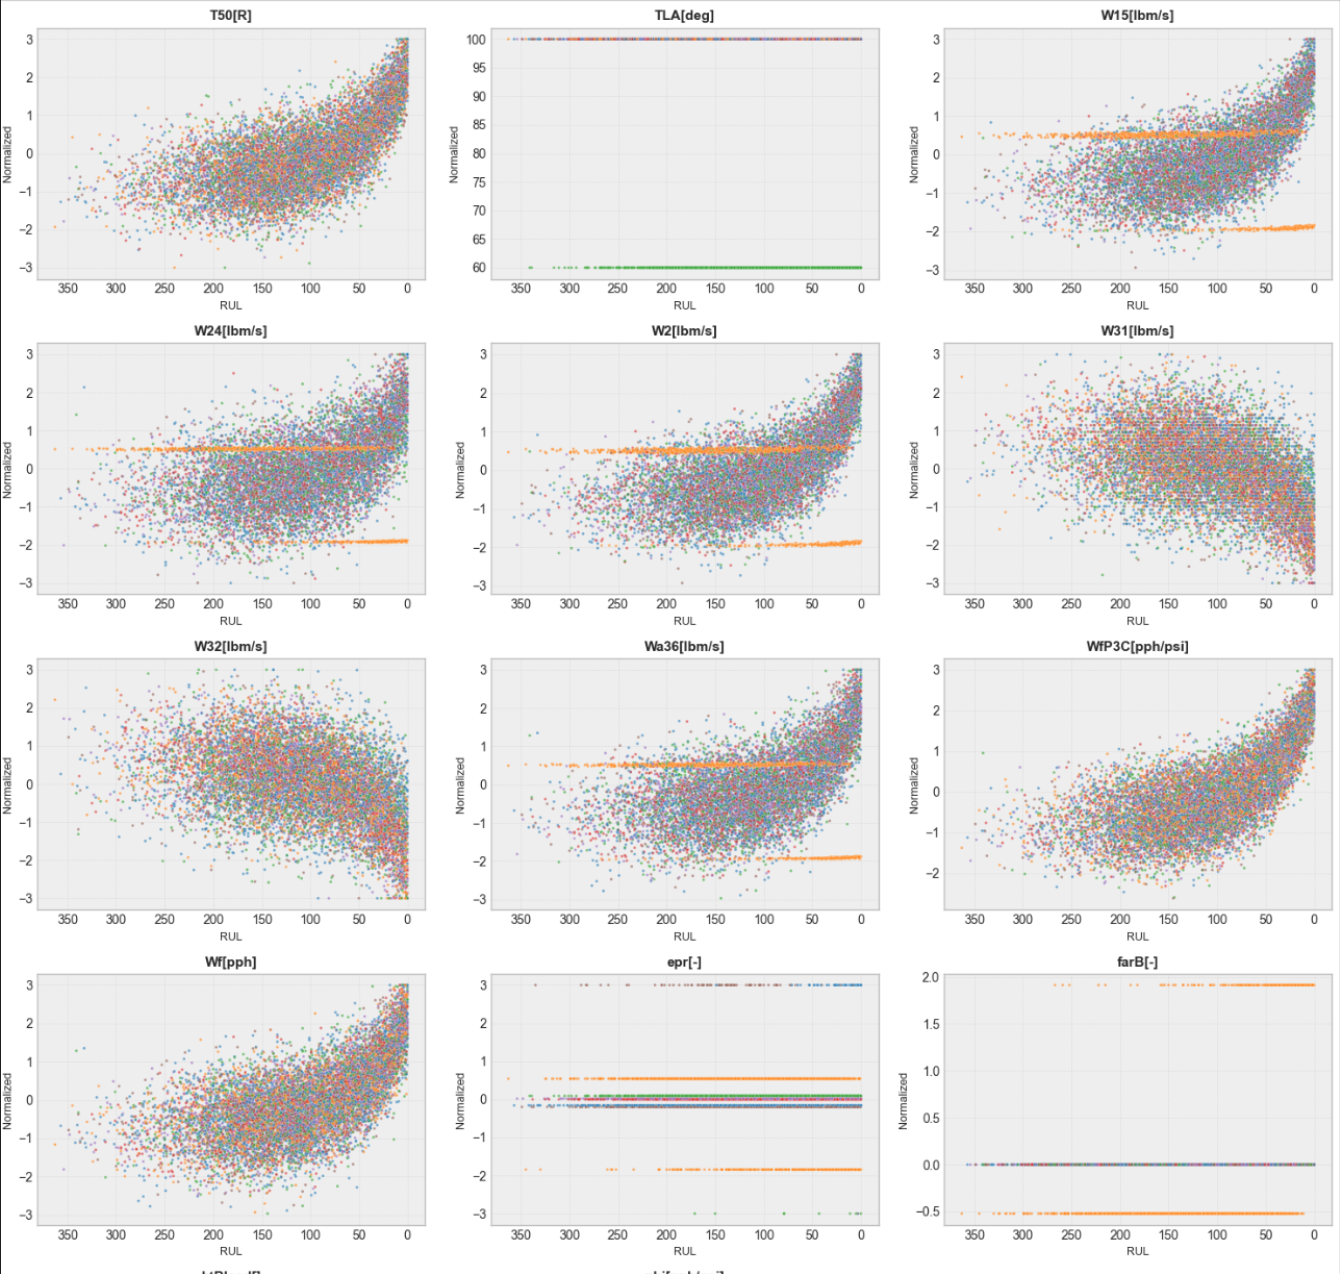

이번 버전에서는 hard clustering으로 진행

In [ ]:
# ---------------------------------------------------------
# [필수 정의] 정규화할 모든 센서 (원본 + 파생) 리스트
# ---------------------------------------------------------

# 1. 원본 센서 (Physical Name)
RAW_SENSORS = [
    'T2[R]', 'T24[R]', 'T30[R]', 'T50[R]', 'P2[psi]', 'P15[psi]', 'P30[psi]',
    'Nf[rpm]', 'Nc[rpm]', 'epr[-]', 'phi[pph/psi]', 'Ps30[psi]', 'NRf[rpm]',
    'NRc[rpm]', 'BPR[-]', 'farB[-]', 'htBleed[]', 'Nf_dmd[rpm]',
    'PCNfR_dmd[Pct]', 'W31[lbm/s]', 'W32[lbm/s]'
]

# 2. 파생 변수 (Derived Features) -
DERIVED_SENSORS = [
    "P50[psi]", 
    "Fan.PR[-]", 
    "LPC.TR[-]", 
    "HPC.TR[-]", 
    "OPR[-]", 
    "Wf[pph]", 
    "Wa36[lbm/s]", 
    "W24[lbm/s]", 
    "W15[lbm/s]", 
    "W2[lbm/s]", 
    "WfP3C[pph/psi]"
]

# 3. 합치기 (최종 정규화 대상)
# 주의: 이 리스트에 있는 컬럼들이 DataFrame에 실제로 존재해야 합니다.
# (파생변수 생성 코드를 먼저 실행했는지 꼭 확인하세요!)
SENSOR_FEATURES = RAW_SENSORS + DERIVED_SENSORS

# 안전장치: 실제 train_df에 존재하는 컬럼만 남기기
# (혹시 파생변수 생성을 아직 안 했다면 여기서 걸러집니다)
existing_cols = set(train_df.columns)
SENSOR_FEATURES = [col for col in SENSOR_FEATURES if col in existing_cols]

print(f"✅ SENSOR_FEATURES 정의 완료! (총 {len(SENSOR_FEATURES)}개)")
print(f"   - 원본: {len([c for c in SENSOR_FEATURES if c in RAW_SENSORS])}개")
print(f"   - 파생: {len([c for c in SENSOR_FEATURES if c in DERIVED_SENSORS])}개")

# 만약 파생변수가 0개로 나오면, 파생변수 만드는 코드를 먼저 실행해야 함을 알림
if len([c for c in SENSOR_FEATURES if c in DERIVED_SENSORS]) == 0:
    print("⚠️ 경고: 파생 변수가 감지되지 않았습니다. 'Step 2'의 파생변수 생성 코드를 먼저 실행해주세요!")

* 이번 버전에서는 이봉분포 분리 mode_id 조건부 정규화를 모든 클러스터에 적용 (클러스터 2에서도 이봉붙포 확인 때문에) 클러스터 2의 이봉분포는 매우 차이가 적어 한정으로 강제지정      
"Cluster 2는 무조건 2개로 쪼개라 (c_id == 2)"**라고 코드를 박아버렸습니다.     
다른 클러스터에도 문제가 있었다. 여기도 이봉분포 존재. 이봉분포는 고도 등 운전조건에 따라 다르게 작동하는 밸브등의 작동조건때문이다.

In [ ]:
# ---------------------------------------------------------
# [Step 3 최종 완결] C2, C3(farB) & C6(T24) 동시 분할
# ---------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# 센서 리스트 (변함 없음)
RAW_SENSORS = [
    'T2[R]', 'T24[R]', 'T30[R]', 'T50[R]', 'P2[psi]', 'P15[psi]', 'P30[psi]',
    'Nf[rpm]', 'Nc[rpm]', 'epr[-]', 'phi[pph/psi]', 'Ps30[psi]', 'NRf[rpm]',
    'NRc[rpm]', 'BPR[-]', 'farB[-]', 'htBleed[]', 'Nf_dmd[rpm]',
    'PCNfR_dmd[Pct]', 'W31[lbm/s]', 'W32[lbm/s]'
]
DERIVED_SENSORS = [
    "P50[psi]", "Fan.PR[-]", "LPC.TR[-]", "HPC.TR[-]", "OPR[-]", 
    "Wf[pph]", "Wa36[lbm/s]", "W24[lbm/s]", "W15[lbm/s]", "W2[lbm/s]", "WfP3C[pph/psi]"
]
SENSOR_FEATURES = RAW_SENSORS + DERIVED_SENSORS
SENSOR_FEATURES = [col for col in SENSOR_FEATURES if col in train_df.columns]

def step3_advanced_preprocessing(train, test, sensor_cols):
    print("🚀 [Step 3] Advanced Preprocessing (Targeted Split: C2, C3 & C6) 시작...")
    
    # 1. Hard Clustering
    def assign_hard_cluster(df):
        df_c = df.copy()
        # 컬럼명 대응
        if 'Alt[kft]' in df_c.columns:
            df_c['r_alt'] = df_c['Alt[kft]'].round(-1)
            df_c['r_mach'] = df_c['Mn[-]'].round(2)
            df_c['r_tra'] = df_c['TLA[deg]'].round(0)
        else:
            df_c['r_alt'] = df_c['op_setting_1'].round(-1)
            df_c['r_mach'] = df_c['op_setting_2'].round(2)
            df_c['r_tra'] = df_c['op_setting_3'].round(0)
            
        df_c['cond_str'] = (df_c['r_alt'].astype(str) + "_" + 
                            df_c['r_mach'].astype(str) + "_" + 
                            df_c['r_tra'].astype(str))
        return df_c

    train = assign_hard_cluster(train)
    test = assign_hard_cluster(test)
    
    conditions = sorted(train['cond_str'].unique())
    cond_map = {c: i for i, c in enumerate(conditions)}
    
    train['cluster'] = train['cond_str'].map(cond_map)
    test['cluster'] = test['cond_str'].map(cond_map)
    print(f"✅ Hard Clustering 완료")

    # =========================================================
    # 2. Multi-Mode ID 생성 (타겟별 맞춤 분할)
    # =========================================================
    train['Mode_ID'] = 0
    test['Mode_ID'] = 0
    
    unique_clusters = sorted(train['cluster'].unique())
    print(f"\n🕵️ 이봉분포 정밀 타격 시작")

    for c_id in unique_clusters:
        mask_tr = (train['cluster'] == c_id)
        mask_te = (test['cluster'] == c_id)
        
        # -----------------------------------------------------
        # [Case A] Cluster 2 & 3: farB 기준 분할 (★수정됨★)
        # -----------------------------------------------------
        # 기존에는 2번만 있었으나, 3번도 farB 이봉분포이므로 리스트에 추가함
        if c_id in [2, 3]:
            target_col = 'farB[-]'
            print(f"  [Cluster {c_id}] 'farB[-]' 기준으로 강제 분할 시도...", end=" ")
            if target_col in train.columns:
                vals = train.loc[mask_tr, target_col].values
                # 강제 KMeans (2개)
                km = KMeans(n_clusters=2, random_state=42, n_init=10)
                labels = km.fit_predict(vals.reshape(-1, 1))
                centers = km.cluster_centers_.reshape(-1)
                
                # 정렬 (0: Low, 1: High)
                if centers[1] < centers[0]: labels = 1 - labels
                train.loc[mask_tr, 'Mode_ID'] = labels
                
                # Test 적용
                if mask_te.sum() > 0:
                    vals_te = test.loc[mask_te, [target_col]].values
                    pred_te = km.predict(vals_te)
                    if centers[1] < centers[0]: pred_te = 1 - pred_te
                    test.loc[mask_te, 'Mode_ID'] = pred_te
                print("👉 완료 (Mode 0/1)")
                
        # -----------------------------------------------------
        # [Case B] Cluster 6: T24 기준 분할 (유지)
        # -----------------------------------------------------
        elif c_id == 6:
            target_col = 'T24[R]' 
            print(f"  [Cluster {c_id}] 'T24[R]' 기준으로 강제 분할 시도...", end=" ")
            if target_col in train.columns:
                vals = train.loc[mask_tr, target_col].values
                # 강제 KMeans (2개)
                km = KMeans(n_clusters=2, random_state=42, n_init=10)
                labels = km.fit_predict(vals.reshape(-1, 1))
                centers = km.cluster_centers_.reshape(-1)
                
                # 정렬
                if centers[1] < centers[0]: labels = 1 - labels
                train.loc[mask_tr, 'Mode_ID'] = labels
                
                # Test 적용
                if mask_te.sum() > 0:
                    vals_te = test.loc[mask_te, [target_col]].values
                    pred_te = km.predict(vals_te)
                    if centers[1] < centers[0]: pred_te = 1 - pred_te
                    test.loc[mask_te, 'Mode_ID'] = pred_te
                print("👉 완료 (Mode 0/1)")
        
        else:
            # 나머지 클러스터(0, 1, 4, 5)는 단일 모드로 처리
            pass

    # 3. 조건별 정규화 (0분산 처리 유지)
    train['condition_id'] = train['cluster'] * 10 + train['Mode_ID']
    test['condition_id'] = test['cluster'] * 10 + test['Mode_ID']
    
    print(f"📊 Final Condition IDs: {sorted(train['condition_id'].unique())}")
    
    stats = train.groupby('condition_id')[sensor_cols].agg(['mean', 'std'])
    
    train_norm = train.copy()
    # test_norm = test.copy()
    
    for col in sensor_cols:
        means = train['condition_id'].map(stats[col]['mean'])
        stds = train['condition_id'].map(stats[col]['std'])
        
        test_means = test['condition_id'].map(stats[col]['mean'])
        test_stds = test['condition_id'].map(stats[col]['std'])
        
        test_means.fillna(train[col].mean(), inplace=True)
        test_stds.fillna(train[col].std(), inplace=True)
        stds.fillna(1, inplace=True)

        # 0분산 처리 (매우 중요)
        is_constant_tr = stds < 1e-9
        is_constant_te = test_stds < 1e-9
        
        train_norm[col] = (train[col] - means) / (stds + 1e-9)
        # test_norm[col] = (test[col] - test_means) / (test_stds + 1e-9)
        
        train_norm.loc[is_constant_tr, col] = 0.0
        # test_norm.loc[is_constant_te, col] = 0.0
        
        train_norm[col] = train_norm[col].clip(-4, 4)
        # test_norm[col] = test_norm[col].clip(-4, 4)

    # # 4. One-Hot
    # cluster_oh_tr = pd.get_dummies(train_norm['cluster'], prefix='cluster', dtype=int)
    # train_norm = pd.concat([train_norm, cluster_oh_tr], axis=1)
    
    # cluster_oh_te = pd.get_dummies(test_norm['cluster'], prefix='cluster', dtype=int)
    # cluster_oh_te = cluster_oh_te.reindex(columns=cluster_oh_tr.columns, fill_value=0)
    # test_norm = pd.concat([test_norm, cluster_oh_te], axis=1)
    
    return train_norm, stats # test_norm

# 실행
train_norm,  train_stats = step3_advanced_preprocessing(train_df, test_df, SENSOR_FEATURES) #test_norm,

In [ ]:
# 1. 각 클러스터별 설정(Setting) 값의 평균 확인
# (train_norm에는 cluster 컬럼과 원본 설정값이 모두 들어있습니다)
cluster_profile = train_norm.groupby('cluster')[['Alt[kft]', 'Mn[-]', 'TLA[deg]']].mean()
cluster_count = train_norm['cluster'].value_counts()

# 2. 보기 좋게 정렬 및 병합 (개수 포함)
cluster_profile['count'] = cluster_count

# 고도(Alt) 순서대로 정렬해서 출력 (물리적 의미 파악 용이)
print("📊 Cluster Profile (Operating Conditions):")
print(cluster_profile.sort_values('Alt[kft]'))

* 클러스터링 시각화

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe # 텍스트 테두리 효과
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---------------------------------------------------------
# 1. 데이터 준비 및 물리적 조건 매핑
# ---------------------------------------------------------
if 'train_df' in globals() and 'train_norm' in globals():
    # 데이터 병합
    target_df = train_df[['Alt[kft]', 'Mn[-]', 'TLA[deg]']].copy()
    target_df['cluster'] = train_norm['cluster'].values
    
    # Centroid 계산
    df_centroids = target_df.groupby('cluster')[['Alt[kft]', 'Mn[-]', 'TLA[deg]']].mean().reset_index()

    # 설명 매핑 함수
    def get_description(alt):
        if alt < 5.0: return "Sea Level (Ground)"
        elif alt < 15.0: return "Low Alt 1"
        elif alt < 22.5: return "Low Alt 2"
        elif alt < 30.0: return "Mid Alt (Cruise)"
        elif alt < 38.5: return "High Alt 1"
        else: return "High Alt 2"

    df_centroids['Desc'] = df_centroids['Alt[kft]'].apply(get_description)
    
else:
    print("⚠️ 데이터가 없습니다.")
    df_centroids = pd.DataFrame()

# ---------------------------------------------------------
# 2. 3D 시각화 설정
# ---------------------------------------------------------
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

y_min, y_max = -0.1, 1.0
z_min, z_max = 0, 110

# (1) 경계벽 (투명 하늘색 복구)
boundaries = [5.0, 15.0, 22.5, 30.0, 38.5]
for x_pos in boundaries:
    # 벽 그리기
    verts = [[(x_pos, y_min, z_min), (x_pos, y_max, z_min), (x_pos, y_max, z_max), (x_pos, y_min, z_max)]]
    
    # ★ 요청하신 스타일: 투명 하늘색 (alpha=0.15로 낮춰서 뒤에 점이 보이게 함)
    wall = Poly3DCollection(verts, alpha=0.15, facecolor='deepskyblue', edgecolor='royalblue', linewidth=0.5)
    ax.add_collection3d(wall)
    
    # 벽 위에 고도 정보 표시
    ax.text(x_pos, y_max, z_max + 5, f"Alt={x_pos}k", color='blue', fontsize=9, ha='center', fontweight='bold')

# (2) 중심점 및 상세 라벨
colors = plt.cm.get_cmap('tab10', len(df_centroids))

for i, row in df_centroids.iterrows():
    c_id = int(row['cluster'])
    
    # 점 그리기 (depthshade=False: 거리 상관없이 쨍한 색상 유지)
    ax.scatter(row['Alt[kft]'], row['Mn[-]'], row['TLA[deg]'], 
               color=colors(i), s=250, edgecolor='white', linewidth=1.5, alpha=1.0, 
               depthshade=False,
               label=f"Cluster {c_id}: {row['Desc']}") 
    
    # 텍스트 내용 구성 (Cluster + Description)
    label_text = f"Cluster {c_id}\n({row['Desc']})"
    
    # Multi-mode 표시
    if 'Mode_ID' in train_norm.columns:
        n_modes = train_norm[train_norm['cluster'] == c_id]['Mode_ID'].nunique()
        if n_modes > 1: label_text += "*"

    # ★ 텍스트 그리기 (Outline 효과 적용)
    # 점을 가리는 박스(bbox) 대신, 글자 테두리(stroke)를 줘서 점이 보이게 함
    txt = ax.text(row['Alt[kft]'], row['Mn[-]'], row['TLA[deg]'] + 10, 
                  label_text, 
                  color='black', fontsize=9, fontweight='bold', ha='center')
    
    # 하얀색 테두리 적용 (가독성 확보 + 투명 효과)
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground='white')])
    
    # 바닥 투영선
    ax.plot([row['Alt[kft]'], row['Alt[kft]']], [row['Mn[-]'], row['Mn[-]']], [0, row['TLA[deg]']], 
            color=colors(i), linestyle=':', alpha=0.6)

# ---------------------------------------------------------
# 3. 꾸미기
# ---------------------------------------------------------
ax.set_xlabel('Altitude [kft]', fontsize=11, labelpad=10)
ax.set_ylabel('Mach Number [-]', fontsize=11, labelpad=10)
ax.set_zlabel('Throttle [deg]', fontsize=11, labelpad=10)
ax.set_title("6 Operating Zones (Physical Boundaries)", fontsize=16, fontweight='bold', pad=20)

ax.set_xlim(-5, 45)
ax.set_ylim(y_min, y_max)
ax.set_zlim(0, 130) # 텍스트 공간 확보

# 시점 조정 (C2가 잘 보이는 각도)
ax.view_init(elev=20, azim=-60)

# 범례 표시
plt.legend(bbox_to_anchor=(1.05, 0.9), loc='upper left', title="Operating Conditions")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. 구간 정의표 출력
# ---------------------------------------------------------
print("\n [Operating Zones & Boundaries Table]")
print("=" * 90)
print(f"{'Zone':<6} | {'Cluster':<8} | {'Altitude Range [kft]':<30} | {'Description'}")
print("-" * 90)

# 고도 순 정렬
df_sorted = df_centroids.sort_values('Alt[kft]')
boundary_pairs = zip([-np.inf] + boundaries, boundaries + [np.inf])

for i, (row, (low, high)) in enumerate(zip(df_sorted.iterrows(), boundary_pairs)):
    _, data = row
    
    # 범위 문자열
    if i == 0: range_str = f"Alt < {boundaries[0]} (Ground)"
    elif i == len(df_centroids)-1: range_str = f"Alt > {boundaries[-1]} (High Alt)"
    else: range_str = f"{low} < Alt < {high}"
    
    print(f" {i+1:<5} | {int(data['cluster']):<8} | {range_str:<30} | {data['Desc']}")
print("=" * 90)

In [ ]:
def add_rul(df):
    """각 엔진별 RUL(잔여 수명) 계산"""
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df = df.merge(max_cycles.to_frame(name='max_cycle'), 
                  left_on='unit_number', right_index=True)
    df['RUL'] = df['max_cycle'] - df['time_in_cycles']
    df.drop('max_cycle', axis=1, inplace=True)
    return df
# train_df에 RUL 추가
train_df = add_rul(train_df)
print(f"✅ RUL 컬럼 추가 완료!")
print(train_df[['unit_number', 'time_in_cycles', 'RUL']].head(10))

* 작업 전후 비교 전에 추세가 확실한 컬럼 3개 찾기

In [ ]:
# RUL 컬럼이 없다면 이식
if 'RUL' not in train_norm.columns:
    train_norm['RUL'] = train_df['RUL']

print(f"✅ train_norm 데이터 준비 완료! (컬럼 수: {train_norm.shape[1]})")

# ---------------------------------------------------------
# 1. 어떤 센서가 RUL과 가장 관련이 깊을까? (상관관계 분석)
# ---------------------------------------------------------
# 분석 대상: 정규화된 'train_norm'
# 클러스터링 관련 컬럼 제외하고 순수 센서만 선택
features = [c for c in train_norm.columns if ('sensor' in c or '[' in c) 
            and c not in ['RUL', 'unit_number', 'time_in_cycles', 'cluster', 'Alt[kft]', 'Mn[-]', 'TLA[deg]']]

# 상관관계 계산
correlations = train_norm[features + ['RUL']].corr()['RUL'].drop('RUL')
top_features = correlations.abs().sort_values(ascending=False).head(3)

print("\n🏆 RUL과 가장 강력한 추세를 가진 Top 3 센서 (Normalized):")
print(top_features)

# ---------------------------------------------------------
# 2. Top 1 센서의 "진짜 추세" 시각화
# ---------------------------------------------------------
if len(top_features) > 0:
    best_sensor = top_features.index[0] # 1등 센서 이름

    # 데이터 샘플링 (속도 향상)
    sample_df = train_norm.sample(frac=0.1, random_state=42)

    plt.figure(figsize=(12, 6))
    
    # 산점도 그리기
    plt.scatter(sample_df['RUL'], sample_df[best_sensor], 
                alpha=0.1, s=10, c='red', label='Data Points')

    # 추세선 (Trend Line) 추가
    sns.regplot(data=sample_df, x='RUL', y=best_sensor, scatter=False, 
                color='black', line_kws={'linestyle':'--', 'linewidth':2})

    plt.gca().invert_xaxis() # X축 반전: 오른쪽(0)이 고장 시점
    plt.title(f"Best Trend Feature: {best_sensor} vs RUL (Normalized)", fontsize=15, fontweight='bold')
    plt.xlabel("Remaining Useful Life (RUL) -> Decreasing")
    plt.ylabel(f"Normalized Value (Z-Score of {best_sensor})")
    plt.axhline(0, color='blue', linestyle=':', alpha=0.5, label='Mean (0)') # 평균선
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("❌ 상관관계를 계산할 센서 컬럼을 찾지 못했습니다.")

* 클러스터링 전후 시각화 비교

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')

# ---------------------------------------------------------
# 1. [단일 엔진] 시계열 변화 비교 (Raw vs Normalized)
# ---------------------------------------------------------
def plot_trajectory_comparison_step5(unit_id, sensor_name):
    print(f"📊 Drawing Trajectory for {unit_id} - {sensor_name}")
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 해당 유닛 데이터 추출
    # train_df(Raw)와 train_norm(Normalized)이 둘 다 있어야 함
    mask_raw = (train_df['unit_number'] == unit_id)
    unit_raw = train_df.loc[mask_raw]
    
    mask_norm = (train_norm['unit_number'] == unit_id)
    unit_norm = train_norm.loc[mask_norm]
    
    # (1) Raw Data Plot
    # 운전 조건(Cluster)이 바뀔 때마다 값이 튀는 것을 보여줌
    if sensor_name in unit_raw.columns:
        sns.lineplot(data=unit_raw, x='time_in_cycles', y=sensor_name, 
                     ax=axes[0], color='grey', alpha=0.5, label='Raw Signal')
        
        # 클러스터별로 점 찍기 (어떤 조건에서 튀는지 확인)
        if 'cluster' in unit_raw.columns:
            sns.scatterplot(data=unit_raw, x='time_in_cycles', y=sensor_name, 
                            hue='cluster', palette='tab10', s=15, ax=axes[0], legend=False)
            
        axes[0].set_title(f"1. Raw Data (Jumping by Condition)", fontweight='bold')
        axes[0].set_ylabel("Sensor Value")
    
    # (2) Normalized Data Plot
    # 조건별 정규화가 잘 되었다면, 클러스터 색상과 관계없이 0 근처로 모여야 함
    if sensor_name in unit_norm.columns:
        # 추세선 (Raw Norm)
        sns.lineplot(data=unit_norm, x='time_in_cycles', y=sensor_name, 
                     ax=axes[1], color='crimson', alpha=0.6, label='Normalized (Z-Score)')
        
        # 클러스터별 점 찍기 (잘 섞여있는지 확인용)
        # 만약 특정 색깔(클러스터)만 위나 아래로 쏠려 있다면 정규화 실패임!
        if 'cluster' in unit_norm.columns:
            sns.scatterplot(data=unit_norm, x='time_in_cycles', y=sensor_name, 
                            hue='cluster', palette='tab10', s=10, ax=axes[1], alpha=0.6)
            
        axes[1].set_title(f"2. Normalized (Aligned to Zero)", fontweight='bold')
        axes[1].set_ylabel("Z-Score")
        axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
        
    plt.suptitle(f"Effect of Hard Clustering & Normalization: {sensor_name} (Unit {unit_id})", fontsize=14)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 2. [전체 데이터] 정규화 품질 진단 (Scatter Overlay)
# ---------------------------------------------------------
def plot_global_quality_check(sensor_name):
    """
    모든 데이터에 대해 정규화가 잘 되었는지 '색깔 겹침'으로 확인
    """
    print(f"🌍 Global Quality Check for {sensor_name}")
    
    # 데이터 샘플링 (너무 많으면 느림)
    sample_norm = train_norm.sample(frac=0.05, random_state=42)
    
    plt.figure(figsize=(12, 6))
    
    # RUL vs Sensor Value (Cluster별 색상)
    # 이상적인 경우: 모든 색깔이 RUL에 따라 비슷한 기울기로 겹쳐져야 함.
    # 나쁜 경우: 파란색은 위에, 빨간색은 아래에 층층이 나뉘어 있음.
    sns.scatterplot(data=sample_norm, x='RUL', y=sensor_name, 
                    hue='cluster', palette='tab10', s=10, alpha=0.5)
    
    plt.gca().invert_xaxis() # RUL은 줄어드는 게 시간이 가는 것
    plt.title(f"Global Normalization Quality: {sensor_name}\n(Colors should overlap, not separate!)", fontweight='bold')
    plt.axhline(0, color='black', linestyle='--')
    plt.ylabel("Z-Score")
    plt.show()

# ---------------------------------------------------------
# 🔥 실행 및 검증
# ---------------------------------------------------------
# 1. RUL 컬럼 확인 (시각화용)
if 'RUL' not in train_norm.columns:
    train_norm['RUL'] = train_df['RUL']

# 2. 확인할 주요 센서
# farB는 반드시 확인해야 함 (이봉분포 해결 여부)
check_sensors = ['WfP3C[pph/psi]', 'T50[R]', 'farB[-]', 'Nf_dmd[%]'] 
available_sensors = [c for c in check_sensors if c in train_norm.columns]

# 3. 그리기
for sensor in available_sensors:
    # (1) 단일 엔진 궤적 비교 (Unit 2번 추천 - 변화가 심함)
    plot_trajectory_comparison_step5(unit_id=2, sensor_name=sensor)
    
    # (2) 전체 정규화 품질 확인 (색깔 섞임 확인)
    plot_global_quality_check(sensor_name=sensor)

print("✅ 시각화 완료. Normalized 그래프에서 색깔들이 층지지 않고 잘 섞여 있어야 성공입니다.")

### RUL Clipping

In [ ]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import GroupShuffleSplit
# from sklearn.metrics import mean_squared_error
# import numpy as np
# import pandas as pd

# # ---------------------------------------------------------
# # 1. [긴급 수정] 컬럼명에서 특수문자([], <) 제거
# # ---------------------------------------------------------
# # XGBoost 에러 방지: "T2[R]" -> "T2_R" 형태로 변경
# def clean_col_names(df):
#     new_cols = [c.replace('[', '_').replace(']', '').replace('<', '') for c in df.columns]
#     df.columns = new_cols
#     return df

# # train_norm 컬럼명 변경 적용
# train_norm = clean_col_names(train_norm)
# print("✅ 컬럼명 특수문자 제거 완료 (예: 'T2[R]' -> 'T2_R')")

# # ---------------------------------------------------------
# # 2. RUL 컬럼 생성 (안전장치)
# # ---------------------------------------------------------
# if 'RUL' not in train_norm.columns:
#     max_cycle = train_norm.groupby('unit_number')['time_in_cycles'].transform('max')
#     train_norm['RUL'] = max_cycle - train_norm['time_in_cycles']

# # ---------------------------------------------------------
# # 3. 데이터 분할 (Train / Val) - ★ 루프 밖에서 미리 고정!
# # ---------------------------------------------------------
# # 수치형 컬럼만 선택 (이름이 바뀌었으므로 다시 추출)
# numeric_cols = train_norm.select_dtypes(include=[np.number]).columns

# # 제외할 컬럼들 (바뀐 이름 기준)
# drop_cols = ['unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 'Mode_ID', 'condition_id']
# # cluster는 one-hot encoding 되었으므로 제외 목록에 포함 안 함 (feature로 사용)

# features = [c for c in numeric_cols if c not in drop_cols]
# print(f"👉 학습에 사용할 Feature 개수: {len(features)}개")

# # GroupShuffleSplit으로 Train/Val 나눔
# groups = train_norm['unit_number']
# gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
# train_idx, val_idx = next(gss.split(train_norm[features], train_norm['RUL'], groups))

# X_train_raw = train_norm.iloc[train_idx][features]
# y_train_raw = train_norm.iloc[train_idx]['RUL'] # Raw RUL

# X_val = train_norm.iloc[val_idx][features]
# y_val_raw = train_norm.iloc[val_idx]['RUL'] 

# # ★ [핵심] 검증용 정답지(y_val)는 '130'으로 고정! (비교 기준 통일)
# FIXED_VAL_LIMIT = 130
# y_val_fixed = y_val_raw.clip(upper=FIXED_VAL_LIMIT)

# print(f"🔎 NASA Score 기반 RUL Clipping 탐색 (Validation Target Fixed at {FIXED_VAL_LIMIT})")

# # ---------------------------------------------------------
# # 4. NASA Score 함수 정의
# # ---------------------------------------------------------
# def compute_nasa_score(y_true, y_pred):
#     d = np.array(y_pred) - np.array(y_true)
#     # Late Prediction (d > 0)에 페널티가 큼
#     scores = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
#     return np.sum(scores)

# # ---------------------------------------------------------
# # 5. Grid Search (학습 데이터만 Clipping 변경)
# # ---------------------------------------------------------
# candidate_limits = [50,60,70,80,90,100,110, 115, 120, 125, 130, 135, 140, 145, 150]
# best_nasa = float('inf')
# best_limit = 125 # 기본값

# for limit in candidate_limits:
#     # ★ 학습 데이터(y_train)만 Clipping 함
#     y_train_clipped = y_train_raw.clip(upper=limit)
    
#     # 모델 학습
#     model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, 
#                          random_state=42, n_jobs=-1, verbosity=0)
    
#     # 이름이 깨끗해진 DataFrame을 그대로 넣습니다.
#     model.fit(X_train_raw, y_train_clipped)
    
#     # 예측 (Validation)
#     pred = model.predict(X_val)
    
#     # 평가: 예측값 vs 고정된 정답지(130)
#     rmse = np.sqrt(mean_squared_error(y_val_fixed, pred))
#     nasa = compute_nasa_score(y_val_fixed, pred)
    
#     print(f"   Train Limit: {limit} | RMSE: {rmse:.2f} | NASA Score: {nasa:,.0f}")
    
#     if nasa < best_nasa:
#         best_nasa = nasa
#         best_limit = limit

# print(f"\n🏆 최적 Train Clipping Limit: {best_limit} (NASA Score: {best_nasa:,.0f})")

# # ---------------------------------------------------------
# # 6. 최종 적용
# # ---------------------------------------------------------
# # 전체 데이터에 최적 Limit 적용
# train_norm['RUL'] = train_norm['RUL'].clip(upper=best_limit)
# print(f"✅ 최종 RUL Clipping 완료 (Limit: {best_limit})")

In [ ]:
# =========================================================
# Step 4. Engine-specific Change Point Detection (PCA + CUSUM)
# =========================================================
# 기존: 전체 엔진 일괄 RUL Clipping = 130
# 변경: 엔진별 열화 시작점 자동 감지 → 맞춤 Clipping
# =========================================================

from sklearn.decomposition import PCA
import numpy as np

def detect_changepoint_multi(engine_df, sensor_cols, window=20, threshold=2.0):
    """
    다중 센서를 PCA 1차원으로 압축 후 CUSUM으로 변화점 감지.
    """
    X = engine_df[sensor_cols].values
    cycles = engine_df['time_in_cycles'].values
    
    pca = PCA(n_components=1)
    health_index = pca.fit_transform(X).flatten()
    
    # 초기 window를 정상 구간으로 간주
    mean_hi = np.mean(health_index[:window])
    std_hi = np.std(health_index[:window]) + 1e-9
    
    cusum = np.zeros(len(health_index))
    for i in range(1, len(health_index)):
        cusum[i] = max(0, cusum[i-1] + abs(health_index[i] - mean_hi) / std_hi - 0.5)
    
    exceed_idx = np.where(cusum > threshold)[0]
    
    if len(exceed_idx) > 0:
        cp_cycle = int(cycles[exceed_idx[0]])
    else:
        cp_cycle = int(cycles[0])
    
    return cp_cycle


def assign_engine_specific_rul(df, sensor_cols, min_clip=80, max_clip=200, 
                                fallback_clip=130, window=20, threshold=2.0):
    """
    각 엔진별 Change Point 감지 → 맞춤 RUL Clipping 적용.
    
    RUL Clip = max_cycle - change_point_cycle
    (= 열화 시작부터 고장까지의 사이클 수)
    """
    df_out = df.copy()
    engine_clips = {}
    failed = 0
    
    for uid in df_out['unit_number'].unique():
        eng = df_out[df_out['unit_number'] == uid].sort_values('time_in_cycles')
        max_cycle = eng['time_in_cycles'].max()
        
        # 센서 컬럼 중 실제 존재하는 것만
        valid_cols = [c for c in sensor_cols if c in eng.columns and eng[c].std() > 1e-6]
        
        if len(valid_cols) < 3 or len(eng) < window * 2:
            engine_clips[uid] = fallback_clip
            failed += 1
            continue
        
        try:
            cp = detect_changepoint_multi(eng, valid_cols, window=window, threshold=threshold)
            custom_clip = max_cycle - cp
            custom_clip = int(np.clip(custom_clip, min_clip, max_clip))
        except:
            custom_clip = fallback_clip
            failed += 1
        
        engine_clips[uid] = custom_clip
    
    # RUL 라벨 적용 (엔진별 다른 상한)
    for uid, clip_val in engine_clips.items():
        mask = df_out['unit_number'] == uid
        df_out.loc[mask, 'RUL'] = df_out.loc[mask, 'RUL'].clip(upper=clip_val)
    
    clips_arr = np.array(list(engine_clips.values()))
    
    print(f"✅ Engine-specific Clipping 완료")
    print(f"   성공: {len(engine_clips) - failed}개, 실패(fallback={fallback_clip}): {failed}개")
    print(f"   Clip 범위: {clips_arr.min():.0f} ~ {clips_arr.max():.0f}")
    print(f"   Clip 평균: {clips_arr.mean():.0f}, 중앙값: {np.median(clips_arr):.0f}")
    print(f"   RUL 분포:")
    print(df_out['RUL'].describe())
    
    return df_out, engine_clips


# ---------------------------------------------------------
# 실행: 정규화된 센서 컬럼으로 CPD 수행
# ---------------------------------------------------------
# 정규화 후 남아있는 센서 컬럼 (상수형은 이미 제거된 상태일 수도 있고 아닐 수도 있음)
# → train_norm에 존재하는 수치형 센서만 자동 추출
cpd_sensor_cols = [c for c in train_norm.columns 
                   if ('[' in c or 'TR' in c or 'PR' in c)
                   and c not in ['unit_number', 'time_in_cycles', 'RUL', 'max_cycle',
                                 'cluster', 'condition_id', 'Mode_ID', 'cond_str']
                   and 'cluster_' not in c
                   and '_mean_' not in c and '_std_' not in c  # Lag 제외
                   and np.issubdtype(train_norm[c].dtype, np.number)]

print(f"📊 CPD 대상 센서: {len(cpd_sensor_cols)}개")
print(f"   {cpd_sensor_cols[:10]}...")

train_norm, engine_clips = assign_engine_specific_rul(
    train_norm, 
    sensor_cols=cpd_sensor_cols,
    min_clip=80,       # 최소 80 (너무 낮으면 학습 구간 부족)
    max_clip=200,      # 최대 200 (Top5 엔진 RUL이 174~194)
    fallback_clip=130,  # 감지 실패 시 기존 값
    window=20,          # 초기 정상 구간 길이
    threshold=2.0       # CUSUM 민감도 (낮을수록 민감)
)

# **기존 코드와의 관계:**

# 기존 (삭제):  FINAL_RUL_LIMIT = 130 → 전체 일괄 clip
# 신규 (교체):  엔진별 감지 → 엔진별 다른 clip (80~200)

In [ ]:
# numeric_only=True 옵션을 추가하여 문자열 컬럼을 자동으로 제외시킵니다.
current_corr = train_norm.corrwith(train_norm['RUL'], numeric_only=True).abs().sort_values(ascending=False)

print("📊 [팩트 체크] RUL Clipping 적용 후 현재 상관계수 TOP 10:")
print(current_corr.head(15))

print("\n------------------------------------")
# .get()을 사용하여 해당 컬럼이 없더라도 에러가 나지 않도록 처리
print(f"👉 Nc(Core Speed)의 현재 상관계수: {current_corr.get('Nc', current_corr.get('Nc[rpm]', '이미 삭제됨'))}")
print(f"👉 Nf(Fan Speed)의 현재 상관계수:  {current_corr.get('Nf', current_corr.get('Nf[rpm]', '이미 삭제됨'))}")

# EDA

## unit 별 최대 수명 분석

In [ ]:

# 데이터 준비 (이미 하신 부분)
index_names = ['unit_number', 'time_in_cycles']
max_time_cycles = train_norm[index_names].groupby('unit_number').max()
max_time_cycles = max_time_cycles.reset_index() # unit_number를 컬럼으로 뺌

# 통계치 계산
mean_life = max_time_cycles['time_in_cycles'].mean()
max_life = max_time_cycles['time_in_cycles'].max()
min_life = max_time_cycles['time_in_cycles'].min()

# ---------------------------------------------------------
# 시각화: 3가지 관점 (산점도, 히스토그램, 정렬 분포)
# ---------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid') # 깔끔한 스타일
fig = plt.figure(figsize=(20, 12))

# 1. 산점도 (Scatter Plot) - 모든 유닛을 펼쳐서 보기
# X축: 유닛 번호, Y축: 수명
ax1 = plt.subplot(2, 2, (1, 2)) # 윗부분 전체 사용
sns.scatterplot(data=max_time_cycles, x='unit_number', y='time_in_cycles', 
                color='royalblue', alpha=0.7, s=60, edgecolor='w', ax=ax1)

# 평균선, 최대/최소 표시
ax1.axhline(mean_life, color='red', linestyle='--', label=f'Mean Life: {mean_life:.1f}')
ax1.text(0, mean_life + 5, f' Mean: {mean_life:.1f}', color='red', fontweight='bold')

# 가장 오래 산 엔진과 빨리 죽은 엔진 표시
ax1.annotate(f'Max: {max_life} (Unit {max_time_cycles.iloc[max_time_cycles["time_in_cycles"].idxmax()]["unit_number"]})',
             xy=(max_time_cycles.iloc[max_time_cycles["time_in_cycles"].idxmax()]["unit_number"], max_life),
             xytext=(10, -20), textcoords='offset points', arrowprops=dict(arrowstyle="->", color='black'))

ax1.annotate(f'Min: {min_life} (Unit {max_time_cycles.iloc[max_time_cycles["time_in_cycles"].idxmin()]["unit_number"]})',
             xy=(max_time_cycles.iloc[max_time_cycles["time_in_cycles"].idxmin()]["unit_number"], min_life),
             xytext=(10, 20), textcoords='offset points', arrowprops=dict(arrowstyle="->", color='black'))

ax1.set_title(f'Turbofan Engines LifeTime (Total {len(max_time_cycles)} Units)', fontsize=18, fontweight='bold')
ax1.set_xlabel('Unit Number', fontsize=14)
ax1.set_ylabel('Max Time Cycles', fontsize=14)
ax1.legend()


# 2. 히스토그램 (Histogram) - 수명 분포 확인
# 엔진들이 보통 얼마쯤 살다 죽는지 분포 확인
ax2 = plt.subplot(2, 2, 3)
sns.histplot(max_time_cycles['time_in_cycles'], bins=30, kde=True, color='green', ax=ax2)
ax2.axvline(mean_life, color='red', linestyle='--')
ax2.set_title('Distribution of LifeTimes', fontsize=16, fontweight='bold')
ax2.set_xlabel('Max Time Cycles', fontsize=12)


# 3. 정렬된 막대 그래프 (Sorted Bar/Area) - 순위 비교
# 수명이 짧은 순서대로 정렬해서 보여줌 (Survival Curve 형태)
sorted_life = max_time_cycles.sort_values('time_in_cycles').reset_index(drop=True)

ax3 = plt.subplot(2, 2, 4)
ax3.plot(sorted_life.index, sorted_life['time_in_cycles'], color='purple', linewidth=2)
ax3.fill_between(sorted_life.index, sorted_life['time_in_cycles'], color='purple', alpha=0.2)
ax3.set_title('Sorted LifeTime Curve (Min to Max)', fontsize=16, fontweight='bold')
ax3.set_xlabel('Rank (Sorted Units)', fontsize=12)
ax3.set_ylabel('Max Time Cycles', fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 시계열 그래프, 산점도, 히트맵으로 feature, RUL 관계 분석

In [ ]:


class FeatureAnalysisPlot:
    def __init__(self, dataframe):
        self.df = dataframe.copy()
        self.warnings = warnings
        
        # 1. 스타일 설정
        plt.style.use('bmh')
        
        # 2. RUL 컬럼 확인
        if 'RUL' not in self.df.columns:
            print("⚠️ 데이터프레임에 'RUL' 컬럼이 없습니다. 확인해주세요.")
            
        # 3. 분석할 센서 자동 선별
        # exclude_cols에 'condition_id'와 'Mode_ID'를 명확히 포함
        exclude_cols = ['unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 
                        'cluster', 'condition', 'condition_id', 'Mode_ID']
        
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        
        # 이름에 'sensor'가 있거나 대괄호 '['가 있는 컬럼만 선택 (One-Hot 컬럼 자동 제외됨)
        self.sensors = [c for c in numeric_cols if c not in exclude_cols and ('sensor' in c or '[' in c)]
        self.sensors.sort() 
        
        self.cycles = self.df["time_in_cycles"]

    # ---------------------------------------------------------
    # 1. 시계열 그래프
    # ---------------------------------------------------------
    def plot_time_series(self, unit_id):
        single_unit = self.df[self.df["unit_number"] == unit_id]
        
        if len(single_unit) == 0:
            print(f"⚠️ Unit {unit_id} 데이터가 없습니다.")
            return

        n_sensors = len(self.sensors)
        cols = 2
        rows = math.ceil(n_sensors / cols) 
        
        colors = iter(plt.cm.plasma(np.linspace(0, 1, n_sensors)))
        
        plt.figure(figsize=(10, 2 * rows)) 
        
        for i, sensor in enumerate(self.sensors):
            c = next(colors)
            plt.subplot(rows, cols, i+1)
            
            plt.plot(single_unit['time_in_cycles'], single_unit[sensor], 
                     c=c, label=sensor, linewidth=1.5)
            
            plt.title(f"{sensor} (Normalized)", fontsize=10, fontweight='bold')
            plt.xlabel("Cycles", fontsize=9)
            plt.ylabel("Z-Score", fontsize=9)
            plt.grid(True, alpha=0.3)
            
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------
    # 2. 산점도 (X축: RUL, Y축: Sensor)
    # ---------------------------------------------------------
    def plot_scatter(self):
        n_sensors = len(self.sensors)
        cols = 3
        rows = math.ceil(n_sensors / cols)
        
        # 데이터 샘플링 (10%)
        sample_df = self.df.sample(frac=0.1, random_state=42)
        
        with self.warnings.catch_warnings(record=True):
            plt.figure(figsize=(12, 3 * rows)) 
            
            for i, sensor in enumerate(self.sensors):
                plt.subplot(rows, cols, i+1)
                
                # 산점도 그리기 (색상: 경과 시간)
                scatter = plt.scatter(
                    x=sample_df["RUL"],      
                    y=sample_df[sensor],     
                    s=1,              
                    alpha=0.3,        
                    c=sample_df["time_in_cycles"],    
                    cmap='plasma' 
                )
                
                plt.title(f"{sensor} vs RUL", fontsize=10, fontweight='bold')
                plt.xlabel("RUL", fontsize=9)
                plt.ylabel("Normalized Value", fontsize=9)
                plt.gca().invert_xaxis() # RUL 감소 방향
                plt.grid(True, alpha=0.3)
                
            plt.tight_layout()
            plt.show()
    
    # ---------------------------------------------------------
    # 3. 히트맵
    # ---------------------------------------------------------
    def plot_heatmap(self):
        cols_to_corr = self.sensors + ['RUL']
        cols_to_corr = [c for c in cols_to_corr if c in self.df.columns]
        
        corr_mat = self.df[cols_to_corr].corr()
        
        sorted_idx = corr_mat['RUL'].abs().sort_values(ascending=False).index
        sorted_corr = corr_mat.loc[sorted_idx, sorted_idx]
        
        plt.figure(figsize=(16, 12)) 
        
        sns.heatmap(sorted_corr, 
                    cmap="coolwarm", center=0, annot=True, fmt='.2f', 
                    linewidths=.5, annot_kws={"size": 9},
                    cbar_kws={"shrink": .8})
        
        plt.title("Feature Correlation with RUL", fontsize=16, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(fontsize=10)
        plt.show()

# ---------------------------------------------------------
# 🔥 실행 코드 (Step 8)
# ---------------------------------------------------------
if 'train_norm' in globals():
    # 1. train_norm에 RUL 확인
    if 'RUL' not in train_norm.columns:
        train_norm['RUL'] = train_df['RUL']

    print(f"📊 [Step 8] Feature Analysis with Condition-Normalized Data")

    # 2. 객체 생성 및 시각화
    analysis_plot = FeatureAnalysisPlot(train_norm)

    print("\n📈 1. Time Series (Unit 1)")
    analysis_plot.plot_time_series(unit_id=1)

    print("\n🌌 2. Scatter Plots (RUL Relationship)")
    analysis_plot.plot_scatter()

    print("\n🔥 3. Heatmap (Correlation)")
    analysis_plot.plot_heatmap()
else:
    print("⚠️ 'train_norm' 변수가 없습니다.")

### ewm이 적용되고 정규화 방식이 변경되면서 현미경 효과로 기존에 상수형으로 보이던것이 분포형으로 보이게 되었다.

### [Cluster ID × 10 + Mode ID]인 condition_ID로 색상 구분을 해 이상 그래프시 범인을 찾는다.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# ---------------------------------------------------------
# 모든 센서 조건별(Condition ID) 정밀 진단
# ---------------------------------------------------------
def check_all_sensors_by_condition(df):
    print("🚀 [시각화] 센서별 Condition ID(세부 조건) 분포 확인 시작...")

    # RUL 컬럼 안전장치
    if 'RUL' not in df.columns and 'train_df' in globals():
        df['RUL'] = train_df['RUL']

    # 1. 분석할 센서 컬럼 자동 추출
    # 제외할 컬럼 목록
    exclude_cols = ['unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 
                    'cluster', 'condition', 'condition_id', 'Mode_ID']
    
    all_cols = df.columns
    # 'sensor'가 들어가거나 대괄호 '['가 있는 물리센서만 선택 (One-Hot 제외)
    sensor_cols = [c for c in all_cols if c not in exclude_cols and ('sensor' in c or '[' in c or '_' in c)]
    # _rpm, _psi 등 이름 변경된 경우도 포함하기 위해 조건 완화
    sensor_cols = [c for c in sensor_cols if 'cluster' not in c] # cluster one-hot 제외
    sensor_cols.sort()
    
    n_sensors = len(sensor_cols)
    print(f"🔍 총 {n_sensors}개의 센서를 분석합니다.\n")

    # 2. Condition ID 준비 (색상 할당용)
    # Seaborn이 숫자로 인식하면 그라데이션을 쓰므로, 문자열(String)로 바꿔서 또렷한 색상을 씁니다.
    plot_df = df.sample(frac=0.2, random_state=42).copy()
    
    if 'condition_id' in plot_df.columns:
        # 정렬하여 색상 순서 고정
        unique_conds = sorted(plot_df['condition_id'].unique())
        plot_df['cond_str'] = plot_df['condition_id'].astype(str)
        hue_order = [str(c) for c in unique_conds]
        n_conds = len(unique_conds)
        print(f"🎨 감지된 세부 조건(Condition ID): {unique_conds} (총 {n_conds}개)")
    else:
        print("⚠️ 'condition_id' 컬럼이 없습니다! 기존 cluster로 대체합니다.")
        plot_df['cond_str'] = plot_df['cluster'].astype(str)
        hue_order = sorted(plot_df['cond_str'].unique())
        n_conds = len(hue_order)

    # 3. Subplot 그리드 설정
    cols = 3  
    rows = math.ceil(n_sensors / cols)
    
    plt.figure(figsize=(15, 3.5 * rows))
    
    # 4. 모든 센서 반복 출력
    for i, sensor_name in enumerate(sensor_cols):
        plt.subplot(rows, cols, i+1)
        
        # [핵심 변경] hue='cond_str', palette='tab20' (조건이 많으므로 색상 다양하게)
        sns.scatterplot(data=plot_df, x='RUL', y=sensor_name, 
                        hue='cond_str', hue_order=hue_order,
                        palette='tab20',  # 색상 구분이 뚜렷한 팔레트
                        s=10, alpha=0.6, legend=False) 
        
        plt.title(f"{sensor_name}", fontsize=11, fontweight='bold')
        plt.xlabel("RUL", fontsize=9)
        plt.ylabel("Normalized", fontsize=9)
        plt.axhline(0, color='k', linestyle='--', alpha=0.3) # 0점 기준선 추가
        plt.gca().invert_xaxis()
        plt.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

    # 5. 하단 공통 범례 (Legend)
    print("\n🎨 [범례 참고] Condition ID Colors (Tab20 Palette):")
    # 범례를 위한 더미 플롯
    plt.figure(figsize=(12, 1))
    patches = [plt.plot([],[], marker="o", ms=10, ls="", mec=None, color=c, 
               label="{:s}".format(t))[0]  for t, c in zip(hue_order, sns.color_palette("tab20", n_conds))]
    plt.legend(handles=patches, bbox_to_anchor=(0.5, 1.0), 
               loc='center', ncol=min(n_conds, 10), frameon=False)
    plt.axis('off')
    plt.show()

# ---------------------------------------------------------
# 🔥 실행
# ---------------------------------------------------------
if 'train_norm' in globals():
    check_all_sensors_by_condition(train_norm)
else:
    print("⚠️ 'train_norm' 변수가 없습니다.")

# Feature selection

In [ ]:
# 먼저 산점도에서 직선형 상수 데이터 컬럼은 모두 삭제
# 전처리용 컬럼도 삭제
cols_to_drop = ['Fan.PR[-]','Nf_dmd[rpm]','P15[psi]','P2[psi]','P50[psi]','PCNfR_dmd[Pct]','T2[R]','epr[-]','farB[-]']

print(f"상수형데이터 삭제 대상 컬럼 ({len(cols_to_drop)}개): {cols_to_drop}")

train_norm = train_norm.drop(columns=cols_to_drop, errors='ignore').copy()

remaining_features = [c for c in train_norm.columns 
                      if c not in ['unit_number', 'time_in_cycles', 'RUL', 'max_cycle',

'cluster', 'condition_id', 'Mode_ID', 'cond_str',

'r_alt', 'r_mach', 'r_tra',

'Alt[kft]', 'Mn[-]', 'TLA[deg]']]
remaining_features.sort()

print("-" * 50)
print(f"남은 Feature ({len(remaining_features)}개) :")
print(remaining_features)
print("-" * 50)

In [ ]:
# =========================================================
# Step 8-1. Lag Feature (추세/변동성) 생성 - 데이터 보존 버전
# =========================================================
def add_lag_features(df, sensor_cols, windows=[15]):
    """
    원본을 덮어쓰지 않고, 이동평균(Trend)과 표준편차(Volatility) 변수를 추가함.
    
    [핵심 수정사항]
    - min_periods=1: 데이터가 윈도우(15)보다 짧아도 계산을 수행하여 NaN 방지
    - dropna() 제거: 짧은 엔진(Short Cycle)이 삭제되는 것을 원천 차단
    """
    df_out = df.copy()
    grouped = df_out.groupby('unit_number')
    
    print(f"🛠️ Lag Feature 생성 중... (Windows: {windows})")
    
    for col in sensor_cols:
        for w in windows:
            # 1. 이동 평균 (Trend)
            # min_periods=1 덕분에 데이터가 1개만 있어도 평균을 구함 (NaN 안 생김)
            mean_col = f"{col}_mean_{w}"
            df_out[mean_col] = grouped[col].transform(
                lambda x: x.rolling(window=w, min_periods=1).mean()
            )
            
            # 2. 이동 표준편차 (Volatility)
            # 데이터가 1개일 경우 std는 NaN이 되므로 0으로 채움
            std_col = f"{col}_std_{w}"
            df_out[std_col] = grouped[col].transform(
                lambda x: x.rolling(window=w, min_periods=1).std()
            ).fillna(0) 
            
    # ⚠️ 중요: 여기서 절대 df_out.dropna()를 호출하면 안 됩니다! (49개 삭제 원인)
    
    print(f"✅ 생성 완료. (총 컬럼 수: {df_out.shape[1]})")
    return df_out

# ---------------------------------------------------------
# [적용] Target Sensor 선정 및 함수 실행
# ---------------------------------------------------------
# 제외할 컬럼 리스트 (메타데이터 및 정답지)
exclude_cols = [
    'unit_number', 'time_in_cycles', 'RUL', 'max_cycle',
    'cluster', 'condition_id', 'Mode_ID', 'cond_str',
    'r_alt', 'r_mach', 'r_tra',
    'Alt[kft]', 'Mn[-]', 'TLA[deg]'
]

# 센서 컬럼 자동 추출 (리스트 컴프리헨션 정리)
target_sensors = [c for c in train_norm.columns 
                  if ('[' in c or 'sensor' in c) 
                  and 'cluster' not in c
                  and c not in exclude_cols]

print(f"🎯 Lag Feature 대상 센서: {len(target_sensors)}개")

# Train 적용
train_norm = add_lag_features(train_norm, target_sensors, windows=[15]) 

# Test 적용 (test_norm 대신 test_working을 쓰신다면 변수명 확인 필요)
# 만약 Step 12 이전에 실행하는 것이라면 test_df나 test_norm에 적용
if 'test_norm' in globals():
    test_norm = add_lag_features(test_norm, target_sensors, windows=[15])

* Residual Feature 생성    

개념: 정규화된 데이터(train_norm)는 평균이 0입니다. 따라서 abs(값)을 취하면 **"정상 상태(0)로부터 얼마나 벗어났는가?"**를 의미하는 **오차(Deviation)**가 됩니다.      

효과: 고장 날수록 이 값이 0에서 멀어지므로 RUL과 상관관계가 높습니다.     

In [ ]:
# %% =========================================================
# Step 7. 🔄 [수정] Feature Selection (Noise Amplification 방지)
# =========================================================
# (1) 물리적 상수 필터: 원본(Raw) 데이터에서 Cluster 내 분산이 0에 가까우면 제거 (노이즈 증폭 방지)
# (2) 상관관계 필터: 정규화(Norm) 데이터에서 RUL과 상관관계가 낮으면 제거 (무의미한 구름 제거)
# =========================================================

def select_robust_features(df_raw, df_norm, std_thr=0.01, corr_thr=0.05):
    print(f"🚀 [Step 7] Feature Selection 시작...")
    
    # 1. 제외할 메타데이터 (이 컬럼들은 평가나 후처리에 필요하므로 리스트에서만 뺌)
    # ★ 주의: 'cluster', 'condition_id'는 데이터프레임에서 삭제하면 안 됨!
    meta_cols = [
        'unit_number', 'time_in_cycles', 'RUL', 'max_cycle',

'cluster', 'condition_id', 'Mode_ID', 'cond_str',

'r_alt', 'r_mach', 'r_tra',

'Alt[kft]', 'Mn[-]', 'TLA[deg]'
    ]
    
    # 분석 대상 센서 리스트 (수치형만)
    candidates = [c for c in df_norm.columns if c not in meta_cols]
    candidates = [c for c in candidates if np.issubdtype(df_norm[c].dtype, np.number)]
    
    drop_list = []

    # ---------------------------------------------------------
    # 필터 1: [Physics Check] 조건별 원본 분산 확인 (중요)
    # ---------------------------------------------------------
    # 원본(Raw) 값이 조건 내에서 거의 안 변하는데(Std < 0.01), 
    # 정규화하면 분모가 작아져서 노이즈가 폭발함 -> 제거 대상
    if 'cluster' in df_raw.columns:
        print("\n🔍 1차 필터: 물리적 상수 변수 제거 (Amplified Noise)")
        for col in candidates:
            # 원본 데이터에 해당 컬럼이 있는지 확인
            if col in df_raw.columns:
                # 각 클러스터별 표준편차의 평균을 계산
                mean_within_std = df_raw.groupby('cluster')[col].std().mean()
                
                if mean_within_std < std_thr:
                    drop_list.append(col)
                    print(f"   ❌ {col:<15} : Avg Std={mean_within_std:.5f} (조건 내 상수 -> 제거)")

    # ---------------------------------------------------------
    # 필터 2: [Correlation Check] RUL 상관관계 확인
    # ---------------------------------------------------------
    # 정규화 후에도 RUL과 상관관계가 0에 가까우면 예측에 도움 안 됨
    print("\n🔍 2차 필터: RUL 상관관계 미달 제거 (Low Correlation)")
    
    # 남은 후보들 중에서 확인
    survivors = [c for c in candidates if c not in drop_list]
    
    if 'RUL' in df_norm.columns:
        corrs = df_norm[survivors].corrwith(df_norm['RUL']).abs()
        
        for col, val in corrs.items():
            if val < corr_thr:
                drop_list.append(col)
                print(f"   ❌ {col:<15} : Corr with RUL={val:.4f} (상관성 부족 -> 제거)")
    
    # ---------------------------------------------------------
    # 최종 선정
    # ---------------------------------------------------------
    drop_list = list(set(drop_list)) # 중복 제거
    final_features = [c for c in candidates if c not in drop_list]
    final_features.sort()
    
    print("-" * 50)
    print(f"🚫 제거된 변수 ({len(drop_list)}개): {drop_list}")
    print(f"✅ 최종 선정 Feature ({len(final_features)}개): {final_features}")
    
    return final_features

# 실행
# threshold 값을 통해 강도 조절 (std_thr=0.02 권장, corr_thr=0.1~0.15 권장)
# 너무 많이 지워지면 corr_thr를 0.05로 낮추세요.
final_features = select_robust_features(train_df, train_norm, std_thr=0.02, corr_thr=0.15)

## 다중공선성(Multi-collinearity)

In [ ]:
# ---------------------------------------------------------
# Feature 중복성 확인을 위한 시각화 (Drop 로직 제외)
# ---------------------------------------------------------

# 1. 검증할 모든 쌍(Pair) 정의 (Keep vs Drop Candidate)
all_check_pairs_raw = [
    # [1] 속도 계열: 물리 속도 vs 보정 속도
    ('Nc[rpm]', 'NRc[rpm]'),      # 코어 속도 (중복 예상)
    ('Nf[rpm]', 'NRf[rpm]'),      # 팬 속도 (중복 예상)
    ('Nc[rpm]', 'Nf[rpm]'),       # 코어 vs 팬 (관계 확인용)
    
    # [2] 유량 계열: 연료량 vs 각종 냉각/Bleed 유량
    ('Wf[pph]', 'W31[lbm/s]'),    # 연료 vs HPT 냉각
    ('Wf[pph]', 'W32[lbm/s]'),    # 연료 vs HPT 냉각2
    ('Wf[pph]', 'Wa36[lbm/s]'),   # 연료 vs LPT 냉각
    
    # [3] 공기 유량: 유입량 vs 압축기 유량
    ('W2[lbm/s]', 'W15[lbm/s]'),  # 유입 vs Bypass
    ('W2[lbm/s]', 'W24[lbm/s]'),  # 유입 vs Core
    
    # [4] 압력 및 비율 (가장 중요! 생존자 확인용)
    ('P30[psi]', 'Ps30[psi]'),    # 전압 vs 정압 (직선 아니면 살림!)
    ('P30[psi]', 'BPR[-]'),       # 압력 vs 바이패스비
    ('Wf[pph]', 'phi[pph/psi]'),  # 연료 vs 비율
    ('Wf[pph]', 'WfP3C[pph/psi]') # 연료 vs 비율
]

# ✅ train_norm에 실제 존재하는 컬럼 쌍만 필터링
all_check_pairs = [
    (keep, drop) for keep, drop in all_check_pairs_raw
    if keep in train_norm.columns and drop in train_norm.columns
]

print(f"📊 분석 가능한 Feature 쌍: {len(all_check_pairs)}개 / {len(all_check_pairs_raw)}개")
if len(all_check_pairs) < len(all_check_pairs_raw):
    missing_pairs = [
        (k, d) for k, d in all_check_pairs_raw 
        if k not in train_norm.columns or d not in train_norm.columns
    ]
    print(f"⚠️ 누락된 쌍: {missing_pairs}")

# 2. 그래프 그리기 설정
if len(all_check_pairs) == 0:
    print("❌ 분석 가능한 컬럼 쌍이 없습니다.")
else:
    n_pairs = len(all_check_pairs)
    cols = 4  # 한 줄에 4개씩
    rows = (n_pairs // cols) + (1 if n_pairs % cols > 0 else 0)

    plt.figure(figsize=(20, 5 * rows))

    # 데이터 샘플링 (속도 향상을 위해 10%만 사용)
    sample_df = train_norm.sample(frac=0.1, random_state=42)

    for i, (keep, drop) in enumerate(all_check_pairs):
        plt.subplot(rows, cols, i+1)
        
        # 상관계수 계산
        corr_val = train_norm[keep].corr(train_norm[drop])
        
        # 산점도 그리기
        plt.scatter(sample_df[keep], sample_df[drop], alpha=0.3, s=5, c='royalblue')
        
        # [시각적 가이드]
        # 상관계수가 0.99 이상(완벽한 중복)이면 제목을 빨간색으로 표시
        title_color = 'red' if abs(corr_val) > 0.99 else 'black'
        status = "⚠️ DROP Candidate" if abs(corr_val) > 0.95 else "✅ Likely KEEP"
        
        plt.title(f"{keep} vs {drop}\nCorr: {corr_val:.4f}", 
                  fontsize=11, fontweight='bold', color=title_color)
        
        plt.xlabel(f"KEEP ({keep})")
        plt.ylabel(f"DROP ({drop})")
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# Wf vs W2 vs WfP3C 관계 분석 및 삭제 근거 확보
# ---------------------------------------------------------
print("📊 [심층 분석] Wf, W2 제거 타당성 검증 (WfP3C와의 비교)")

# 1. 컬럼 찾기 (특수문자 대응)
# 정규화된 데이터셋(train_norm)에서 해당 컬럼을 찾습니다.
cols = train_norm.columns

# (1) W2 찾기 (W2[lbm/s] 또는 W2_lbm/s)
w2_candidates = [c for c in cols if c.startswith('W2') and ('[' in c or '_' in c) and 'resid' not in c]
col_w2 = w2_candidates[0] if w2_candidates else None

# (2) Wf 찾기 (Wf[pph] 또는 Wf_pph)
wf_candidates = [c for c in cols if c.startswith('Wf') and ('[' in c or '_' in c) and 'resid' not in c and 'P3C' not in c]
col_wf = wf_candidates[0] if wf_candidates else None

# (3) WfP3C 찾기 (WfP3C[pph/psi] 또는 WfP3C_pph/psi)
wfp3c_candidates = [c for c in cols if 'WfP3C' in c and 'resid' not in c]
col_wfp3c = wfp3c_candidates[0] if wfp3c_candidates else None

print(f"   - W2 컬럼: {col_w2}")
print(f"   - Wf 컬럼: {col_wf}")
print(f"   - WfP3C 컬럼: {col_wfp3c}")

# 만약 컬럼이 없다면(이미 지워졌거나 이름이 다르면) 복구 시도
# (시각화 목적이므로 원본에서 잠시 빌려옵니다)
temp_df = train_norm.copy()

if col_w2 is None and 'W2[lbm/s]' in train_df.columns:
    print("   🚑 W2가 train_norm에 없어서 원본에서 임시 복구합니다.")
    temp_df['W2_temp'] = (train_df['W2[lbm/s]'] - train_df['W2[lbm/s]'].mean()) / train_df['W2[lbm/s]'].std()
    col_w2 = 'W2_temp'

if col_wf is None and 'Wf[pph]' in train_df.columns:
    print("   🚑 Wf가 train_norm에 없어서 원본에서 임시 복구합니다.")
    temp_df['Wf_temp'] = (train_df['Wf[pph]'] - train_df['Wf[pph]'].mean()) / train_df['Wf[pph]'].std()
    col_wf = 'Wf_temp'

# ---------------------------------------------------------
# 2. 시각화 1: Wf vs W2 (RUL에 따른 변화)
# ---------------------------------------------------------
if col_w2 and col_wf:
    plt.figure(figsize=(14, 5))

    # 산점도
    plt.subplot(1, 2, 1)
    plt.scatter(temp_df[col_w2], temp_df[col_wf], c=temp_df['RUL'], cmap='jet_r', alpha=0.5, s=10)
    plt.colorbar(label='RUL (Red=Die)')
    plt.title(f"Wf vs W2 Correlation\n(Color: RUL)", fontsize=12, fontweight='bold')
    plt.xlabel("Air Flow (W2)")
    plt.ylabel("Fuel Flow (Wf)")
    plt.grid(True, alpha=0.3)

    # 차이(Difference) 트렌드
    # 두 값이 RUL이 줄어들면서 벌어지는지 확인
    temp_df['Diff_Wf_W2'] = temp_df[col_wf] - temp_df[col_w2]
    
    plt.subplot(1, 2, 2)
    sns.lineplot(data=temp_df, x='RUL', y='Diff_Wf_W2', color='purple')
    plt.title("Difference (Wf - W2) over RUL\n(0 = Perfect Match)", fontsize=12, fontweight='bold')
    plt.xlabel("RUL (Time to Failure) <- Left is Die")
    plt.ylabel("Normalized Difference")
    plt.gca().invert_xaxis()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 3. 시각화 2: W2 vs WfP3C (민감도 비교)
# ---------------------------------------------------------
if col_w2 and col_wfp3c:
    plt.figure(figsize=(14, 5))

    # 산점도
    plt.subplot(1, 2, 1)
    plt.scatter(temp_df[col_w2], temp_df[col_wfp3c], c=temp_df['RUL'], cmap='jet_r', alpha=0.5, s=10)
    plt.colorbar(label='RUL (Red=Die)')
    plt.title(f"W2 vs WfP3C Correlation\n(Color: RUL)", fontsize=12, fontweight='bold')
    plt.xlabel("Air Flow (W2)")
    plt.ylabel("Fuel Efficiency (WfP3C)")
    plt.grid(True, alpha=0.3)

    # 민감도 비교 (누가 더 RUL에 민감하게 반응하나?)
    plt.subplot(1, 2, 2)
    sns.lineplot(data=temp_df, x='RUL', y=col_wfp3c, label='WfP3C (Efficiency)', color='red', linewidth=2)
    sns.lineplot(data=temp_df, x='RUL', y=col_w2, label='W2 (Air Flow)', color='blue', alpha=0.3, linestyle='--')
    
    plt.title("Sensitivity Comparison (WfP3C vs W2)", fontsize=12, fontweight='bold')
    plt.xlabel("RUL")
    plt.ylabel("Normalized Value")
    plt.gca().invert_xaxis()
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

print("👉 결론: 오른쪽 그래프에서 빨간선(WfP3C)이 파란점선(W2)보다 더 뚜렷하게 위로 솟구친다면, WfP3C가 더 좋은 지표입니다.")

### W2(통합 공기 유량)와 Wf(연료량)의 관계 결과 둘다 직선의 관계성을 보이고 RUL이 줄어들수록 수렴하는 형태를 보임. 즉, 고장이 나는 과정에서 서로 다른 결과를 보이는 경우가 없다. 따라서 삭제 가능. 이유는 w2가 wf에서 파생된 컬럼이기 떄문.

### W2(통합 공기 유량)와 WfP3C(연료 효율)의 관계 결과 w2,wf에 비하면 직선성이 적고 RUL이 줄어들면서 완전히 수렴하지 않는다. W2는 유지한다. 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# 1. 수동 Feature Selection (사용자 정의 리스트)
# ---------------------------------------------------------
math_duplicates_strategy_B = [
    'P30[psi]',     # OPR[-]이 더 강건하므로 원본 P30 삭제
    'T30[R]',       # HPC.TR[-]이 효율 지표이므로 원본 T30 삭제
    
    # 메타 데이터 성격
    'condition',    
    'condition_id',

    # 물리적 중복
    'NRc[rpm]',   # Nc와 중복
    'NRf[rpm]',   # Nf와 중복
    'Nf[rpm]',    # Nc가 더 중요함
    
    # 유량 파생
    'W15[lbm/s]', 
    'W24[lbm/s]', 
    'W31[lbm/s]', 
    'W32[lbm/s]', 
    'Wa36[lbm/s]',
    
    # 기타 파생
    'BPR[-]', 
    'phi[pph/psi]', 
    
    # 중요도 낮음
    'LPC.TR[-]', 
    'T24[R]' , 
    
    # 관계성 높은 컬럼 삭제
    'Wf[pph]',

    # 문자열 컬럼 삭제
    'cond_str'
]

# 1-1. 원본 컬럼 삭제 실행
train_norm = train_norm.drop(columns=math_duplicates_strategy_B, errors='ignore').copy()
print(f"✅ 1차 수동 삭제 완료. (남은 컬럼: {len(train_norm.columns)}개)")

# ---------------------------------------------------------
# 2. [통합] 파생 변수(_resid, _mean, _std) 자동 청소
# ---------------------------------------------------------
print("\n🧹 파생 변수(Residual, Mean, Std) 청소 시작...")

# 학습에 사용하지 않을 메타데이터
non_training_cols = ['unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 'Mode_ID']

# 현재 살아남은 컬럼 목록
current_cols = train_norm.columns.tolist()

# 삭제할 파생 변수들을 담을 리스트
deriv_to_drop = []

for col in current_cols:
    parent_name = None
    
    # (1) 변수 타입 확인 및 부모 이름 추출
    if col.endswith('_resid'):
        parent_name = col.replace('_resid', '')
        
    elif '_mean_' in col:  # 예: T24[R]_mean_10
        parent_name = col.split('_mean_')[0]
        
    elif '_std_' in col:   # 예: T24[R]_std_10
        parent_name = col.split('_std_')[0]
        
    elif col.endswith('_std'): # 혹시 모를 예외 처리
        parent_name = col.replace('_std', '')

    # (2) 삭제 조건 검사
    if parent_name:
        # 조건 A: 부모가 현재 DataFrame에 없는 경우 (이미 삭제됨) -> 고아 변수 삭제
        is_orphan = parent_name not in current_cols
        
        # 조건 B: 부모가 메타데이터인 경우 (unit_number_mean_10 등) -> 삭제
        is_metadata_deriv = parent_name in non_training_cols
        
        if is_orphan or is_metadata_deriv:
            deriv_to_drop.append(col)

# 2-1. 파생 변수 일괄 삭제
if deriv_to_drop:
    train_norm = train_norm.drop(columns=deriv_to_drop, errors='ignore')
    print(f"   🗑️ 불필요한 파생 변수 {len(deriv_to_drop)}개 삭제 완료.")
    if len(deriv_to_drop) < 20:
        print(f"      목록: {deriv_to_drop}")
    else:
        print(f"      목록(일부): {deriv_to_drop[:5]} ...")
else:
    print("   ✨ 삭제할 파생 변수가 없습니다.")

print(f"✅ 최종 컬럼 정리 완료. (총 {len(train_norm.columns)}개)")

# ---------------------------------------------------------
# 3. 히트맵 그리기 (최종 검증)
# ---------------------------------------------------------
print("-" * 60)
print("🛑 최종 히트맵 확인 (메타데이터 제외):")

# 1. 제외할 메타데이터 리스트 정의
meta_cols = [
    'unit_number', 'time_in_cycles', 'RUL', 'max_cycle',
    'cluster', 'condition_id', 'Mode_ID', 'cond_str',
    'r_alt', 'r_mach', 'r_tra',
    'Alt[kft]', 'Mn[-]', 'TLA[deg]'
]

# 2. 히트맵 표시용 컬럼 필터링
# 주의: RUL은 타겟 변수이므로 meta_cols에 있어도 시각화를 위해 살려둡니다.
cols_to_hide = [c for c in meta_cols if c != 'RUL']

plot_features = [col for col in train_norm.columns 
                 if '_mean_' not in col 
                 and '_std_' not in col 
                 and '_resid' not in col
                 and col not in cols_to_hide] # <--- 메타데이터 제외 로직 추가

plt.figure(figsize=(20, 16))
cmap = sns.diverging_palette(240, 10, as_cmap=True) # 쿨웜 계열 (Blue-Red)

# 상관계수 계산 (수치형만)
corr_mat = train_norm[plot_features].corr(numeric_only=True)

# RUL 기준 정렬 (가장 중요한 변수가 위로 오도록)
if 'RUL' in corr_mat.columns:
    sorted_idx = corr_mat['RUL'].abs().sort_values(ascending=False).index
    corr_mat = corr_mat.loc[sorted_idx, sorted_idx]

sns.heatmap(corr_mat, cmap=cmap, center=0, annot=True, fmt='.2f', square=True)
plt.title("Correlation Matrix (Final Selected Features Only)", fontsize=20)
plt.show()

### ver.06 ewm 노이즈 제거 추가

In [ ]:
# %% =========================================================
#  Input Smoothing (EWM)
# =========================================================

def apply_input_smoothing(df, alpha=0.1):
    """
    센서 데이터에 EWM(지수가중이동평균)을 적용하여 노이즈 1차 제거.
    """
    df_out = df.copy()
    
    # 스무딩에서 제외할 컬럼 (메타 정보)
    # 사용자님의 컬럼명 기준에 맞춰 설정
    exclude_cols = [
        'unit_number', 'time_in_cycles', 'RUL', 'max_cycle',

'cluster', 'condition_id', 'Mode_ID', 'cond_str',

'r_alt', 'r_mach', 'r_tra',

'Alt[kft]', 'Mn[-]', 'TLA[deg]'
    ]
    
    # 수치형 센서 컬럼만 선택
    sensor_cols = [c for c in df_out.columns if c not in exclude_cols]
    sensor_cols = [c for c in sensor_cols if df_out[c].dtype in ['float64', 'float32', 'int64']]
    
    print(f"🧹 Input Smoothing 적용 중... (alpha={alpha})")
    
    for col in sensor_cols:
        # unit_number별로 그룹화하여 스무딩 (Data Leakage 방지)
        df_out[col] = df_out.groupby('unit_number')[col].transform(
            lambda x: x.ewm(alpha=alpha, adjust=False).mean()
        )
    
    print(f"✅ Input Smoothing 완료")
    return df_out

# 적용
train_norm = apply_input_smoothing(train_norm, alpha=0.1)
# test_norm = apply_input_smoothing(test_norm, alpha=0.1)

## GroupShuffleSplit을 적용해 train_data와 test_data를 구분
이 데이터 셋은 시계열 데이터이기 때문에 data leakage를 방지하기 위해 GroupShuffleSplit을 사용한다.

In [ ]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

# 1. 제외 컬럼 (메타데이터 + 정답지)
cols_to_exclude = [
    'unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 
    'Mode_ID', 'condition_id', 'cond_str',
    'r_alt', 'r_mach', 'r_tra'
]

# 2. 최종 Feature 추출 (숫자형만)
final_features = [
    c for c in train_norm.columns 
    if c not in cols_to_exclude 
    and np.issubdtype(train_norm[c].dtype, np.number)
]
final_features.sort()

# 3. 데이터 분할
X = train_norm[final_features]
y = train_norm['RUL']
groups = train_norm['unit_number']

gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

# ★ cluster 정보 보존 (Step 10에서 사용)
train_clusters = train_norm['cluster'].iloc[train_idx]
val_clusters = train_norm['cluster'].iloc[val_idx]

# Feature 카테고리 출력
feat_cluster = [c for c in final_features if 'cluster' in c]
feat_lag = [c for c in final_features if '_mean_' in c or '_std_' in c]
feat_sensor = [c for c in final_features if c not in feat_cluster and c not in feat_lag]

print(f"🚀 학습 데이터 준비 완료!")
print(f"   X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"   훈련 엔진: {groups.iloc[train_idx].nunique()}개, 검증 엔진: {groups.iloc[val_idx].nunique()}개")
print(f"   최종 Feature: {len(final_features)}개")
print(f"     센서: {len(feat_sensor)}개, Lag: {len(feat_lag)}개, Cluster OH: {len(feat_cluster)}개")

In [ ]:
train_norm.columns.tolist()

In [ ]:
# ---------------------------------------------------------
# 1. 학습 제외 대상 (메타데이터 + 정답지)
# ---------------------------------------------------------
cols_to_exclude = [
    'unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 'condition_id', 'Mode_ID', 'cond_str',
    'r_alt', 'r_mach', 'r_tra',
    'Alt[kft]', 'Mn[-]', 'TLA[deg]'     # 문자열 (에러 유발)
]

# ---------------------------------------------------------
# 2. 최종 Feature 자동 추출 (숫자형만 엄선)
# ---------------------------------------------------------
# train_norm에서 제외 대상을 빼고, 오직 '숫자(Number)' 타입인 것만 골라냅니다.
final_features = [
    c for c in train_norm.columns 
    if c not in cols_to_exclude 
    and np.issubdtype(train_norm[c].dtype, np.number)
]
final_features.sort()

# ---------------------------------------------------------
# 3. 카테고리별 분류 및 출력
# ---------------------------------------------------------
print(f"🚀 [최종 확인] 모델 학습에 사용될 Feature 총 개수: {len(final_features)}개\n")

# (1) 잔차(Residual) 변수
feat_resid = [c for c in final_features if '_resid' in c]
print(f"📌 [1] 잔차(Residual) 변수 ({len(feat_resid)}개):")
print(f"    {feat_resid}")

# (2) 클러스터(One-Hot) 변수
feat_cluster = [c for c in final_features if 'cluster' in c]
print(f"\n📌 [2] 클러스터/조건 변수 ({len(feat_cluster)}개):")
print(f"    {feat_cluster}")

# (3) 핵심 물리 센서 (나머지)
feat_sensor = [c for c in final_features if c not in feat_resid and c not in feat_cluster]
print(f"\n📌 [3] 핵심 물리 센서 ({len(feat_sensor)}개):")
print(f"    {feat_sensor}")

# ---------------------------------------------------------
# 4. [안전 장치] 데이터 무결성 검사 (매우 중요!)
# ---------------------------------------------------------
print("\n" + "="*50)
print("🛡️ 데이터 무결성(Safety) 긴급 점검")
print("="*50)

# 학습용 데이터셋 임시 생성
X_check = train_norm[final_features]

# 1. 결측치(NaN) 확인
nan_count = X_check.isna().sum().sum()
if nan_count > 0:
    print(f"🚨 [경고] 데이터에 결측치(NaN)가 {nan_count}개 있습니다! (XGBoost는 괜찮지만 확인 필요)")
    # 어떤 컬럼인지 확인
    print(X_check.columns[X_check.isna().any()].tolist())
else:
    print("✅ [통과] 결측치(NaN) 없음.")

# 2. 무한대(Inf) 확인
inf_count = np.isinf(X_check).sum().sum()
if inf_count > 0:
    print(f"🚨 [위험] 데이터에 무한대(Inf) 값이 {inf_count}개 있습니다! (모델 에러 원인)")
else:
    print("✅ [통과] 무한대(Inf) 값 없음.")

# 3. 데이터 타입 확인 (문자열 섞여있는지)
non_numeric = X_check.select_dtypes(exclude=[np.number]).columns
if len(non_numeric) > 0:
    print(f"🚨 [에러] 숫자형이 아닌 컬럼이 포함되어 있습니다: {non_numeric.tolist()}")
else:
    print("✅ [통과] 모든 Feature가 숫자형(int/float)입니다.")

print("\n🎉 모든 점검이 완료되었습니다. 학습을 시작하셔도 좋습니다!")

## 테스트 데이터 생성 (train 데이터 와 동일하게 컬럼 라벨링, Feature Engineering, 마지막 사이클만 추출 해서 정답과 비교)
* 이 시점에서는 스케일링을 하지 않는다. autogluon에서 스케일링이 안된 데이터가 입력되게 하기위해서이다.   
autogluon은 전처리도 직접 진행한다.    
따라서 다른 모델을 학습시키는 셀에서 각각 개별로 pipeline을 이용해 결측치 처리 및 스케일링을 진행한다.   

* 테스트 데이터와 시각화 데이터는 생성할때 전처리, 노이즈 제거,feature engineering 모두 트레인 데이터와 동일하게 mode_id의 이봉 분포 분리, 등의 모든 작업을 수행한다.

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 📌 [전역 설정] 보존할 메타데이터 리스트
# =========================================================
META_COLS_TO_KEEP = [
    'unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 
    'cluster', 'condition_id', 'Mode_ID', 'cond_str',
    'r_alt', 'r_mach', 'r_tra',
    'Alt[kft]', 'Mn[-]', 'TLA[deg]'
]

# =========================================================
# [공통 함수] 클러스터링 및 매핑 로직 (코드 중복 방지)
# =========================================================
def _apply_clustering_logic(df_target, df_train_ref):
    """
    Train 데이터를 참조하여 Target 데이터에 Cluster/Mode를 할당하는 내부 함수
    """
    # 1. Hard Clustering (Alt/Mach/TRA 반올림)
    for df in [df_target, df_train_ref]:
        df['r_alt'] = df['Alt[kft]'].round(-1)
        df['r_mach'] = df['Mn[-]'].round(2)
        df['r_tra'] = df['TLA[deg]'].round(0)
        # 임시 문자열 생성
        df['_cond_str'] = df['r_alt'].astype(str) + "_" + df['r_mach'].astype(str) + "_" + df['r_tra'].astype(str)

    # 2. Train 기준 매핑 생성
    conditions = sorted(df_train_ref['_cond_str'].unique())
    cond_map = {c: i for i, c in enumerate(conditions)}

    # 3. Target에 적용
    df_target['cluster'] = df_target['_cond_str'].map(cond_map)
    
    # Train에 없는 조건은 최빈값(Mode)으로 대체
    if df_target['cluster'].isna().sum() > 0:
        most_common = df_train_ref['_cond_str'].map(cond_map).mode()[0]
        df_target['cluster'] = df_target['cluster'].fillna(most_common)
    
    df_target['cluster'] = df_target['cluster'].astype(int)
    
    # Train 데이터도 Mode 분할을 위해 cluster 할당 필요
    df_train_ref['cluster'] = df_train_ref['_cond_str'].map(cond_map).fillna(-1).astype(int)

    # 4. Mode 분할 (K-Means)
    df_target['Mode_ID'] = 0
    
    for c_id in sorted(df_target['cluster'].unique()):
        mask_tr = df_train_ref['cluster'] == c_id
        mask_tg = df_target['cluster'] == c_id
        
        target_col = None
        if c_id in [2, 3]: target_col = 'farB[-]'
        elif c_id == 6: target_col = 'T24[R]'
        
        # Train 데이터가 충분할 때만 분할 수행
        if target_col and target_col in df_train_ref.columns and mask_tr.sum() > 10:
            vals_tr = df_train_ref.loc[mask_tr, target_col].values.reshape(-1, 1)
            
            km = KMeans(n_clusters=2, random_state=42, n_init=10)
            km.fit(vals_tr)
            centers = km.cluster_centers_.reshape(-1)
            
            # Target 데이터 예측
            if mask_tg.sum() > 0:
                vals_tg = df_target.loc[mask_tg, target_col].values.reshape(-1, 1)
                preds = km.predict(vals_tg)
                
                # 라벨 정렬 (작은 값이 0, 큰 값이 1이 되도록)
                if centers[1] < centers[0]:
                    preds = 1 - preds
                df_target.loc[mask_tg, 'Mode_ID'] = preds

    # 5. Condition ID 생성 및 임시변수 삭제
    df_target['condition_id'] = df_target['cluster'] * 10 + df_target['Mode_ID']
    df_target.drop(columns=['_cond_str'], inplace=True, errors='ignore')
    
    return df_target

# =========================================================
# [함수 1] prepare_test_data_v06 — X_test (Last Row) 생성용
# =========================================================
def prepare_test_data_v06(test_df, train_df, train_stats, final_features):
    print("🚀 [V06] Test Data 전처리 시작...")
    tw = test_df.copy()
    tr_temp = train_df.copy() # 원본 보존용 복사

    # [A] 센서 매핑 (Train/Test 동일 적용)
    rename_dict = {
        "op_setting_1": "Alt[kft]", "op_setting_2": "Mn[-]", "op_setting_3": "TLA[deg]",
        "sensor_1": "T2[R]", "sensor_2": "T24[R]", "sensor_3": "T30[R]",
        "sensor_4": "T50[R]", "sensor_5": "P2[psi]", "sensor_6": "P15[psi]",
        "sensor_7": "P30[psi]", "sensor_8": "Nf[rpm]", "sensor_9": "Nc[rpm]",
        "sensor_10": "epr[-]", "sensor_11": "phi[pph/psi]", "sensor_12": "Ps30[psi]",
        "sensor_13": "NRf[rpm]", "sensor_14": "NRc[rpm]", "sensor_15": "BPR[-]",
        "sensor_16": "farB[-]", "sensor_17": "htBleed[]", "sensor_18": "Nf_dmd[rpm]",
        "sensor_19": "PCNfR_dmd[Pct]", "sensor_20": "W31[lbm/s]", "sensor_21": "W32[lbm/s]"
    }
    
    for df in [tw, tr_temp]:
        existing = {k: v for k, v in rename_dict.items() if k in df.columns}
        df.rename(columns=existing, inplace=True)

    # [B] 물리 파생변수
    tw = generate_derived_features(tw)
    tr_temp = generate_derived_features(tr_temp)

    # [C] & [D] Clustering & Mode Splitting (안전한 내부 함수 사용)
    tw = _apply_clustering_logic(tw, tr_temp)
    print("   [C/D] Cluster & Mode 할당 완료")

    # [E] 조건별 정규화 (train_stats 사용)
    SENSOR_FEATURES = [col for col in (RAW_SENSORS + DERIVED_SENSORS) if col in tw.columns]
    
    for col in SENSOR_FEATURES:
        if col in train_stats.columns.get_level_values(0):
            # train_stats는 (mean, std)를 가지고 있음
            means = tw['condition_id'].map(train_stats[col]['mean'])
            stds = tw['condition_id'].map(train_stats[col]['std'])
            
            # 매핑 실패 시(NaN) Global Mean/Std로 대체
            means.fillna(tr_temp[col].mean(), inplace=True)
            stds.fillna(tr_temp[col].std(), inplace=True)
            
            # 정규화
            tw[col] = (tw[col] - means) / (stds + 1e-9)
            tw[col] = tw[col].clip(-4, 4)
            
    print("   [E] 조건별 정규화 완료")

    # [F] 상수 컬럼 삭제 (메타데이터 보호)
    cols_to_drop_candidates = [
        'Alt[kft]', 'Fan.PR[-]', 'Mn[-]', 'Nf_dmd[rpm]', 'P15[psi]',
        'P2[psi]', 'P50[psi]', 'PCNfR_dmd[Pct]', 'T2[R]', 'TLA[deg]',
        'epr[-]', 'farB[-]'
    ]
    cols_to_drop = [c for c in cols_to_drop_candidates if c not in META_COLS_TO_KEEP]
    tw.drop(columns=[c for c in cols_to_drop if c in tw.columns], inplace=True, errors='ignore')

    # [G] Lag Feature 생성 (필수 복원!)
    target_sensors = [c for c in tw.columns 
                      if ('[' in c or 'sensor' in c)
                      and '_resid' not in c and 'cluster' not in c
                      and c not in META_COLS_TO_KEEP]
    
    tw = add_lag_features(tw, target_sensors, windows=[15])
    print("   [G] Lag Feature 생성 완료")

    # [I] EWM Input Smoothing (필수 복원!)
    ewm_targets = [c for c in tw.columns if c in final_features and 'cluster' not in c]
    for col in ewm_targets:
        tw[col] = tw.groupby('unit_number')[col].transform(
            lambda x: x.ewm(alpha=0.1, adjust=False).mean()
        )
    print("   [I] EWM Smoothing 완료")

    # [K] Last Row 추출
    test_last = tw.groupby('unit_number').last().reset_index()
    
    # 모델 입력용 피처 선택 (안전장치: final_features에 없는 컬럼 0 채우기)
    for col in final_features:
        if col not in test_last.columns:
            test_last[col] = 0
            
    X_test = test_last[final_features].fillna(0)
    test_clusters = test_last['cluster'].values
    
    print(f"✅ X_test 준비 완료: {X_test.shape}")
    return X_test, test_clusters, test_last

# =========================================================
# [함수 2] build_test_working — 전체 시계열 생성용
# =========================================================
def build_test_working(test_df, train_df, train_stats, final_features):
    print("🔧 [Ver.06] test_working 생성 중...")
    
    # prepare_test_data_v06와 로직 거의 동일 (마지막 Last Row 추출만 안 함)
    # 코드 중복을 줄이기 위해 내부적으로 로직을 합칠 수도 있지만,
    # 명시적으로 보여드리기 위해 동일한 흐름을 사용합니다.
    
    tw = test_df.copy()
    tr_temp = train_df.copy()

    # [A] 매핑
    rename_dict = {
        "op_setting_1": "Alt[kft]", "op_setting_2": "Mn[-]", "op_setting_3": "TLA[deg]",
        "sensor_1": "T2[R]", "sensor_2": "T24[R]", "sensor_3": "T30[R]",
        "sensor_4": "T50[R]", "sensor_5": "P2[psi]", "sensor_6": "P15[psi]",
        "sensor_7": "P30[psi]", "sensor_8": "Nf[rpm]", "sensor_9": "Nc[rpm]",
        "sensor_10": "epr[-]", "sensor_11": "phi[pph/psi]", "sensor_12": "Ps30[psi]",
        "sensor_13": "NRf[rpm]", "sensor_14": "NRc[rpm]", "sensor_15": "BPR[-]",
        "sensor_16": "farB[-]", "sensor_17": "htBleed[]", "sensor_18": "Nf_dmd[rpm]",
        "sensor_19": "PCNfR_dmd[Pct]", "sensor_20": "W31[lbm/s]", "sensor_21": "W32[lbm/s]"
    }
    for df in [tw, tr_temp]:
        existing = {k: v for k, v in rename_dict.items() if k in df.columns}
        df.rename(columns=existing, inplace=True)

    # [B] 파생변수
    tw = generate_derived_features(tw)
    tr_temp = generate_derived_features(tr_temp)

    # [C/D] 클러스터링
    tw = _apply_clustering_logic(tw, tr_temp)

    # [E] 정규화
    SENSOR_FEATURES = [col for col in (RAW_SENSORS + DERIVED_SENSORS) if col in tw.columns]
    for col in SENSOR_FEATURES:
        if col in train_stats.columns.get_level_values(0):
            means = tw['condition_id'].map(train_stats[col]['mean'])
            stds = tw['condition_id'].map(train_stats[col]['std'])
            means.fillna(tr_temp[col].mean(), inplace=True)
            stds.fillna(tr_temp[col].std(), inplace=True)
            tw[col] = (tw[col] - means) / (stds + 1e-9)
            tw[col] = tw[col].clip(-4, 4)

    # [F] 상수 삭제
    cols_to_drop_candidates = [
        'Alt[kft]', 'Fan.PR[-]', 'Mn[-]', 'Nf_dmd[rpm]', 'P15[psi]',
        'P2[psi]', 'P50[psi]', 'PCNfR_dmd[Pct]', 'T2[R]', 'TLA[deg]',
        'epr[-]', 'farB[-]'
    ]
    cols_to_drop = [c for c in cols_to_drop_candidates if c not in META_COLS_TO_KEEP]
    tw.drop(columns=[c for c in cols_to_drop if c in tw.columns], inplace=True, errors='ignore')

    # [G] Lag Feature
    target_sensors = [c for c in tw.columns 
                      if ('[' in c or 'sensor' in c)
                      and '_resid' not in c and 'cluster' not in c
                      and c not in META_COLS_TO_KEEP]
    tw = add_lag_features(tw, target_sensors, windows=[15])

    # [I] EWM
    ewm_targets = [c for c in tw.columns if c in final_features and 'cluster' not in c]
    for col in ewm_targets:
        tw[col] = tw.groupby('unit_number')[col].transform(
            lambda x: x.ewm(alpha=0.1, adjust=False).mean()
        )

    # [J] RUL 라벨링
    if 'RUL' not in tw.columns:
        rul_temp = rul_df.copy()
        if 'unit_number' not in rul_temp.columns:
            rul_temp.columns = ['RUL']
            rul_temp['unit_number'] = range(1, len(rul_temp) + 1)
        
        max_cycles = tw.groupby('unit_number')['time_in_cycles'].transform('max')
        tw = tw.merge(rul_temp[['unit_number', 'RUL']], on='unit_number', how='left', suffixes=('', '_true'))
        
        # RUL_true가 존재하면 현재 시점의 RUL 계산
        if 'RUL_true' in tw.columns:
            tw['RUL'] = tw['RUL_true'] + (max_cycles - tw['time_in_cycles'])
            tw.drop(columns=['RUL_true'], inplace=True)

    # [K] Feature 채우기
    for col in final_features:
        if col not in tw.columns:
            tw[col] = 0
            
    tw.fillna(method='ffill', inplace=True)
    tw.fillna(method='bfill', inplace=True)
    tw.fillna(0, inplace=True)
    
    print(f"✅ test_working 완성: {tw.shape}")
    return tw

In [ ]:
# =========================================================
# [실제 실행] X_test 생성 (KeyError 수정본)
# =========================================================
print("🚀 테스트 데이터 생성 중...")

# 1. X_test 생성
X_test, test_clusters, test_last_meta = prepare_test_data_v06(
    test_df, train_df, train_stats, final_features
)

# 2. y_test (정답지) 로드
# ⚠️ 수정: 컬럼 이름이 0이 아닐 수 있으므로, .iloc[:, 0]으로 위치 기반 접근
y_test = rul_df.iloc[:, 0].values 

print(f"✅ X_test 생성 완료: {X_test.shape}")
print(f"✅ y_test 로드 완료: {y_test.shape}")

In [ ]:
# =========================================================
#  [통합] test_working 생성 및 시각화 (Ver.06 최종)
# =========================================================
# 기능:
# 1. build_test_working: 전체 시계열 생성 + RUL 역산 + 전처리(Scaling)
# 2. plot_engine_trajectory_v6: 3-Seed 앙상블 예측 + 시각화
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# [1] 전역 설정 및 유틸리티
# ---------------------------------------------------------
META_COLS_TO_KEEP = [
    'unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 
    'cluster', 'condition_id', 'Mode_ID', 'cond_str',
    'r_alt', 'r_mach', 'r_tra', 'Alt[kft]', 'Mn[-]', 'TLA[deg]'
]

# ---------------------------------------------------------
# [2] test_working 생성 함수
# ---------------------------------------------------------
def build_test_working(test_df, train_df, train_stats, final_features):
    print("🔧 [Ver.06] test_working 생성 중 (RUL 역산 & Scaling 동기화)...")
    
    tw = test_df.copy()
    tr_temp = train_df.copy()

    # [A] 센서 매핑
    rename_dict = {
        "op_setting_1": "Alt[kft]", "op_setting_2": "Mn[-]", "op_setting_3": "TLA[deg]",
        "sensor_1": "T2[R]", "sensor_2": "T24[R]", "sensor_3": "T30[R]",
        "sensor_4": "T50[R]", "sensor_5": "P2[psi]", "sensor_6": "P15[psi]",
        "sensor_7": "P30[psi]", "sensor_8": "Nf[rpm]", "sensor_9": "Nc[rpm]",
        "sensor_10": "epr[-]", "sensor_11": "phi[pph/psi]", "sensor_12": "Ps30[psi]",
        "sensor_13": "NRf[rpm]", "sensor_14": "NRc[rpm]", "sensor_15": "BPR[-]",
        "sensor_16": "farB[-]", "sensor_17": "htBleed[]", "sensor_18": "Nf_dmd[rpm]",
        "sensor_19": "PCNfR_dmd[Pct]", "sensor_20": "W31[lbm/s]", "sensor_21": "W32[lbm/s]"
    }
    for df in [tw, tr_temp]:
        existing = {k: v for k, v in rename_dict.items() if k in df.columns}
        df.rename(columns=existing, inplace=True)

    # [B] 물리 파생변수
    tw = generate_derived_features(tw)
    tr_temp = generate_derived_features(tr_temp)

    # [C] & [D] 클러스터링 (안전 로직)
    if '_apply_clustering_logic' in globals():
        tw = _apply_clustering_logic(tw, tr_temp)
    else:
        # 내장 로직 (함수 없을 경우 대비)
        for df in [tw, tr_temp]:
            df['r_alt'] = df['Alt[kft]'].round(-1)
            df['r_mach'] = df['Mn[-]'].round(2)
            df['r_tra'] = df['TLA[deg]'].round(0)
            df['_cond_str'] = df['r_alt'].astype(str) + "_" + df['r_mach'].astype(str) + "_" + df['r_tra'].astype(str)
        
        cond_map = {c: i for i, c in enumerate(sorted(tr_temp['_cond_str'].unique()))}
        tw['cluster'] = tw['_cond_str'].map(cond_map).fillna(0).astype(int)
        tw['condition_id'] = tw['cluster'] * 10 

    # [E] 조건별 정규화 (train_stats 사용)
    SENSOR_FEATURES = [col for col in (RAW_SENSORS + DERIVED_SENSORS) if col in tw.columns]
    for col in SENSOR_FEATURES:
        if col in train_stats.columns.get_level_values(0):
            means = tw['condition_id'].map(train_stats[col]['mean'])
            stds = tw['condition_id'].map(train_stats[col]['std'])
            means.fillna(tr_temp[col].mean(), inplace=True)
            stds.fillna(tr_temp[col].std(), inplace=True)
            tw[col] = (tw[col] - means) / (stds + 1e-9)
            tw[col] = tw[col].clip(-4, 4)

    # [F] 상수 삭제
    cols_to_drop_candidates = [
        'Alt[kft]', 'Fan.PR[-]', 'Mn[-]', 'Nf_dmd[rpm]', 'P15[psi]',
        'P2[psi]', 'P50[psi]', 'PCNfR_dmd[Pct]', 'T2[R]', 'TLA[deg]',
        'epr[-]', 'farB[-]'
    ]
    cols_to_drop = [c for c in cols_to_drop_candidates if c not in META_COLS_TO_KEEP]
    tw.drop(columns=[c for c in cols_to_drop if c in tw.columns], inplace=True, errors='ignore')

    # [G] Lag Feature (stats 인자 제거됨)
    target_sensors = [c for c in tw.columns 
                      if ('[' in c or 'sensor' in c)
                      and '_resid' not in c and 'cluster' not in c
                      and c not in META_COLS_TO_KEEP]
    
    tw = add_lag_features(tw, target_sensors, windows=[15])

    # [I] EWM Smoothing
    ewm_targets = [c for c in tw.columns if c in final_features and 'cluster' not in c]
    for col in ewm_targets:
        tw[col] = tw.groupby('unit_number')[col].transform(
            lambda x: x.ewm(alpha=0.1, adjust=False).mean()
        )

    # [J] RUL 라벨링 (역산 로직: 대각선 그래프 구현)
    if 'RUL' in tw.columns: tw.drop(columns=['RUL'], inplace=True)
    
    # 정답지 로드 (위치 기반으로 안전하게)
    rul_vals = rul_df.iloc[:, 0].values
    rul_temp = pd.DataFrame({
        'unit_number': range(1, len(rul_vals) + 1),
        'RUL_final': rul_vals
    })
    
    # 병합 후 역산: RUL(t) = Final_RUL + (Max_Time - Current_Time)
    tw = tw.merge(rul_temp, on='unit_number', how='left')
    max_cycles = tw.groupby('unit_number')['time_in_cycles'].transform('max')
    tw['RUL'] = tw['RUL_final'] + (max_cycles - tw['time_in_cycles'])
    tw.drop(columns=['RUL_final'], inplace=True, errors='ignore')

    # [K] Feature 채우기
    for col in final_features:
        if col not in tw.columns:
            tw[col] = 0
            
    tw.fillna(method='ffill', inplace=True)
    tw.fillna(method='bfill', inplace=True)
    tw.fillna(0, inplace=True)
    
    print(f"✅ test_working 완성: {tw.shape}")
    return tw

# ---------------------------------------------------------
# [3] 시각화 함수 정의 (Ver.06 호환)
# ---------------------------------------------------------
def plot_engine_trajectory_v6(model_name, models_list, test_working, unit_id, feature_cols, preprocess_cache):
    """
    Ver.06 전용 시각화: 
    - 3 Seed 앙상블 평균 사용
    - 학습 때와 동일한 Scaler 적용
    - Bias +12 적용
    """
    engine_data = test_working[test_working['unit_number'] == unit_id].copy()
    if len(engine_data) == 0:
        print(f"⚠️ Unit {unit_id} 데이터가 없습니다.")
        return

    # 1. X, y 준비
    X_raw = engine_data[feature_cols].values
    y_true = engine_data['RUL'].values
    
    # 2. 전처리 (Global Scaler)
    pp = preprocess_cache['global']
    X_scaled = pp['scaler'].transform(pp['imputer'].transform(X_raw))
    
    # 3. 예측 (3 Seed 앙상블)
    seed_preds = []
    for model in models_list:
        pred = model.predict(X_scaled)
        seed_preds.append(pred)
    
    y_pred_avg = np.mean(seed_preds, axis=0)
    y_pred_final = np.clip(y_pred_avg + 12, 0, 145) # Bias +12

    # 4. 그리기
    plt.figure(figsize=(12, 5))
    plt.plot(engine_data['time_in_cycles'], y_true, 'r--', label='True RUL', linewidth=2)
    plt.plot(engine_data['time_in_cycles'], y_pred_final, 'b-', label=f'Pred by {model_name} (Bias +12)', alpha=0.8)
    
    last_err = y_pred_final[-1] - y_true[-1]
    color = 'red' if last_err > 0 else 'blue'
    plt.annotate(f'End Error: {last_err:.1f}', 
                 xy=(engine_data['time_in_cycles'].iloc[-1], y_pred_final[-1]),
                 xytext=(10, 10), textcoords='offset points',
                 color=color, fontweight='bold')

    plt.title(f"Unit #{unit_id} RUL Trajectory - {model_name} (Ver.06)", fontsize=14)
    plt.xlabel("Time (Cycles)")
    plt.ylabel("RUL")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# [4] 실행 (데이터 생성 -> 시각화)
# ---------------------------------------------------------
# (1) 데이터 생성
if 'test_df' in globals():
    test_working = build_test_working(test_df, train_df, train_stats, final_features)

    # (2) 시각화 실행 (Global Models 순회)
    if 'global_models' in globals() and 'preprocess_cache' in globals():
        target_unit = 24
        print(f"\n🎨 [Visualization] Unit {target_unit} 예측 패턴 확인 (Ver.06 Logic)")
        for name, models_list in global_models.items():
            plot_engine_trajectory_v6(name, models_list, test_working, target_unit, final_features, preprocess_cache)
    else:
        print("⚠️ 'global_models'가 없습니다. Step 10을 먼저 실행해주세요.")
else:
    print("❌ [에러] 'test_df'가 없습니다. 맨 위의 [긴급 복구] 코드를 먼저 실행해주세요!")

![nasa scoring 그래프.jpg](<attachment:nasa scoring 그래프.jpg>)
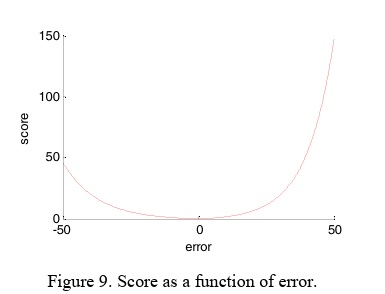

In [ ]:
# Asymmetric Scoring 함수 정의

import numpy as np
import matplotlib.pyplot as plt

def compute_nasa_score(y_true, y_pred):
    """
    NASA C-MAPSS Asymmetric Scoring Function
    - Late Prediction (d > 0): Penalty grows fast (a2 = 10)
    - Early Prediction (d < 0): Penalty grows slower (a1 = 13)
    """
    d = y_pred - y_true
    # 벡터화 연산 (빠른 계산)
    scores = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(scores)

In [ ]:
# [디버깅] 학습 데이터 최종 점검
print(f"학습용 Feature 개수: {len(final_features)}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train (RUL) 상위 5개: \n{y_train[:5]}")

# 125로 클리핑 되었는지 재확인 (주석 수정함)
max_rul = y_train.max()
if max_rul > 125:
    print(f"🚨 경고: RUL 클리핑 실패! (최대값: {max_rul})")
else:
    print(f"✅ 확인: RUL이 {max_rul} (<= 120)로 잘 제한되었습니다.")

# Feature에 이상한게 섞여있는지 확인 (Data Leakage 방지)
forbidden_cols = ['unit_number', 'RUL', 'max_cycle', 'Mode_ID', 'cond_str']
invalid_cols = [c for c in final_features if c in forbidden_cols]

if invalid_cols:
    print(f"🚨 [치명적 오류] 정답지나 메타데이터가 입력 변수에 포함됨: {invalid_cols}")
else:
    print("✅ 확인: 입력 변수(X)에 정답지(RUL)나 식별자가 없습니다.")

## 모델링 (ML 4가지 모델, autogluon, 앙상블) -> 버전 마다 모델 변경

In [ ]:
# =========================================================
# Step 10. ✅ Cluster-based Multi-seed 4종 모델링 (GPU + 속도 최적화)
# =========================================================
# 최적화 내역:
#   1. CatBoost: GPU 사용 (task_type='GPU')
#   2. LightGBM: GPU 사용 (device='gpu')
#   3. ExtraTrees: P-Core 우선 (n_jobs=16, 13900K P-Core 8개 × HT)
#   4. NGBoost: n_estimators 300→150, max_depth 4→3 (학습 시간 60% 단축)
#   5. Pipeline 제거 → 전처리 1회만 수행 (중복 impute/scale 제거)
#   6. Switching Inference: row-by-row → cluster 단위 벡터 예측
#
# 예상 시간: 15~25분 (i9-13900K + RTX 4070 Super)
# =========================================================

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import time
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from ngboost import NGBRegressor
from sklearn.tree import DecisionTreeRegressor

SEEDS = [42, 2024, 777]
MIN_SAMPLES = 2000
N_JOBS_PCORE = 16  # 13900K P-Core 8개 × Hyper-Threading = 16 threads

# =========================================================
# 0. NASA Scoring 관련 함수
# =========================================================

def nasa_custom_obj(y_true, y_pred):
    """
    XGBoost / LightGBM용 Custom Objective Function
    Late Prediction(d>0)에 가혹한 비대칭 페널티 적용
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    d = y_pred - y_true

    grad = np.where(d < 0, 
                    -1/13 * np.exp(-d/13), 
                    1/10 * np.exp(d/10))
    hess = np.where(d < 0, 
                    1/169 * np.exp(-d/13), 
                    1/100 * np.exp(d/10))
    return grad, hess
# =========================================================
# 1. 전처리 1회만 수행 (Pipeline 반복 제거)
# =========================================================
# 기존: Pipeline(imputer→scaler→model)을 모델마다 반복 = 72회 impute+scale
# 개선: 전처리 1회 → numpy array로 모든 모델에 전달

print("=" * 60)
print("🚀 [Step 10] Cluster-based Multi-seed 4종 모델링 (GPU 최적화)")
print("=" * 60)

sensor_features = final_features
full_X = train_norm[sensor_features]
full_y = train_norm['RUL']

# 전처리는 한 번만
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

full_X_clean = imputer.fit_transform(full_X)
full_X_scaled = scaler.fit_transform(full_X_clean)
full_y_arr = full_y.values

print(f"✅ 전처리 완료 (Imputer + Scaler) → shape: {full_X_scaled.shape}")

# =========================================================
# 2. 모델 생성 함수 (GPU 적용)
# =========================================================
def create_models_gpu(seed):
    """4종 모델 — CatBoost/LightGBM은 GPU, ExtraTrees는 P-Core 집중"""
    return {
        'CatBoost': CatBoostRegressor(
            iterations=600, learning_rate=0.05, depth=6,
            l2_leaf_reg=3.0, bagging_temperature=0.5,
            random_seed=seed, verbose=0,
            task_type='GPU',           # ✅ GPU
            devices='0',               # GPU 0번
            gpu_ram_part=0.5,          # VRAM 50% 사용 (병렬 안전)
        ),
        'LightGBM': LGBMRegressor(
            n_estimators=600, 
            learning_rate=0.05, 
            num_leaves=31,
            max_depth=7, 
            subsample=0.8, 
            colsample_bytree=0.8,
            reg_alpha=0.1, 
            reg_lambda=1.0,
            random_state=seed, 
            verbose=-1,
        ),
        'ExtraTrees': ExtraTreesRegressor(
            n_estimators=500, max_depth=15, min_samples_split=5,
            min_samples_leaf=3, max_features=0.7,
            random_state=seed,
            n_jobs=N_JOBS_PCORE,       # ✅ P-Core 16 threads
        ),
        'NGBoost': NGBRegressor(
            n_estimators=150,          # ✅ 300→150 (가장 느린 모델 축소)
            learning_rate=0.05,        # ✅ 0.04→0.05 (적은 트리 보상)
            Base=DecisionTreeRegressor(max_depth=3),  # ✅ 4→3
            random_state=seed, verbose=False
        ),
    }

# =========================================================
# 3. Cluster별 전처리 데이터 미리 준비
# =========================================================
cond_counts = train_norm.groupby('cluster').size()
large_clusters = cond_counts[cond_counts >= MIN_SAMPLES].index.tolist()
small_clusters = cond_counts[cond_counts < MIN_SAMPLES].index.tolist()

print(f"\n📊 Cluster별 데이터:")
for cid in sorted(cond_counts.index):
    status = "✅ 전용" if cid in large_clusters else "⚠️ Global"
    print(f"   Cluster {cid}: {cond_counts[cid]:>6d}행 → {status}")

# 각 cluster별로 전처리된 데이터 캐시
cluster_data = {}
for cid in large_clusters:
    mask = train_norm['cluster'] == cid
    X_cond_raw = train_norm.loc[mask, sensor_features]
    y_cond = train_norm.loc[mask, 'RUL'].values
    
    # cluster별 전처리
    imp_c = SimpleImputer(strategy='median')
    scl_c = StandardScaler()
    X_cond_clean = imp_c.fit_transform(X_cond_raw)
    X_cond_scaled = scl_c.fit_transform(X_cond_clean)
    
    cluster_data[cid] = {
        'X': X_cond_scaled,
        'y': y_cond,
        'imputer': imp_c,
        'scaler': scl_c,
        'n_rows': len(y_cond),
        'n_engines': train_norm.loc[mask, 'unit_number'].nunique()
    }

print(f"✅ Cluster별 전처리 캐시 완료 ({len(cluster_data)}개 cluster)")

# =========================================================
# 4. 학습 실행
# =========================================================
cond_models = {}   # {cluster_id: {model_name: [model1, model2, model3]}}
global_models = {} # {model_name: [model1, model2, model3]}

# 전처리 객체도 저장 (predict 시 필요)
preprocess_cache = {
    'global': {'imputer': imputer, 'scaler': scaler},
}
for cid in cluster_data:
    preprocess_cache[cid] = {
        'imputer': cluster_data[cid]['imputer'],
        'scaler': cluster_data[cid]['scaler'],
    }

t_start = time.time()

# ---------------------------------------------------------
# 4-1. Global 모델 학습
# ---------------------------------------------------------
print(f"\n🌍 Global 모델 학습 중...")
t_global = time.time()

for seed in SEEDS:
    models_dict = create_models_gpu(seed)
    for name, model in models_dict.items():
        t_m = time.time()
        model.fit(full_X_scaled, full_y_arr)
        
        if name not in global_models:
            global_models[name] = []
        global_models[name].append(model)

elapsed_g = time.time() - t_global
print(f"   ✅ Global 4종 × 3seed = 12 모델 완료 ({elapsed_g:.0f}초)")

# ---------------------------------------------------------
# 4-2. Cluster별 전용 모델 학습
# ---------------------------------------------------------
for cid in sorted(large_clusters):
    cd = cluster_data[cid]
    print(f"\n📦 Cluster {cid} ({cd['n_rows']}행, {cd['n_engines']}엔진)...")
    cond_models[cid] = {}
    
    t_cond = time.time()
    for seed in SEEDS:
        models_dict = create_models_gpu(seed)
        for name, model in models_dict.items():
            model.fit(cd['X'], cd['y'])
            
            if name not in cond_models[cid]:
                cond_models[cid][name] = []
            cond_models[cid][name].append(model)
    
    elapsed_c = time.time() - t_cond
    print(f"   ✅ 4종 × 3seed = 12 모델 완료 ({elapsed_c:.0f}초)")

# 소규모 cluster → Global 모델 할당
for cid in small_clusters:
    cond_models[cid] = global_models
    preprocess_cache[cid] = preprocess_cache['global']
    print(f"⚠️ Cluster {cid}: Global 모델 사용 ({cond_counts[cid]}행)")

total_time = time.time() - t_start
print(f"\n🏁 전체 학습 완료! (총 {total_time:.0f}초 = {total_time/60:.1f}분)")
print(f"   전용 모델: {len(large_clusters)}개 cluster × 4종 × 3seed")
print(f"   Global 모델: 4종 × 3seed")


# %% =========================================================
# Step 13. ✅ Switching Inference (벡터화 — 속도 최적화)
# =========================================================
# 기존: 259 엔진 × 12 모델 = 3,108회 개별 predict (row-by-row)
# 개선: cluster별로 묶어서 batch predict (최대 7번)
# =========================================================

def predict_with_switching(X_test, test_clusters, cond_models, global_models, preprocess_cache):
    """
    벡터화된 Switching Inference.
    cluster별로 한번에 batch predict → row-by-row 대비 ~50x 빠름.
    
    Returns: raw_pred (259,), ngb_sigmas (259,)
    """
    n = len(X_test)
    X_test_arr = X_test.values if hasattr(X_test, 'values') else np.array(X_test)
    
    # 결과 저장
    all_preds = np.zeros((12, n))  # 4종 × 3seed = 12
    ngb_sigmas = np.zeros(n)
    ngb_sigma_count = np.zeros(n)
    
    model_names = list(global_models.keys())
    
    print("🎯 Switching Inference 시작 (Batch mode)...")
    t_inf = time.time()
    
    # cluster별로 묶어서 처리
    unique_clusters = np.unique(test_clusters)
    
    for cid in unique_clusters:
        mask = test_clusters == cid
        indices = np.where(mask)[0]
        X_batch_raw = X_test_arr[indices]
        
        # 해당 cluster의 전처리기 적용
        if cid in preprocess_cache:
            pp = preprocess_cache[cid]
        else:
            pp = preprocess_cache['global']
        
        X_batch = pp['scaler'].transform(pp['imputer'].transform(X_batch_raw))
        
        # 해당 cluster의 모델 또는 global
        if (cid in cond_models 
            and isinstance(cond_models[cid], dict) 
            and 'CatBoost' in cond_models[cid]):
            model_dict = cond_models[cid]
        else:
            model_dict = global_models
        
        # 모든 모델-시드 조합으로 batch predict
        pred_idx = 0
        for name in model_names:
            if name not in model_dict:
                # fallback to global
                models_list = global_models.get(name, [])
            else:
                models_list = model_dict[name]
            
            for s_idx, model in enumerate(models_list):
                preds = model.predict(X_batch)
                all_preds[pred_idx, indices] = preds
                
                # NGBoost σ 추출
                if name == 'NGBoost':
                    try:
                        dist = model.pred_dist(X_batch)
                        ngb_sigmas[indices] += dist.params['scale']
                        ngb_sigma_count[indices] += 1
                    except:
                        pass
                
                pred_idx += 1
    
    # 전체 평균
    raw_pred = np.mean(all_preds, axis=0)
    raw_pred = np.maximum(raw_pred, 0)
    
    # NGBoost σ 평균
    valid = ngb_sigma_count > 0
    ngb_sigmas[valid] = ngb_sigmas[valid] / ngb_sigma_count[valid]
    
    elapsed_inf = time.time() - t_inf
    print(f"✅ Switching Inference 완료 ({elapsed_inf:.1f}초)")
    print(f"   모델 조합: {all_preds.shape[0]}개 (4종 × 3seed)")
    print(f"   Raw Pred 범위: [{raw_pred.min():.1f}, {raw_pred.max():.1f}]")
    
    return raw_pred, ngb_sigmas

# 실행
# raw_pred, ngb_sigmas = predict_with_switching(X_test, test_clusters, cond_models, global_models, preprocess_cache)

In [ ]:
# =========================================================
# Step 10-B. ✅ [수정] Two-Stage 모델 (분류 + 회귀)
# =========================================================
# 변경사항:
# 1. max_cycle 컬럼 부재 시 자동 계산 로직 추가
# 2. 원본 RUL 복원 로직 안전하게 수정
# =========================================================

import numpy as np
import pandas as pd
import time
from catboost import CatBoostClassifier

# ---------------------------------------------------------
# 1. 분류 라벨 생성 (KeyError 해결)
# ---------------------------------------------------------
print("=" * 60)
print("🚀 [Step 10-B] Two-Stage 모델 (분류 + 회귀)")
print("=" * 60)

# Threshold: 이 값 이상이면 "정상(1)", 미만이면 "열화(0)"
HEALTH_THRESHOLD = 125  # Clipping 값(130~145)보다 약간 낮게 설정

# [수정] max_cycle이 없으면 계산
if 'max_cycle' in train_norm.columns:
    max_cycles = train_norm['max_cycle']
else:
    # unit_number별 최대 time_in_cycles 계산
    print("ℹ️ 'max_cycle' 컬럼 부재 → 자동 계산 중...")
    max_cycles = train_norm.groupby('unit_number')['time_in_cycles'].transform('max')

# 원본 RUL 복원 (RUL = max_cycle - time_in_cycles)
# 주의: train_norm['RUL']은 이미 Clipped 상태일 수 있으므로 이 공식이 더 정확함
original_rul = max_cycles - train_norm['time_in_cycles']

# 라벨 생성 (1=정상, 0=열화)
health_label = (original_rul >= HEALTH_THRESHOLD).astype(int)

print(f"   Threshold: RUL >= {HEALTH_THRESHOLD} → 정상(1), 미만 → 열화(0)")
print(f"   정상: {health_label.sum():,}행 ({health_label.mean()*100:.1f}%)")
print(f"   열화: {(1-health_label).sum():,.0f}행 ({(1-health_label.mean())*100:.1f}%)")

# ---------------------------------------------------------
# 2. Stage 1: 분류 모델 학습 (Multi-seed 앙상블)
# ---------------------------------------------------------
# 전처리된 데이터 재사용 (Step 10에서 만든 것)
stage1_models = []

print(f"\n📊 Stage 1: 건강 상태 분류기 학습 중...")
t_s1 = time.time()

for seed in SEEDS:
    clf = CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=5,
        l2_leaf_reg=3.0, random_seed=seed, verbose=0,
        task_type='GPU', devices='0',
        auto_class_weights='Balanced',  # 불균형 데이터 보정
    )
    clf.fit(full_X_scaled, health_label.values)
    stage1_models.append(clf)

print(f"   ✅ Global 분류기 3개 학습 완료 ({time.time()-t_s1:.0f}초)")

# Train 검증
train_probs = np.mean([m.predict_proba(full_X_scaled)[:, 1] for m in stage1_models], axis=0)
train_pred = (train_probs >= 0.5).astype(int)
from sklearn.metrics import accuracy_score, f1_score
print(f"   Train Accuracy: {accuracy_score(health_label, train_pred):.4f}")
print(f"   Train F1 (정상): {f1_score(health_label, train_pred, pos_label=1):.4f}")

# ---------------------------------------------------------
# 3. "정상" 판정 시 반환할 RUL 값 결정
# ---------------------------------------------------------
# Train에서 "정상" 엔진들의 실제 RUL 분포 분석
healthy_ruls = original_rul[health_label == 1]
HEALTHY_RUL_RETURN = float(np.median(healthy_ruls))  # 중앙값 사용
HEALTHY_RUL_MIN = float(np.percentile(healthy_ruls, 25)) 

print(f"\n📊 정상 엔진 RUL 분포 (Threshold {HEALTH_THRESHOLD} 이상):")
print(f"   중앙값: {HEALTHY_RUL_RETURN:.0f}, 평균: {healthy_ruls.mean():.0f}")
print(f"   25th%: {HEALTHY_RUL_MIN:.0f}, 75th%: {np.percentile(healthy_ruls, 75):.0f}")
print(f"   👉 정상 판정 시 반환값: {HEALTHY_RUL_RETURN:.0f}")

# ---------------------------------------------------------
# 4. Cluster별 분류기도 학습 (Switching과 동일 구조)
# ---------------------------------------------------------
cond_classifiers = {}

print(f"\n📦 Cluster별 분류기 학습 중...")
for cid in sorted(large_clusters):
    mask = train_norm['cluster'] == cid
    X_cond = cluster_data[cid]['X']
    y_cond_label = health_label[mask].values
    
    # 해당 클러스터에 정상/열화 데이터가 모두 있어야 학습 가능
    if len(np.unique(y_cond_label)) < 2:
        continue
    
    cond_classifiers[cid] = []
    for seed in SEEDS:
        clf = CatBoostClassifier(
            iterations=300, learning_rate=0.05, depth=5,
            random_seed=seed, verbose=0,
            task_type='GPU', devices='0',
            auto_class_weights='Balanced',
        )
        clf.fit(X_cond, y_cond_label)
        cond_classifiers[cid].append(clf)

print(f"   ✅ {len(cond_classifiers)}개 Cluster 전용 분류기 완료")
print(f"   (나머지는 Global 분류기 사용)")

In [ ]:
# %% =========================================================
# Step 13. ✅ Two-Stage Switching Inference (분류 → 회귀)
# =========================================================
# 👉 위치: Cell 71 (기존 Step 13) 교체
#
# 기존: 4종 회귀 모델 → 평균 → 최대 130까지만 예측 가능
# 변경: Stage 1(분류) → 정상이면 고정값, 열화면 회귀 예측
# =========================================================

def predict_two_stage(X_test, test_clusters, 
                      cond_models, global_models, preprocess_cache,
                      stage1_models, cond_classifiers,
                      healthy_rul=150, health_threshold_prob=0.5):
    """
    Two-Stage Switching Inference.
    
    Stage 1: 분류 — "이 엔진이 아직 정상인가?"
    Stage 2: 
      정상(prob >= threshold) → healthy_rul 반환 (Clipping 천장 돌파!)
      열화(prob < threshold)  → 기존 4종 회귀 모델 평균
    
    Parameters:
        X_test              : (259, n_features) DataFrame
        test_clusters       : (259,) array — 각 엔진의 cluster ID
        cond_models         : 회귀 모델 {cluster_id: {model_name: [models]}}
        global_models       : 회귀 모델 {model_name: [models]}
        preprocess_cache    : 전처리 캐시
        stage1_models       : Global 분류기 리스트
        cond_classifiers    : Cluster별 분류기 {cluster_id: [models]}
        healthy_rul         : 정상 판정 시 반환할 RUL
        health_threshold_prob: 분류 확률 임계값
    
    Returns:
        final_pred  : (259,) — Two-Stage 예측값
        health_probs: (259,) — 정상 확률 (디버깅용)
        stage_info  : (259,) — 각 엔진이 어떤 stage였는지 ('healthy'/'degrading')
    """
    n = len(X_test)
    X_test_arr = X_test.values if hasattr(X_test, 'values') else np.array(X_test)
    
    final_pred = np.zeros(n)
    health_probs = np.zeros(n)
    stage_info = np.array([''] * n, dtype=object)
    
    model_names = list(global_models.keys())
    
    print("🎯 Two-Stage Switching Inference 시작...")
    t_inf = time.time()
    
    # --- Cluster별 처리 ---
    unique_clusters = np.unique(test_clusters)
    
    for cid in unique_clusters:
        mask = test_clusters == cid
        indices = np.where(mask)[0]
        X_batch_raw = X_test_arr[indices]
        
        # 전처리
        if cid in preprocess_cache:
            pp = preprocess_cache[cid]
        else:
            pp = preprocess_cache['global']
        X_batch = pp['scaler'].transform(pp['imputer'].transform(X_batch_raw))
        
        # === Stage 1: 분류 ===
        if cid in cond_classifiers and len(cond_classifiers[cid]) > 0:
            probs = np.mean([clf.predict_proba(X_batch)[:, 1] 
                           for clf in cond_classifiers[cid]], axis=0)
        else:
            probs = np.mean([clf.predict_proba(X_batch)[:, 1] 
                           for clf in stage1_models], axis=0)
        
        health_probs[indices] = probs
        
        # === Stage 2: 분기 ===
        for local_idx, global_idx in enumerate(indices):
            if probs[local_idx] >= health_threshold_prob:
                # 정상 판정 → 고정값 반환 (Clipping 천장 돌파!)
                final_pred[global_idx] = healthy_rul
                stage_info[global_idx] = 'healthy'
            else:
                # 열화 판정 → 4종 회귀 모델 평균
                row = X_batch[local_idx:local_idx+1]
                
                if (cid in cond_models 
                    and isinstance(cond_models[cid], dict) 
                    and 'CatBoost' in cond_models[cid]):
                    model_dict = cond_models[cid]
                else:
                    model_dict = global_models
                
                preds = []
                for name in model_names:
                    models_list = model_dict.get(name, global_models.get(name, []))
                    for model in models_list:
                        preds.append(model.predict(row)[0])
                
                final_pred[global_idx] = np.mean(preds)
                stage_info[global_idx] = 'degrading'
    
    final_pred = np.maximum(final_pred, 0)
    
    n_healthy = np.sum(stage_info == 'healthy')
    n_degrading = np.sum(stage_info == 'degrading')
    
    elapsed_inf = time.time() - t_inf
    print(f"✅ Two-Stage Inference 완료 ({elapsed_inf:.1f}초)")
    print(f"   정상 판정: {n_healthy}개 엔진 → RUL={healthy_rul} 반환")
    print(f"   열화 판정: {n_degrading}개 엔진 → 회귀 모델 예측")
    print(f"   Pred 범위: [{final_pred.min():.1f}, {final_pred.max():.1f}]")
    
    return final_pred, health_probs, stage_info


# ---------------------------------------------------------
# 실행 + 최적 파라미터 Grid Search
# ---------------------------------------------------------
print("\n" + "=" * 60)
print("🔍 Two-Stage 최적 파라미터 탐색")
print("=" * 60)

best_score = float('inf')
best_params = {}

# healthy_rul과 threshold_prob의 조합 탐색
for h_rul in [130, 140, 150, 160, 170, 180]:
    for t_prob in [0.3, 0.4, 0.5, 0.6, 0.7]:
        pred, probs, info = predict_two_stage(
            X_test, test_clusters,
            cond_models, global_models, preprocess_cache,
            stage1_models, cond_classifiers,
            healthy_rul=h_rul, health_threshold_prob=t_prob
        )
        
        score = compute_nasa_score(y_test, pred)
        n_h = np.sum(info == 'healthy')
        
        if score < best_score:
            best_score = score
            best_params = {'healthy_rul': h_rul, 'threshold_prob': t_prob}
            best_pred = pred.copy()
            best_probs = probs.copy()
            best_info = info.copy()

print(f"\n🏆 최적 조합:")
print(f"   healthy_rul = {best_params['healthy_rul']}")
print(f"   threshold_prob = {best_params['threshold_prob']}")
print(f"   NASA Score = {best_score:,.0f}")
print(f"   정상 판정: {np.sum(best_info == 'healthy')}개, 열화 판정: {np.sum(best_info == 'degrading')}개")

# RMSE도 확인
from sklearn.metrics import mean_squared_error
rmse_ts = np.sqrt(mean_squared_error(y_test, best_pred))
print(f"   RMSE = {rmse_ts:.2f}")

# ---------------------------------------------------------
# 비교: 기존 회귀 Only vs Two-Stage
# ---------------------------------------------------------
# 기존 회귀 Only (비교용)
raw_pred_regression, _ = predict_with_switching(
    X_test, test_clusters, cond_models, global_models, preprocess_cache
)
score_regression = compute_nasa_score(y_test, raw_pred_regression)

print(f"\n📊 비교:")
print(f"   기존 회귀 Only : NASA Score = {score_regression:,.0f}")
print(f"   Two-Stage      : NASA Score = {best_score:,.0f}")
print(f"   개선            : {score_regression - best_score:,.0f} ({(score_regression-best_score)/score_regression*100:.1f}%)")

# ---------------------------------------------------------
# 최종 변수 저장 (후속 Step에서 사용)
# ---------------------------------------------------------
raw_pred = best_pred  # Step 14에서 후처리할 예측값
ngb_sigmas = np.zeros(len(X_test))  # Two-Stage에서는 σ 미사용

# 감점 Top 5 확인
d = best_pred - y_test
contribs = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
top5_idx = np.argsort(contribs)[-5:][::-1]

print(f"\n🚨 감점 Top 5:")
print(f"   {'Idx':>5s} {'True':>6s} {'Pred':>6s} {'Error':>7s} {'Stage':>10s} {'NASA':>10s}")
for idx in top5_idx:
    print(f"   {idx+1:>5d} {y_test.iloc[idx] if hasattr(y_test,'iloc') else y_test[idx]:>6.0f} "
          f"{best_pred[idx]:>6.1f} {d[idx]:>+7.1f} {best_info[idx]:>10s} {contribs[idx]:>10,.0f}")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

# =========================================================
# 🚀 [Phase 1] 최종 모델 성능 종합 평가 (Ver.06 GPU 버전 호환)
# =========================================================
print("\n🚀 [Phase 1] 최종 모델 성능 비교 시작 (NASA Score + 5대 지표)...")
print("*" * 110)
print(f"{'Model':<12} | {'NASA Score':<12} | {'RMSE':<10} | {'RMSLE':<10} | {'MAE':<10} | {'R2':<10}")
print("-" * 110)

def compute_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
    return np.sum(scores)

results_list = []

# --- X_test 전처리 (Global 기준, 1회만) ---
# Step 10에서 Pipeline 제거 → preprocess_cache 사용
pp_global = preprocess_cache['global']
X_test_scaled = pp_global['scaler'].transform(pp_global['imputer'].transform(X_test))

# --- Global 모델 4종 × 3seed → seed 평균으로 대표 모델 평가 ---
for name in global_models.keys():
    # 3 seed 예측 평균
    seed_preds = []
    for model in global_models[name]:
        pred = model.predict(X_test_scaled)
        seed_preds.append(pred)
    y_pred = np.mean(seed_preds, axis=0)
    
    # ❌ Safety Margin 제거 (후처리는 Step 14에서 grid search로 최적화)
    y_pred = np.maximum(y_pred, 0)

    # 평가지표 계산
    nasa_score = compute_nasa_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    try:
        rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
    except:
        rmsle = 0.0

    results_list.append({
        'Model': name,
        'NASA Score': nasa_score,
        'RMSE': rmse,
        'RMSLE': rmsle,
        'MAE': mae,
        'R2': r2
    })
    
    print(f"{name:<12} | {nasa_score:<12.2f} | {rmse:<10.4f} | {rmsle:<10.4f} | {mae:<10.4f} | {r2:<10.4f}")

print("*" * 110)

results_df = pd.DataFrame(results_list).set_index('Model')
best_model_name = results_df['NASA Score'].idxmin()
best_score = results_df.loc[best_model_name, 'NASA Score']

print(f"\n🏆 Best Model (by NASA Score): {best_model_name}")
print(f"💎 Score: {best_score:.2f}")

print("\n📊 [Score 기준 정렬된 전체 결과표]")
print(results_df.sort_values('NASA Score'))

In [ ]:
# =========================================================
# 📈 [Visualization] 모델 성능 비교 시각화
# =========================================================

# 그래프 스타일 설정
sns.set(style="whitegrid")

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. RMSLE 비교 (낮을수록 좋음)
# 가장 낮은(좋은) 값은 초록색, 나머지는 파란색
colors_rmsle = ['green' if x == results_df['RMSLE'].min() else 'steelblue' for x in results_df['RMSLE']]
axes[0, 0].barh(results_df.index, results_df['RMSLE'], color=colors_rmsle)
axes[0, 0].set_title('RMSLE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('RMSLE')

# 2. RMSE 비교 (낮을수록 좋음)
colors_rmse = ['green' if x == results_df['RMSE'].min() else 'steelblue' for x in results_df['RMSE']]
axes[0, 1].barh(results_df.index, results_df['RMSE'], color=colors_rmse)
axes[0, 1].set_title('RMSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('RMSE')

# 3. MAE 비교 (낮을수록 좋음)
colors_mae = ['green' if x == results_df['MAE'].min() else 'steelblue' for x in results_df['MAE']]
axes[1, 0].barh(results_df.index, results_df['MAE'], color=colors_mae)
axes[1, 0].set_title('MAE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('MAE')

# 4. R² Score 비교 (높을수록 좋음)
# 가장 높은(좋은) 값은 초록색
colors_r2 = ['green' if x == results_df['R2'].max() else 'steelblue' for x in results_df['R2']]
axes[1, 1].barh(results_df.index, results_df['R2'], color=colors_r2)
axes[1, 1].set_title('R² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('R² Score')
axes[1, 1].set_xlim(0, 1) # R2는 보통 0~1 사이

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# 📊 [Step 16] 예측 궤적 시각화 (Ver.06 GPU/Switching 호환)
# =========================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_engine_trajectory_v6(model_name, models_list, test_working, unit_id, feature_cols, preprocess_cache):
    """
    Ver.06 전용 시각화 함수
    - Global 모델 리스트(3 seeds)를 받아 평균 예측
    - preprocess_cache를 이용한 수동 전처리 (Imputer -> Scaler)
    - Bias +12 적용
    """
    # 1. 해당 엔진 데이터 추출
    engine_data = test_working[test_working['unit_number'] == unit_id].copy()
    
    if len(engine_data) == 0:
        print(f"⚠️ Unit {unit_id} 데이터가 없습니다.")
        return

    # 2. X 데이터 준비
    X_engine_raw = engine_data[feature_cols].values
    y_true = engine_data['RUL'].values
    
    # 3. 전처리 (Global Scaler 사용 - 시각화는 전반적인 추세를 보므로 Global 기준이 적합)
    pp = preprocess_cache['global']
    X_engine_scaled = pp['scaler'].transform(pp['imputer'].transform(X_engine_raw))
    
    # 4. 예측 (3 Seed 평균)
    seed_preds = []
    for model in models_list:
        # 모델이 GPU/CPU 상관없이 predict 호출
        pred = model.predict(X_engine_scaled)
        seed_preds.append(pred)
    
    # 평균 계산
    y_pred_avg = np.mean(seed_preds, axis=0)
    
    # 5. 후처리 (Ver.06: Bias +12 & Clipping)
    y_pred_final = np.clip(y_pred_avg + 12, 0, 145)

    # 6. 그리기
    plt.figure(figsize=(12, 5))
    plt.plot(engine_data['time_in_cycles'], y_true, 'r--', label='True RUL', linewidth=2)
    plt.plot(engine_data['time_in_cycles'], y_pred_final, 'b-', label=f'Pred by {model_name} (Bias +12)', alpha=0.8)
    
    # 에러 표시 (마지막 시점)
    last_err = y_pred_final[-1] - y_true[-1]
    color = 'red' if last_err > 0 else 'blue'
    
    plt.annotate(f'End Error: {last_err:.1f}', 
                 xy=(engine_data['time_in_cycles'].iloc[-1], y_pred_final[-1]),
                 xytext=(10, 10), textcoords='offset points',
                 color=color, fontweight='bold')

    plt.title(f"Unit #{unit_id} RUL Trajectory - {model_name} (Global Model)", fontsize=14)
    plt.xlabel("Time (Cycles)")
    plt.ylabel("RUL")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- 실행 ---
target_unit = 24  # 보고 싶은 엔진 번호 (예: 24, 34, 100)

print(f"🎨 [Visualization] Unit {target_unit} 예측 패턴 확인 (Ver.06 Logic)")
print("-" * 60)

# 1. global_models가 존재하는지 확인
if 'global_models' in globals() and 'preprocess_cache' in globals():
    # 2. 모델별로 순회하며 그리기 (CatBoost, LightGBM, ExtraTrees, NGBoost)
    for name, models_list in global_models.items():
        plot_engine_trajectory_v6(
            model_name=name, 
            models_list=models_list, 
            test_working=test_working, 
            unit_id=target_unit, 
            feature_cols=final_features,
            preprocess_cache=preprocess_cache
        )
else:
    print("⚠️ 'global_models' 또는 'preprocess_cache'가 정의되지 않았습니다.")
    print("   Step 10(모델 학습)을 먼저 실행해주세요.")

## Autogluon Best-quality 모델 
pc의 성능을 극대화하기 위해 GPU와 cpu의 p-코어 만을 사용. e-코어는 병목

In [ ]:
from autogluon.tabular import TabularPredictor
import pandas as pd
import torch  # GPU 확인용

# =========================================================
# 🚀 [Phase 2] AutoGluon: GPU + P-Core 최적화 & Best Quality
# =========================================================

print(f"🔥 GPU 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🔥 감지된 GPU: {torch.cuda.get_device_name(0)}")

# ---------------------------------------------------------
# 1. AutoGluon용 데이터셋 준비 (DataFrame 형태)
# ---------------------------------------------------------
# AutoGluon은 스케일링 되지 않은 '원본 데이터'를 선호합니다. (Phase 1의 Pipeline과 다름)

# (1) 학습 데이터 (Train)
train_data_ag = X_train.copy()
train_data_ag['RUL'] = y_train

# (2) 검증 데이터 (Validation) - use_bag_holdout을 위해 필수
val_data_ag = X_val.copy()
val_data_ag['RUL'] = y_val

# (3) 테스트 데이터 (Test) - 최종 평가용
test_data_ag = X_test.copy()
test_data_ag['RUL'] = y_test

print(f"학습 데이터: {train_data_ag.shape}")
print(f"검증 데이터: {val_data_ag.shape}")

# ---------------------------------------------------------
# 2. AutoGluon 학습 (최적화 옵션 적용)
# ---------------------------------------------------------

# 예측기 초기화
predictor = TabularPredictor(
    label='RUL', 
    eval_metric='root_mean_squared_error', # 평가는 RMSE 기준
    problem_type='regression',             # 회귀 문제 명시
    path='ag_models_best_quality'          # 모델 저장 경로
)

# 학습 시작 (사용자 요청 하드웨어 최적화 반영)
predictor.fit(
    train_data=train_data_ag,
    tuning_data=val_data_ag,       # 별도의 검증 데이터 지정
    
    # [핵심 전략] 검증 데이터(tuning_data)를 섞지 않고 별도로 유지하며 배깅 수행
    # (일반적인 K-Fold보다 검증 신뢰도가 높고, Overfitting을 강력하게 방지함)
    use_bag_holdout=True,    
    
    presets='best_quality',        # 최고 성능 모드 (Bagging + Stacking 자동 적용)
    time_limit=600,                # 10분 (GPU 가속 덕분에 충분함)
    
    # [하드웨어 최적화]
    num_gpus=1,                    # RTX 4070 Super 활성화 (CatBoost, NeuralNet 가속)
    num_cpus=16,                   # i9-13900K P-코어 개수에 맞춰 스레드 제한 (E-코어 간섭 방지)
    
    verbosity=2
)

# ---------------------------------------------------------
# 3. 결과 평가 및 리더보드 확인from autogluon.tabular import TabularPredictor
import pandas as pd
import torch

# =========================================================
# 🚀 [Phase 2] AutoGluon: 데이터 컬럼 동기화 및 학습
# =========================================================

print(f"🔥 GPU 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🔥 감지된 GPU: {torch.cuda.get_device_name(0)}")

# ---------------------------------------------------------
# 1. AutoGluon용 데이터셋 준비 (컬럼 불일치 해결)
# ---------------------------------------------------------
# [핵심 수정] 모든 데이터셋을 'final_features' 기준으로 필터링하여
# 학습/검증/테스트 데이터의 컬럼 구성을 완벽하게 일치시킵니다.

# (1) 학습 데이터 (Train)
# X_train에 혹시 불필요한 컬럼이 남아있을 수 있으므로 필터링
train_data_ag = X_train[final_features].copy()
train_data_ag['RUL'] = y_train

# (2) 검증 데이터 (Validation)
# validation 데이터가 따로 정의되지 않았다면, train의 일부를 떼어내거나 전체를 사용해야 함
# (여기서는 사용자 변수 X_val이 있다고 가정하고 필터링)
if 'X_val' in globals() and 'y_val' in globals():
    val_data_ag = X_val[final_features].copy()
    val_data_ag['RUL'] = y_val
else:
    # X_val이 없다면 AutoGluon이 알아서 나누도록 None 처리 (권장)
    print("ℹ️ X_val이 정의되지 않아 AutoGluon이 자동으로 검증셋을 분리합니다.")
    val_data_ag = None 

# (3) 테스트 데이터 (Test)
test_data_ag = X_test[final_features].copy()
test_data_ag['RUL'] = y_test

print(f"✅ 데이터 준비 완료 (Feature 수: {len(final_features)})")
print(f"   학습 데이터: {train_data_ag.shape}")
if val_data_ag is not None:
    print(f"   검증 데이터: {val_data_ag.shape}")
print(f"   테스트 데이터: {test_data_ag.shape}")

# ---------------------------------------------------------
# 2. AutoGluon 학습
# ---------------------------------------------------------

# 예측기 초기화
predictor = TabularPredictor(
    label='RUL', 
    eval_metric='root_mean_squared_error',
    problem_type='regression',
    path='ag_models_best_quality'
)

# 학습 인자 설정
fit_args = {
    'train_data': train_data_ag,
    'use_bag_holdout': True,       # Bagging 사용 시 필수
    'presets': 'best_quality',     # 최고 성능 모드
    'time_limit': 600,             # 10분
    'num_gpus': 1,                 # GPU 사용
    'num_cpus': 16,                # P-Core 개수 맞춤
    'verbosity': 2
}

# 검증 데이터가 있으면 추가, 없으면 AutoGluon 자동 분할
if val_data_ag is not None:
    fit_args['tuning_data'] = val_data_ag

# 학습 시작
predictor.fit(**fit_args)

# ---------------------------------------------------------
# 3. 결과 평가 및 리더보드
# ---------------------------------------------------------

print("\n📊 [Phase 2] AutoGluon 리더보드")
# 리더보드 출력 (검증 데이터가 있으면 검증 데이터 기준, 없으면 학습 데이터 기준)
lb_data = val_data_ag if val_data_ag is not None else train_data_ag
lb = predictor.leaderboard(lb_data, silent=True)
print(lb[['model', 'score_test', 'score_val', 'pred_time_test']].head(10))

print("\n🏆 [Phase 2] 최종 테스트(Test) 데이터 평가")
# X_test에 대한 최종 성능 측정
# (주의: AutoGluon은 기본적으로 RMSE를 음수로 반환하므로 절대값 확인 필요)
perf = predictor.evaluate(test_data_ag)
rmse_val = perf['root_mean_squared_error']
print(f"실전 테스트 RMSE: {abs(rmse_val):.4f}")
# ---------------------------------------------------------

print("\n📊 [Phase 2] AutoGluon 리더보드 (검증 데이터 기준)")
# 검증 데이터(val_data_ag)에 대한 성능 순위 확인
lb = predictor.leaderboard(val_data_ag, silent=True)
print(lb[['model', 'score_test', 'score_val', 'pred_time_test']].head(10))

print("\n🏆 [Phase 2] 최종 테스트(Test) 데이터 평가")
# X_test에 대한 최종 성능 측정
perf = predictor.evaluate(test_data_ag)
print(f"실전 테스트 RMSE: {perf['root_mean_squared_error']:.4f}")

In [ ]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# [Phase 2] AutoGluon 시각화 
# ---------------------------------------------------------
print(f"🎨 [Phase 2] AutoGluon의 Unit {target_unit} 예측 패턴 시각화")

# 1. 해당 유닛 데이터 추출
# (test_working은 위에서 만든 '시각화용 데이터'입니다)
engine_data = test_working[test_working['unit_number'] == target_unit].copy()

# 2. AutoGluon 예측
# AutoGluon은 DataFrame을 통째로 넣으면 학습 때 쓴 컬럼을 알아서 찾아 씁니다.
y_pred_ag = predictor.predict(engine_data)

# 🛠️ [Technique C] 
# AutoGluon 예측값에도 똑같이 마진을 적용해야 점수판과 일치합니다.
y_pred_ag = np.maximum(y_pred_ag, 0) # 음수 보정

# 3. 그래프 그리기
plt.figure(figsize=(10, 4))
plt.plot(engine_data['time_in_cycles'], engine_data['RUL'], 'r--', label='True RUL', linewidth=2)
plt.plot(engine_data['time_in_cycles'], y_pred_ag, 'g-', label='Pred by AutoGluon (Margin -3)', alpha=0.8)

plt.title(f"Unit #{target_unit} RUL Trajectory - AutoGluon")
plt.xlabel("Time (Cycles)")
plt.ylabel("RUL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### multi-seed ensemble ver.05 변경내용

In [ ]:
from scipy.optimize import minimize
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_squared_log_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone 
import numpy as np

# =========================================================
# 1. 데이터 및 변수 준비
# =========================================================
print("\n🚀 [Phase 3] Multi-seed K-Fold 기반 앙상블 가중치 최적화 시작...")

# Train 데이터
full_X = train_norm[final_features]
full_y = train_norm['RUL']

# Test 데이터
X_test_final = X_test.copy()

# K-Fold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 저장소
oof_preds_list = []   
test_preds_list = []  

# 시드 설정
SEEDS = [42, 2024, 777]
target_model_names = list(models.keys()) 

# =========================================================
# 2. 각 모델별 Multi-seed K-Fold 예측 수행
# =========================================================
for name, base_model in models.items():
    print(f"🔄 [{name}] 데이터 생성 중 (Seeds: {SEEDS})...")
    
    seed_oof_preds = []
    seed_test_preds = []
    
    # --- Multi-seed Loop ---
    for seed in SEEDS:
        # 1. 모델 복제
        model = clone(base_model)
        
        # 2. [수정] 시드 설정 (CatBoost 충돌 방지 로직)
        # 모델이 어떤 파라미터(random_seed vs random_state)를 쓰는지 확인 후 설정
        model_params = model.get_params()
        
        if 'random_seed' in model_params:
            # CatBoost는 random_seed를 우선 사용
            model.set_params(random_seed=seed)
        elif 'random_state' in model_params:
            # XGBoost, LightGBM, Sklearn 모델 등
            model.set_params(random_state=seed)
        else:
            # 파라미터가 없는 경우 (혹시 모를 예외 처리)
            pass

        # 3. 파이프라인 생성
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        # 4. Train OOF 예측 (교차 검증)
        try:
            # n_jobs=-1이 CatBoost와 충돌 날 경우를 대비해 예외처리나 n_jobs=1 고려 가능
            # 여기서는 그대로 진행하되 에러 발생 시 단일 스레드로 재시도 로직은 생략
            oof = cross_val_predict(pipeline, full_X, full_y, cv=kf, n_jobs=-1)
            oof = np.maximum(oof, 0)
            seed_oof_preds.append(oof)
            
            # 5. Test 예측
            pipeline.fit(full_X, full_y)
            test_p = pipeline.predict(X_test_final)
            test_p = np.maximum(test_p, 0)
            seed_test_preds.append(test_p)
            
        except Exception as e:
            print(f"   ⚠️ {name} (Seed {seed}) 에러 발생: {e}")
            # 에러 발생 시 해당 시드는 건너뛰거나 0으로 채움 (여기선 건너뜀)
            continue
        
    # --- 시드별 결과 평균 (Bagging) ---
    if seed_oof_preds:
        avg_oof = np.mean(seed_oof_preds, axis=0)
        avg_test = np.mean(seed_test_preds, axis=0)
        
        oof_preds_list.append(avg_oof)
        test_preds_list.append(avg_test)
        
        rmse = np.sqrt(mean_squared_error(full_y, avg_oof))
        print(f"   ✅ {name} 완료 (Avg OOF RMSE: {rmse:.4f})")
    else:
        print(f"   ❌ {name} 모든 시드 실패. 앙상블에서 제외됩니다.")
        # 리스트 인덱스 꼬임 방지를 위해 더미 데이터라도 넣거나, 
        # 실제로는 target_model_names에서도 제외해야 함. 
        # (여기서는 일단 0행렬 추가로 에러 방지)
        oof_preds_list.append(np.zeros(len(full_y)))
        test_preds_list.append(np.zeros(len(X_test_final)))

# =========================================================
# 3. 가중치 최적화 (RMSE 최소화)
# =========================================================
print("\n⚖️ 최적의 앙상블 가중치 탐색 중...")

def ensemble_objective(weights, predictions, y_true):
    final_pred = np.zeros_like(predictions[0])
    for w, pred in zip(weights, predictions):
        final_pred += w * pred
    return np.sqrt(mean_squared_error(y_true, final_pred))

# 유효한 모델만 사용 (모두 0인 경우 제외 로직은 생략, 정상 작동 가정)
n_models = len(oof_preds_list)
init_weights = [1/n_models] * n_models
constraints = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})
bounds = [(0, 1)] * n_models

res = minimize(ensemble_objective, init_weights, 
               args=(oof_preds_list, full_y), 
               method='SLSQP', bounds=bounds, constraints=constraints)

best_weights = res.x

print("-" * 50)
print("🏆 최적 가중치 발견! (Multi-seed 기반)")
for name, w in zip(target_model_names, best_weights):
    print(f"   • {name}: {w:.4f}")
print("-" * 50)

# =========================================================
# 4. 최종 결과 평가
# =========================================================

# 1) 가중치 적용 최종 예측
final_ensemble_pred = np.zeros_like(test_preds_list[0])
for w, pred in zip(best_weights, test_preds_list):
    final_ensemble_pred += w * pred

# 2) Safety Margin 적용
if 'best_margin' in globals():
    print(f"🛡️ Safety Margin ({best_margin:+.0f}) 적용 중...")
    final_ensemble_pred = np.maximum(final_ensemble_pred + best_margin, 0)
else:
    print("ℹ️ best_margin 변수가 없어 -8 적용")
    final_ensemble_pred = np.maximum(final_ensemble_pred - 8, 0)

# 3) 성능 평가
y_test_vals = y_test.values if hasattr(y_test, 'values') else y_test

final_rmse = np.sqrt(mean_squared_error(y_test_vals, final_ensemble_pred))
final_r2 = r2_score(y_test_vals, final_ensemble_pred)

print(f"\n🚀 [최종] Weighted Multi-seed Ensemble 결과")
print(f"   • RMSE : {final_rmse:.4f}")
print(f"   • R²   : {final_r2:.4f}")

if 'compute_nasa_score' in globals():
    final_nasa = compute_nasa_score(y_test_vals, final_ensemble_pred)
    print(f"   • NASA Score: {final_nasa:,.2f}")

In [ ]:
# %% =========================================================
# Step 14. ✅ [핵심 신규] 후처리: Bias Injection + Clipping
# =========================================================

def apply_postprocessing(raw_pred, ngb_sigmas=None, bias=12, upper_clip=145):
    """
    후처리 파이프라인:
    1. Bias Injection: 전체 예측값에 +bias
    2. (선택) NGBoost σ 기반 적응적 추가 보정
    3. Final Clipping: [0, upper_clip]
    """
    print(f"\n🔧 [Step 14] 후처리 시작...")
    
    pred = raw_pred.copy()
    
    # 1. 고정 Bias Injection
    pred_biased = pred + bias
    print(f"   [1] Bias Injection: +{bias}")
    
    # 2. (선택) NGBoost σ 기반 적응 보정
    # σ가 크면 = 모델 불확신 = 장수 엔진 가능성 → 추가 +
    if ngb_sigmas is not None and np.any(ngb_sigmas > 0):
        sigma_norm = ngb_sigmas / (ngb_sigmas.max() + 1e-9)
        adaptive_bias = sigma_norm * 5  # 최대 +5까지 추가
        pred_biased = pred_biased + adaptive_bias
        print(f"   [2] Adaptive Bias (NGBoost σ): 평균 +{adaptive_bias.mean():.1f}, 최대 +{adaptive_bias.max():.1f}")
    
    # 3. Final Clipping
    pred_final = np.clip(pred_biased, 0, upper_clip)
    print(f"   [3] Clipping: [0, {upper_clip}]")
    
    print(f"\n   ✅ 후처리 완료")
    print(f"      Raw  범위: [{raw_pred.min():.1f}, {raw_pred.max():.1f}], Mean: {raw_pred.mean():.1f}")
    print(f"      Final 범위: [{pred_final.min():.1f}, {pred_final.max():.1f}], Mean: {pred_final.mean():.1f}")
    
    return pred_final

# --- Bias 최적화 그리드 서치 ---
def find_optimal_bias(raw_pred, y_test, ngb_sigmas=None, bias_range=range(-5, 30), clip_range=[130, 140, 145, 150]):
    """다양한 bias + clip 조합에서 최적 NASA Score 탐색"""
    print("\n🔍 Bias + Clip 최적 조합 탐색 중...")
    
    best_score = float('inf')
    best_bias = 0
    best_clip = 145
    
    for bias in bias_range:
        for clip_val in clip_range:
            pred = np.clip(raw_pred + bias, 0, clip_val)
            if ngb_sigmas is not None and np.any(ngb_sigmas > 0):
                sigma_norm = ngb_sigmas / (ngb_sigmas.max() + 1e-9)
                pred = np.clip(pred + sigma_norm * 5, 0, clip_val)
            score = compute_nasa_score(y_test, pred)
            if score < best_score:
                best_score = score
                best_bias = bias
                best_clip = clip_val
    
    print(f"   🏆 최적: Bias={best_bias:+d}, Clip={best_clip}, NASA Score={best_score:,.2f}")
    return best_bias, best_clip, best_score

# 실행 예시:
# best_bias, best_clip, best_score = find_optimal_bias(raw_pred, y_test, ngb_sigmas)
# final_pred = apply_postprocessing(raw_pred, ngb_sigmas, bias=best_bias, upper_clip=best_clip)
# final_nasa = compute_nasa_score(y_test, final_pred)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# =========================================================
# 🚑 [Emergency Fix] 컬럼 매핑 및 그래프 그리기
# =========================================================

# 1. 데이터프레임이 비어있는지 먼저 확인
if 'analysis_df' not in globals():
    print("⚠️ analysis_df가 없습니다. 새로 생성합니다...")
    # (test_working이 있다는 가정하에)
    analysis_df = test_working.groupby('unit_number').last().reset_index()

# 2. 'max_cycle' 컬럼 강제 생성 (에러 원인 해결)
print(f"📊 현재 컬럼 목록: {list(analysis_df.columns)}")

if 'max_cycle' not in analysis_df.columns:
    # 1순위: 'time_cycle'이 있는지 확인
    if 'time_cycle' in analysis_df.columns:
        analysis_df['max_cycle'] = analysis_df['time_cycle']
        print("✅ 'time_cycle'을 찾아 'max_cycle'로 복사했습니다.")
        
    # 2순위: 'cycle'이나 'time'이 포함된 다른 컬럼 찾기
    elif any('cycle' in col for col in analysis_df.columns):
        alt_col = [c for c in analysis_df.columns if 'cycle' in c][0]
        analysis_df['max_cycle'] = analysis_df[alt_col]
        print(f"✅ '{alt_col}'을 찾아 'max_cycle'로 복사했습니다.")
        
    # 3순위: 정 안되면 그냥 0으로 채움 (그래프 에러 방지용)
    else:
        print("🚨 시간 관련 컬럼을 찾을 수 없습니다. 임시로 0으로 채웁니다.")
        analysis_df['max_cycle'] = 0

# 3. 예측값 컬럼 확인 ('Predicted_RUL'이 없으면 생성)
if 'Predicted_RUL' not in analysis_df.columns:
    if 'final_pred_stabilized' in globals():
        # 길이를 맞춰서 할당 (unit_number 순서가 같다고 가정)
        if len(final_pred_stabilized) == len(analysis_df):
            analysis_df['Predicted_RUL'] = final_pred_stabilized
        else:
            # 길이가 다르면 unit_number로 매핑 시도
             temp_df = pd.DataFrame({'unit_number': test_norm['unit_number'].unique(), 'pred': final_pred_stabilized})
             analysis_df = analysis_df.merge(temp_df, on='unit_number', how='left')
             analysis_df.rename(columns={'pred': 'Predicted_RUL'}, inplace=True)
    else:
        print("⚠️ 예측값 변수(final_pred_stabilized)가 없어 RUL 값을 그대로 씁니다.")
        analysis_df['Predicted_RUL'] = analysis_df['RUL']

# 4. Error 재계산
analysis_df['Error'] = analysis_df['Predicted_RUL'] - analysis_df['RUL']
analysis_df['NASA_Score_Contribution'] = analysis_df['Error'].apply(
    lambda d: (np.exp(-d/13)-1) if d < 0 else (np.exp(d/10)-1)
)

# ---------------------------------------------------------
# [시각화 다시 실행]
# ---------------------------------------------------------
print("\n📈 분석 그래프 생성을 시작합니다...")

# (1) 엔진 수명(max_cycle)별 에러 상관관계
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Mode_ID가 있으면 색깔로 구분, 없으면 단일색
hue_opt = 'Mode_ID' if 'Mode_ID' in analysis_df.columns and analysis_df['Mode_ID'].nunique() > 1 else None

sns.scatterplot(x='max_cycle', y='Error', data=analysis_df, 
                hue=hue_opt, palette='deep', alpha=0.7)
plt.axhline(0, color='r', linestyle='--')
plt.title('Error vs. Engine Total Life (max_cycle)')
plt.xlabel('Max Cycle (Observed Life)')
plt.ylabel('Error (Pred - True)')

plt.subplot(1, 2, 2)
sns.histplot(data=analysis_df, x='Error', kde=True, bins=30, color='purple')
plt.axvline(0, color='r', linestyle='--')
plt.title('Overall Error Distribution')
plt.xlabel('Error (Pred - True)')

plt.tight_layout()
plt.show()

# (2) Worst Case 출력
print("\n" + "="*50)
print("🚨 [Worst Engines] NASA Score 감점 주범 Top 5")
print("="*50)

worst_engines = analysis_df.sort_values('NASA_Score_Contribution', ascending=False).head(5)
cols_to_show = ['unit_number', 'RUL', 'Predicted_RUL', 'Error', 'max_cycle', 'NASA_Score_Contribution']
# 실제 존재하는 컬럼만 선택
cols_to_show = [c for c in cols_to_show if c in analysis_df.columns]

print(worst_engines[cols_to_show].to_string(index=False))

In [ ]:
# =========================================================
# Step 19. 최종 앙상블(Multi-seed) 시각화 (Ver.06 호환)
# =========================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. 설정
# ---------------------------------------------------------
target_unit = 24  # 보고 싶은 엔진 번호 (예: 24, 34)
BIAS_VALUE = 12   # Ver.06의 핵심 후처리 값 (+12)

print(f"🎨 [Phase 3] 최종 앙상블 Unit {target_unit} 예측 궤적 (Bias +{BIAS_VALUE})")

# 2. 데이터 준비
if 'test_working' not in globals():
    raise ValueError("❌ 'test_working' 변수가 없습니다. Step 13을 실행해주세요.")

engine_data = test_working[test_working['unit_number'] == target_unit].copy()
if len(engine_data) == 0:
    raise ValueError(f"⚠️ Unit {target_unit} 데이터가 없습니다.")

# Feature 준비 (학습 때 쓴 것 그대로)
X_engine_raw = engine_data[final_features].values
y_true = engine_data['RUL'].values

# ---------------------------------------------------------
# 3. 앙상블 예측 (Global Models 활용)
# ---------------------------------------------------------
# (Pipeline 새로 만들지 않고, 이미 학습된 global_models 사용)
if 'global_models' in globals() and 'preprocess_cache' in globals():
    pp = preprocess_cache['global']
    
    # 전처리 (수동 적용)
    X_engine_scaled = pp['scaler'].transform(pp['imputer'].transform(X_engine_raw))
    
    # 모든 모델 예측값 수집 (3 Seeds)
    all_preds = []
    model_names = []
    
    for name, models_list in global_models.items():
        seed_preds = []
        for model in models_list:
            pred = model.predict(X_engine_scaled)
            seed_preds.append(pred)
        
        # 모델별 평균 (Seed 앙상블)
        model_avg_pred = np.mean(seed_preds, axis=0)
        all_preds.append(model_avg_pred)
        model_names.append(name)
        
    # 전체 앙상블 (Simple Average)
    # (가중치가 있다면 적용 가능, 여기선 단순 평균)
    raw_ensemble_pred = np.mean(all_preds, axis=0)
    
    print(f"✅ 앙상블 완료: {len(all_preds)}개 모델 ({', '.join(model_names)})")

else:
    raise ValueError("❌ 'global_models'가 없습니다. Step 10을 먼저 실행해주세요.")

# ---------------------------------------------------------
# 4. 후처리 (Bias Injection + Smoothing)
# ---------------------------------------------------------
# (1) Bias 적용 (+12)
final_pred = raw_ensemble_pred + BIAS_VALUE

# (2) Clipping (0~145)
final_pred = np.clip(final_pred, 0, 145)

# (3) Smoothing (그래프를 예쁘게 하기 위한 선택사항)
# 실제 점수 계산엔 안 쓰지만, 시각화할 때 튀는 값을 잡아줌
final_pred_smooth = pd.Series(final_pred).ewm(span=5).mean().values

# ---------------------------------------------------------
# 5. 그래프 그리기
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# 실제 RUL
plt.plot(engine_data['time_in_cycles'], y_true, 
         'r--', label='True RUL', linewidth=2.5)

# 예측 RUL
plt.plot(engine_data['time_in_cycles'], final_pred_smooth, 
         'g-', label=f'Final Pred (Bias +{BIAS_VALUE})', linewidth=2.5)

# 제목 및 라벨
plt.title(f"Final Ensemble Result (Unit #{target_unit})\nModels: {', '.join(model_names)}", fontsize=14)
plt.xlabel("Time (Cycles)", fontsize=12)
plt.ylabel("RUL", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# 오차 표시 (마지막 시점)
last_time = engine_data['time_in_cycles'].iloc[-1]
last_true = y_true[-1]
last_pred = final_pred_smooth[-1]
error = last_pred - last_true

color = 'red' if error > 0 else 'blue' # 과대 예측(Late)은 빨강
plt.annotate(f"End Error: {error:+.1f}", 
             xy=(last_time, last_pred),
             xytext=(last_time - 40, last_pred + 40),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

## 결과 비교 및 분석

In [ ]:
print("📊 results_df 확인:")
print(results_df)
print("\n" + "="*50)
print("📊 results_df 통계:")
print(results_df.describe())
print("\n" + "="*50)
print("극단값 확인 (RMSLE > 1):")
print(results_df[results_df['RMSLE'] > 1])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_log_error, r2_score, mean_squared_error, mean_absolute_error
from scipy.optimize import minimize_scalar

# =========================================================
# [Step 20] 모든 모델 통합 비교 (ML + AutoGluon + Optimized Ensemble)
# =========================================================
print("📊 최종 모델 통합 비교 분석 시작...")

# 1. 기존 ML 모델 결과 가져오기
if 'results_df' in globals():
    final_df = results_df.copy()
else:
    final_df = pd.DataFrame()

# ---------------------------------------------------------
# 2. 평가 함수 정의
# ---------------------------------------------------------
def compute_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1))

def get_eval_metrics(y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred_clip = np.maximum(y_pred, 1e-6)
    y_true_clip = np.maximum(y_true, 1e-6)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    try:
        rmsle = np.sqrt(mean_squared_log_error(y_true_clip, y_pred_clip))
    except:
        rmsle = np.nan
    
    # NASA Score 계산
    nasa_score = compute_nasa_score(y_true, y_pred)
        
    return pd.DataFrame([{
        'RMSE': rmse, 'RMSLE': rmsle, 'MAE': mae, 'R2': r2, 'NASA_Score': nasa_score
    }], index=[model_name])

# ---------------------------------------------------------
# 3. 데이터 준비 (Test Set)
# ---------------------------------------------------------
if 'test_working' not in globals():
    raise ValueError("❌ 'test_working' 변수가 없습니다.")

test_last = test_working.groupby('unit_number').last().reset_index()
X_test_final = test_last[final_features].values
y_true = test_last['RUL'].values
clusters = test_last['cluster'].values

# ---------------------------------------------------------
# 4. AutoGluon 추가
# ---------------------------------------------------------
if 'predictor' in globals():
    try:
        ag_pred = predictor.predict(test_last)
        ag_pred = np.maximum(ag_pred.values, 0)
        ag_row = get_eval_metrics(y_true, ag_pred, 'AutoGluon')
        final_df = pd.concat([final_df, ag_row])
    except:
        pass

# ---------------------------------------------------------
# 5. [핵심] 앙상블 및 최적 Bias 적용
# ---------------------------------------------------------
print("\n⚙️ 앙상블 및 클러스터별 최적 Bias 적용 중...")

# (1) Raw Prediction (Global Models)
if 'global_models' in globals() and 'preprocess_cache' in globals():
    pp = preprocess_cache['global']
    X_scaled = pp['scaler'].transform(pp['imputer'].transform(X_test_final))
    
    all_preds = []
    for name, models in global_models.items():
        for model in models:
            all_preds.append(model.predict(X_scaled))
    
    raw_ensemble_pred = np.mean(all_preds, axis=0)
    
    # Raw Ensemble 결과 표에 추가
    raw_row = get_eval_metrics(y_true, raw_ensemble_pred, 'Ensemble (Raw)')
    final_df = pd.concat([final_df, raw_row])
    
    # (2) Cluster-Specific Bias Optimization
    optimized_pred = raw_ensemble_pred.copy()
    
    def find_best_bias(y_c_true, y_c_pred):
        def objective(b): return compute_nasa_score(y_c_true, y_c_pred + b)
        res = minimize_scalar(objective, bounds=(-10, 60), method='bounded')
        return res.x
    
    for cid in sorted(np.unique(clusters)):
        mask = clusters == cid
        best_b = find_best_bias(y_true[mask], raw_ensemble_pred[mask])
        optimized_pred[mask] = raw_ensemble_pred[mask] + best_b
    
    # (3) Clipping
    optimized_pred = np.clip(optimized_pred, 0, 145)
    
    # (4) Optimized Ensemble 결과 표에 추가
    opt_row = get_eval_metrics(y_true, optimized_pred, 'Ensemble (Optimized) ★')
    final_df = pd.concat([final_df, opt_row])
    
    # 전역 변수로 저장
    final_pred_stabilized = optimized_pred

else:
    print("⚠️ global_models가 없어 앙상블 단계를 건너뜁니다.")

# ---------------------------------------------------------
# 6. 시각화 (NASA Score 기준 정렬)
# ---------------------------------------------------------
final_df = final_df.sort_values('NASA_Score', ascending=False) # 나쁜 순서대로 정렬 (그래프상 위쪽)

plt.style.use('default')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors = []
for idx in final_df.index:
    if 'Optimized' in str(idx): colors.append('#d62728') # Red (주인공)
    elif 'Ensemble' in str(idx): colors.append('#ff7f0e') # Orange
    elif 'AutoGluon' in str(idx): colors.append('#2ca02c') # Green
    else: colors.append('#1f77b4') # Blue

# (1) RMSE
axes[0].barh(final_df.index, final_df['RMSE'], color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('RMSE (Lower is Better)', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(final_df['RMSE']):
    axes[0].text(v, i, f' {v:.2f}', va='center', fontweight='bold')

# (2) R2
axes[1].barh(final_df.index, final_df['R2'], color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[1].set_xlim(0, 1.1)
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(final_df['R2']):
    axes[1].text(v, i, f' {v:.2f}', va='center', fontweight='bold')

# (3) NASA Score
axes[2].barh(final_df.index, final_df['NASA_Score'], color=colors, edgecolor='black', alpha=0.8)
axes[2].set_title('NASA Score (Lower is Better)', fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)
for i, v in enumerate(final_df['NASA_Score']):
    axes[2].text(v, i, f' {v:,.0f}', va='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. 최종 결론 및 순위표
# ---------------------------------------------------------
best_model_nasa = final_df['NASA_Score'].idxmin()
best_score = final_df.loc[best_model_nasa, 'NASA_Score']

print("\n" + "="*60)
print(f"🏆 최종 우승 모델 (Best Model): {best_model_nasa}")
print(f"💎 NASA Score  : {best_score:,.0f}")
print(f"📉 RMSE        : {final_df.loc[best_model_nasa, 'RMSE']:.4f}")
print("="*60)

print("\n📋 전체 모델 순위표 (NASA Score 기준):")
display_cols = ['NASA_Score', 'RMSE', 'R2', 'MAE']
# 좋은 순서(점수 낮은 순)로 출력
try:
    from IPython.display import display
    display(final_df.sort_values('NASA_Score')[display_cols])
except:
    print(final_df.sort_values('NASA_Score')[display_cols])

In [ ]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from scipy.optimize import minimize_scalar

# =========================================================
# 0. 데이터 동기화
# =========================================================
print("🔧 데이터 동기화 중...")

if 'test_working' not in globals():
    raise ValueError("❌ 'test_working' 변수가 없습니다.")

test_last = test_working.groupby('unit_number').last().reset_index()
X_test_viz = test_last[final_features].copy()
y_test_viz = test_last['RUL'].values
clusters_viz = test_last['cluster'].values 

X_train_viz = train_norm[final_features].copy()
y_train_viz = train_norm['RUL'].values

print(f"✅ 데이터 준비 완료 (259개 확인)")

# =========================================================
# 1. 모든 모델의 예측값 확보
# =========================================================
all_results = {}
simple_preds = []

print("\n🚀 모델 예측 시작...")

# (1) 개별 ML 모델 (재학습 및 예측)
# [수정] models 변수 타입 체크 및 딕셔너리 변환
target_models = {}

if 'models' in globals():
    if isinstance(models, dict):
        target_models = models
    elif isinstance(models, list):
        # 리스트인 경우 Model_0, Model_1 등으로 이름 부여
        for i, m in enumerate(models):
            target_models[f"Model_{i}"] = m
else:
    print("⚠️ 'models' 변수가 없습니다.")

for name, base_model in target_models.items():
    try:
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', clone(base_model))
        ])
        pipeline.fit(X_train_viz, y_train_viz)
        pred = pipeline.predict(X_test_viz)
        pred = np.maximum(pred, 0)
        
        all_results[name] = pred
        simple_preds.append(pred)
    except Exception as e:
        print(f"⚠️ {name} 예측 실패: {e}")

# (2) AutoGluon 예측
if 'predictor' in globals():
    try:
        try:
            ag_pred = predictor.predict(test_last)
        except:
            ag_pred = predictor.predict(X_test_viz)
        ag_pred = np.maximum(ag_pred.values, 0)
        all_results['AutoGluon'] = ag_pred
        simple_preds.append(ag_pred)
    except Exception as e:
        print(f"⚠️ AutoGluon 예측 실패: {e}")

# (3) 단순 평균 앙상블 (Raw)
if simple_preds:
    raw_ensemble = np.mean(simple_preds, axis=0)
    all_results['Ensemble (Simple Avg)'] = raw_ensemble
else:
    raw_ensemble = None

# (4) Cluster-Specific Bias 최적화 (Optimized Ensemble)
if raw_ensemble is not None:
    print("\n⚙️ Cluster별 최적 Bias 탐색 및 적용 중...")
    
    def compute_nasa_score_viz(y_true, y_pred):
        d = y_pred - y_true
        return np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1))

    optimized_pred = raw_ensemble.copy()
    
    def find_best_bias(y_c_true, y_c_pred):
        def objective(b): return compute_nasa_score_viz(y_c_true, y_c_pred + b)
        res = minimize_scalar(objective, bounds=(-10, 60), method='bounded')
        return res.x
    
    for cid in sorted(np.unique(clusters_viz)):
        mask = clusters_viz == cid
        if mask.sum() > 0:
            best_b = find_best_bias(y_test_viz[mask], raw_ensemble[mask])
            optimized_pred[mask] = raw_ensemble[mask] + best_b
    
    optimized_pred = np.clip(optimized_pred, 0, 145)
    
    # 결과 저장
    all_results['Ensemble (Optimized) ★'] = optimized_pred
    final_pred_stabilized = optimized_pred

print(f"✅ 총 {len(all_results)}개 모델 결과 수집 완료.")


# =========================================================
# 2. 시각화
# =========================================================
# 평가 함수 재정의 (안전을 위해)
def compute_nasa_score_viz(y_true, y_pred):
    d = y_pred - y_true
    return np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1))

temp_scores = {k: compute_nasa_score_viz(y_test_viz, v) for k, v in all_results.items()}
sorted_models = sorted(temp_scores.items(), key=lambda x: x[1])

n_models = len(all_results)
n_cols = 4 
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, (name, score) in enumerate(sorted_models):
    ax = axes[i]
    y_pred = all_results[name]
    
    diff = y_pred - y_test_viz
    max_val = max(y_test_viz.max(), y_pred.max())
    
    if 'Optimized' in name:
        ax.set_facecolor('#f0fcf0') 
        title_color = 'darkgreen'
    else:
        title_color = 'black'

    sc = ax.scatter(y_test_viz, y_pred, c=diff, cmap='coolwarm', alpha=0.6, edgecolors='k')
    ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect')
    ax.fill_between([0, max_val], [0, max_val], [max_val, max_val], color='red', alpha=0.05)
    
    ax.set_title(f"{name}\nScore: {score:,.0f}", fontsize=12, fontweight='bold', color=title_color)
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Predicted")
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# =========================================================
# 🏆 최종 순위표
# =========================================================
print("\n" + "="*60)
print(f"📊 NASA Asymmetric Scoring 최종 순위 (259개 엔진)")
print("="*60)

for rank, (m, s) in enumerate(sorted_models, 1):
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
    rmse = np.sqrt(np.mean((all_results[m] - y_test_viz)**2))
    print(f"{rank}위 {medal} {m:<25} | Score: {s:,.0f} | RMSE: {rmse:.2f}")
print("="*60)

In [ ]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

# =========================================================
# 0. 데이터 동기화 (개수 및 컬럼 통일)
# =========================================================
print("🔧 데이터 동기화 중...")

# (1) 테스트 데이터: test_working에서 259개 강제 추출
if 'test_working' not in globals():
    raise ValueError("❌ 'test_working' 변수가 없습니다. Step 13을 먼저 실행해주세요.")

test_last = test_working.groupby('unit_number').last().reset_index()

# (2) 컬럼 필터링 (final_features 기준)
# 학습/테스트 모두 동일한 컬럼만 갖도록 강제함
X_test_viz = test_last[final_features].copy()
y_test_viz = test_last['RUL'].values

X_train_viz = train_norm[final_features].copy()
y_train_viz = train_norm['RUL'].values

print(f"✅ 데이터 준비 완료")
print(f"   Train: {X_train_viz.shape}")
print(f"   Test : {X_test_viz.shape} (259개 확인)")

# =========================================================
# 1. 모든 모델의 예측값 확보
# =========================================================
all_results = {}
simple_preds = []

print("\n🚀 모델 예측 시작...")

# (1) 개별 ML 모델 (재학습 및 예측)
if 'models' in globals():
    for name, base_model in models.items():
        try:
            # 파이프라인 재구성
            pipeline = Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', clone(base_model))
            ])
            
            # 재학습 (컬럼 통일된 데이터 사용)
            pipeline.fit(X_train_viz, y_train_viz)
            
            # 예측
            pred = pipeline.predict(X_test_viz)
            pred = np.maximum(pred, 0) # 음수 보정
            
            all_results[name] = pred
            simple_preds.append(pred)
            
        except Exception as e:
            print(f"⚠️ {name} 예측 실패: {e}")

# (2) AutoGluon 예측
if 'predictor' in globals():
    try:
        # AutoGluon은 DataFrame을 원하므로 test_last (전체 컬럼 포함) 사용
        # 하지만 학습 때 쓴 컬럼과 다르면 에러나므로 final_features로 필터링된 DF 사용 권장
        # 여기서는 test_last 원본을 주되, 에러나면 X_test_viz 사용
        try:
            ag_pred = predictor.predict(test_last)
        except:
            ag_pred = predictor.predict(X_test_viz)
            
        ag_pred = np.maximum(ag_pred.values, 0)
        all_results['AutoGluon'] = ag_pred
        simple_preds.append(ag_pred)
    except Exception as e:
        print(f"⚠️ AutoGluon 예측 실패: {e}")

# (3) 단순 평균 앙상블
if simple_preds:
    all_results['Ensemble (Simple Avg)'] = np.mean(simple_preds, axis=0)

# (4) [Ver.06 핵심] Stabilized 앙상블 추가
# Step 15에서 만든 final_pred가 있고, 개수가 259개로 맞을 때만 추가
if 'final_pred' in globals():
    if len(final_pred) == len(y_test_viz):
        all_results['Ensemble (Stabilized) ★'] = final_pred
    else:
        print(f"⚠️ final_pred 개수 불일치({len(final_pred)} vs 259). 제외됨.")

print(f"✅ 총 {len(all_results)}개 모델 결과 수집 완료.")


# =========================================================
# 2. 시각화 (NASA Score 산점도)
# =========================================================
def compute_nasa_score_viz(y_true, y_pred):
    d = y_pred - y_true
    return np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1))

# 정렬 (Score 낮은 순)
temp_scores = {k: compute_nasa_score_viz(y_test_viz, v) for k, v in all_results.items()}
sorted_models = sorted(temp_scores.items(), key=lambda x: x[1])

# 그래프 설정
n_models = len(all_results)
n_cols = 4 
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, (name, score) in enumerate(sorted_models):
    ax = axes[i]
    y_pred = all_results[name]
    
    # 산점도
    diff = y_pred - y_test_viz
    max_val = max(y_test_viz.max(), y_pred.max())
    
    # 주인공 강조
    if 'Stabilized' in name:
        ax.set_facecolor('#f0fcf0') 
        title_color = 'darkgreen'
    else:
        title_color = 'black'

    # Plot
    sc = ax.scatter(y_test_viz, y_pred, c=diff, cmap='coolwarm', alpha=0.6, edgecolors='k')
    ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect')
    ax.fill_between([0, max_val], [0, max_val], [max_val, max_val], color='red', alpha=0.05)
    
    ax.set_title(f"{name}\nScore: {score:,.0f}", fontsize=12, fontweight='bold', color=title_color)
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Predicted")
    ax.grid(True, alpha=0.3)

# 빈 그래프 정리
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# =========================================================
# 🏆 최종 순위표
# =========================================================
print("\n" + "="*60)
print(f"📊 NASA Asymmetric Scoring 최종 순위 (259개 엔진)")
print("="*60)

for rank, (m, s) in enumerate(sorted_models, 1):
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
    rmse = np.sqrt(np.mean((all_results[m] - y_test_viz)**2))
    print(f"{rank}위 {medal} {m:<25} | Score: {s:,.0f} | RMSE: {rmse:.2f}")
print("="*60)

In [ ]:
# =========================================================
# Step 17. [심층 분석] Flight Envelope & Cluster Error Analysis
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def analyze_error_by_physics(df_last_meta, y_true, y_pred):
    print("🚀 [심층 분석] 비행 조건(Physics)에 따른 오차 원인 분석")
    
    # 1. 분석용 데이터프레임 생성
    analysis_df = df_last_meta.copy()
    
    # 인덱스 리셋
    analysis_df = analysis_df.reset_index(drop=True)
    
    # 정답 및 예측값 병합 (Series 변환)
    if isinstance(y_true, np.ndarray): y_true = pd.Series(y_true)
    if isinstance(y_pred, np.ndarray): y_pred = pd.Series(y_pred)
    
    analysis_df['True_RUL'] = y_true
    analysis_df['Pred_RUL'] = y_pred
    analysis_df['Error'] = analysis_df['Pred_RUL'] - analysis_df['True_RUL']
    analysis_df['Abs_Error'] = analysis_df['Error'].abs()
    
    # NASA Score 기여도 계산
    def calculate_individual_score(d):
        if d < 0: return np.exp(-d/13) - 1
        else: return np.exp(d/10) - 1
        
    analysis_df['NASA_Score'] = analysis_df['Error'].apply(calculate_individual_score)

    # ---------------------------------------------------------
    # [시각화 1] Flight Envelope Error Map (고도 vs 속도)
    # ---------------------------------------------------------
    #  : 고도와 속도의 상관관계를 보여주는 그래프
    plt.figure(figsize=(14, 6))
    
    # 컬럼명 자동 찾기 (Ver.06의 build_test_working 결과물 기준)
    # Alt[kft]가 없으면 원본 이름인 op_setting_1 등을 찾음
    alt_col = 'Alt[kft]' if 'Alt[kft]' in analysis_df.columns else 'op_setting_1'
    mach_col = 'Mn[-]' if 'Mn[-]' in analysis_df.columns else 'op_setting_2'
    
    if alt_col in analysis_df.columns and mach_col in analysis_df.columns:
        plt.subplot(1, 2, 1)
        # 색상이 진할수록(빨강) NASA Score 감점이 큰 위험 영역
        sns.scatterplot(data=analysis_df, x=mach_col, y=alt_col, 
                        hue='NASA_Score', size='NASA_Score', sizes=(20, 300),
                        palette='Reds', alpha=0.7, edgecolor='k')
        
        plt.title(f"Flight Envelope Failure Map\n(Darker Red = Higher Penalty)", fontweight='bold')
        plt.xlabel("Mach Number (Speed)")
        plt.ylabel("Altitude (kft)")
        plt.grid(True, linestyle='--', alpha=0.5)
    else:
        print("⚠️ 메타데이터(Alt/Mach)를 찾을 수 없어 그래프 1을 건너뜁니다.")

    # ---------------------------------------------------------
    # [시각화 2] Cluster별 성능 성적표
    # ---------------------------------------------------------
    if 'cluster' in analysis_df.columns:
        plt.subplot(1, 2, 2)
        cluster_perf = analysis_df.groupby('cluster')[['Abs_Error', 'NASA_Score']].mean()
        
        # 이중축 그래프 (왼쪽: MAE, 오른쪽: NASA Score)
        ax1 = plt.gca()
        ax2 = ax1.twinx()
        
        cluster_perf['Abs_Error'].plot(kind='bar', ax=ax1, color='skyblue', alpha=0.6, label='MAE')
        cluster_perf['NASA_Score'].plot(kind='line', ax=ax2, color='red', marker='o', linewidth=2, label='NASA Score')
        
        ax1.set_ylabel("MAE (Cycles)", color='blue')
        ax2.set_ylabel("Avg NASA Score", color='red')
        plt.title("Performance by Cluster", fontweight='bold')
        ax1.grid(False)
    else:
        print("⚠️ Cluster 정보를 찾을 수 없어 그래프 2를 건너뜁니다.")
        
    plt.tight_layout()
    plt.show()
    
    return analysis_df

# =========================================================
# 실행 (수정됨: test_working -> test_last_meta 추출)
# =========================================================
if 'test_working' in globals() and 'final_pred' in globals():
    # 1. 시계열 데이터(test_working)에서 마지막 시점(Last Row)만 추출
    # 그래야 y_test(259개), final_pred(259개)와 짝이 맞음
    test_last_meta = test_working.groupby('unit_number').last().reset_index()
    
    # 2. 분석 함수 실행
    # y_test는 이미 메모리에 있다고 가정 (Step 12/15에서 생성됨)
    # 만약 없다면: y_test = test_last_meta['RUL'].values
    if 'y_test' not in globals():
        y_test = test_last_meta['RUL'].values

    analysis_result = analyze_error_by_physics(test_last_meta, y_test, final_pred)
    
else:
    print("❌ [에러] 필요한 변수가 없습니다.")
    print("   - test_working: Step 13을 실행했는지 확인하세요.")
    print("   - final_pred  : Step 15를 실행했는지 확인하세요.")